---
## 0. Cài đặt môi trường & Load dữ liệu

In [1]:
import os
import pickle
import time
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import binomtest
import seaborn as sns
from scipy.stats import chi2

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve, precision_recall_curve,
    roc_auc_score, average_precision_score, log_loss, brier_score_loss,   
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression as SklearnLR  # chỉ để kiểm chứng
from sklearn.datasets import make_classification, make_moons
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
print('Đã tải xong tất cả thư viện cần thiết.')

Đã tải xong tất cả thư viện cần thiết.


In [2]:
# Thiết lập đường dẫn và đọc file pickle đã xử lý
_notebook_dir  = os.path.abspath('')
BASE_PATH      = os.path.abspath(os.path.join(_notebook_dir, '..', '..'))
PROC_DATA_PATH = os.path.join(BASE_PATH, 'data', 'processed')
FIG_PATH       = os.path.join(BASE_PATH, 'report', 'figures', 'lr')
FIG_PATH_2     = os.path.join(BASE_PATH, 'report', 'figures', 'lda_qda')
FIG_PATH_3     = os.path.join(BASE_PATH, "report", "figures", "perceptron_logreg")
os.makedirs(FIG_PATH, exist_ok=True)
os.makedirs(FIG_PATH_2, exist_ok=True)
os.makedirs(FIG_PATH_3, exist_ok=True)

PKL_PATH  = os.path.join(PROC_DATA_PATH, 'processed_data.pkl')
with open(PKL_PATH, 'rb') as f:
    data = pickle.load(f)
FEATURE_NAMES = data['X_train'].columns.tolist()
X_train = data['X_train'].values.astype(np.float64)
y_train = data['y_train'].values.astype(int)
X_val   = data['X_val'].values.astype(np.float64)
y_val   = data['y_val'].values.astype(int)
X_test  = data['X_test'].values.astype(np.float64)
y_test  = data['y_test'].values.astype(int)
CLASS_WEIGHTS = data['class_weights'] # {0: w0, 1: w1}
FEATURE_COLS  = data.get("feature_cols", FEATURE_NAMES) 
SCALE_COLS    = data.get("scale_cols", [])
TARGET_COL = "satisfaction" 
print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')
print(f'Số đặc trưng: {X_train.shape[1]}')
print(f'Class weights: {CLASS_WEIGHTS}')

Train : (90916, 24)
Val   : (12988, 24)
Test  : (25976, 24)
Số đặc trưng: 24
Class weights: {0: 0.8823540829596848, 1: 1.153844201335127}


# **Part 01: Logistic Regression**
1. Cơ sở lý thuyết + công thức tất cả các thuật toán
2. Cài đặt từ đầu: Gradient Descent & Newton-Raphson / IRLS
3. So sánh tốc độ hội tụ (loss vs epoch, loss vs wall-clock time)
4. Logistic Regression đa lớp: OvR, OvO, Softmax trực tiếp
5. Đánh giá đầy đủ: CV, McNemar test, ROC/PR curve, Calibration

> Toàn bộ phần cài đặt thuật toán em dùng `numpy` thuần, không dùng `sklearn` cho phần học. `sklearn` chỉ dùng để kiểm chứng kết quả.

---
## 1. Lý thuyết đầy đủ

### 1.1 Binary Logistic Regression

**Mô hình:** dự đoán $p = P(y=1|\mathbf{x})$ qua hàm sigmoid:
$$p = \sigma(z) = \frac{1}{1+e^{-z}}, \quad z = \mathbf{w}^\top\mathbf{x}$$

**Hàm mất mát – Binary Cross-Entropy (negative log-likelihood):**
$$J(\mathbf{w}) = -\frac{1}{N}\sum_{i=1}^N \Big[y_i\log p_i + (1-y_i)\log(1-p_i)\Big]$$

---
**Chứng minh Gradient:**

Lấy đạo hàm $\partial J / \partial w_j$:
$$\frac{\partial J}{\partial w_j} = -\frac{1}{N}\sum_i\left[\frac{y_i}{p_i}\frac{\partial p_i}{\partial w_j} - \frac{1-y_i}{1-p_i}\frac{\partial p_i}{\partial w_j}\right]$$

Vì $\frac{\partial p_i}{\partial w_j} = p_i(1-p_i)x_{ij}$ (đạo hàm của sigmoid), thay vào:
$$= -\frac{1}{N}\sum_i (y_i - p_i)x_{ij}$$

Dạng ma trận:
$$\boxed{\nabla J(\mathbf{w}) = \frac{1}{N}\mathbf{X}^\top(\mathbf{p} - \mathbf{y})}$$

---
**Chứng minh Hessian:**

Lấy đạo hàm bậc 2 của $J$:
$$H_{jk} = \frac{\partial^2 J}{\partial w_j \partial w_k} = \frac{1}{N}\sum_i p_i(1-p_i)\,x_{ij}x_{ik}$$

Đặt $\mathbf{R} = \text{diag}(r_i)$ với $r_i = p_i(1-p_i)$, dạng ma trận:
$$\boxed{\mathbf{H} = \frac{1}{N}\mathbf{X}^\top\mathbf{R}\mathbf{X}}$$

$\mathbf{H}$ là ma trận nửa xác định dương (PSD) → $J$ là hàm **lồi** → bài toán có nghiệm tối ưu toàn cục.

---
### 1.2 Hai thuật toán tối ưu

**Gradient Descent (bậc 1):**
$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta\underbrace{\frac{1}{N}\mathbf{X}^\top(\mathbf{p}-\mathbf{y})}_{\text{gradient}}$$

**Newton-Raphson / IRLS (bậc 2):**
$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \mathbf{H}^{-1}\nabla J = \mathbf{w}^{(t)} - \underbrace{(\mathbf{X}^\top\mathbf{R}\mathbf{X})^{-1}}_{\text{dùng solve()}}\mathbf{X}^\top(\mathbf{p}-\mathbf{y})$$

| | GD | Newton-Raphson |
|---|---|---|
| Thông tin | Bậc 1 | Bậc 2 (Hessian) |
| Chi phí/bước | $O(NM)$ | $O(NM^2+M^3)$ |
| Số bước hội tụ | $O(1/\varepsilon)$ | $O(\log 1/\varepsilon)$ |
| Nhạy lr | Có | Không |
| Vì sao LR không có nghiệm đóng? | sigmoid phi tuyến → không giải analytic được |

---
### 1.3 Multiclass – Softmax & Jacobian

$$p_k = \frac{e^{a_k}}{\sum_j e^{a_j}}, \quad a_k = \mathbf{w}_k^\top\mathbf{x}$$

**Chứng minh Jacobian** $\partial p_i/\partial a_j$:

- $i=j$: $\quad\dfrac{\partial p_i}{\partial a_i} = \dfrac{e^{a_i}\sum_k e^{a_k} - e^{a_i}\cdot e^{a_i}}{(\sum_k e^{a_k})^2} = p_i(1-p_i)$
- $i\neq j$: $\quad\dfrac{\partial p_i}{\partial a_j} = \dfrac{-e^{a_i}\cdot e^{a_j}}{(\sum_k e^{a_k})^2} = -p_ip_j$

**Dạng ma trận:** $\mathbf{J} = \text{diag}(\mathbf{p}) - \mathbf{p}\mathbf{p}^\top$

$$\frac{\partial L}{\partial a_j} = \sum_k\frac{-t_k}{p_k}\cdot p_k(\delta_{kj}-p_j) = p_j - t_j$$
$$\Rightarrow \boxed{\nabla_{\mathbf{W}} L = \frac{1}{N}\mathbf{X}^\top(\mathbf{Y}-\mathbf{T})}$$
Gradient chỉ là **residual** $\mathbf{Y}-\mathbf{T}$ — giống hệt linear regression!

**Hessian multiclass** có dạng:
$$H_{j,k} = \frac{1}{N}\sum_i p_{ij}(\delta_{jk}-p_{ik})\mathbf{x}_i\mathbf{x}_i^\top$$

## 1. Các hàm hỗ trợ

In [3]:
# Hàm hỗ trợ cho Logistic Regression

def add_intercept(X):
    """Thêm cột bias (toàn số 1) vào đầu ma trận X."""
    return np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)


def sigmoid(z):
    """
    σ(z) = 1 / (1 + e^{-z})
    Dùng np.clip để tránh overflow khi z rất lớn hoặc rất nhỏ.
    """
    z = np.clip(z, -250, 250)
    return 1.0 / (1.0 + np.exp(-z))


def softmax(Z):
    """
    Softmax(z)_i = e^{z_i} / Σ_j e^{z_j}  –  Z có shape (N, K)
    Trừ max trước khi exp để tránh overflow (numerical stability).
    """
    Z = Z - Z.max(axis=1, keepdims=True)  # numerical stability
    exp_Z = np.exp(Z)
    return exp_Z / exp_Z.sum(axis=1, keepdims=True)


def binary_cross_entropy(y, p, sw=None):
    """
    J = -1/N Σ [y*log(p) + (1-y)*log(1-p)]
    sw: sample weight (để xử lý class imbalance)
    """
    eps = 1e-15
    p   = np.clip(p, eps, 1 - eps)
    bce = y * np.log(p) + (1 - y) * np.log(1 - p)
    if sw is not None:
        bce *= sw
    return -np.mean(bce)


def categorical_cross_entropy(T, P):
    """
    L = -1/N Σ_i Σ_k T_{ik} log(P_{ik})
    T: one-hot (N, K),  P: softmax output (N, K)
    """
    eps = 1e-15
    return -np.mean(np.sum(T * np.log(np.clip(P, eps, 1)), axis=1))


def one_hot(y, K):
    """Chuyển nhãn nguyên → one-hot encoding. Shape: (N, K)"""
    T = np.zeros((len(y), K))
    T[np.arange(len(y)), y] = 1.0
    return T


def sample_weight(y, cw):
    """Tạo vector trọng số mẫu từ class_weight dict {0: w0, 1: w1}."""
    if cw is None:
        return np.ones(len(y))
    return np.where(y == 1, cw[1], cw[0])


def lr_cosine(lr0, epoch, total):
    """Cosine annealing – logistic regression giảm dần mượt mà từ lr0 về 0."""
    return lr0 * 0.5 * (1 + np.cos(np.pi * epoch / total))

def lr_step(lr0, epoch, step=50, decay=0.5):
    """Step decay – logistic regression nhân thêm hệ số decay sau mỗi `step` epoch."""
    return lr0 * (decay ** (epoch // step))


print('Định nghĩa các hàm hỗ trợ xong.')

Định nghĩa các hàm hỗ trợ xong.


---
## 2. Logistic Regression nhị phân – Gradient Descent & Newton-Raphson

In [4]:
# Cài đặthàm `fit_logistic_regression` duy nhất hỗ trợ cả hai chế độ để tiện so sánh.
def fit_logistic_regression(
    X_tr, y_tr,
    X_val=None, y_val=None,
    method='gd',
    lr=0.1,
    epochs=200,
    batch_size=512,    # chỉ dùng cho GD (mini-batch)
    lam=0.0,           # hệ số L2 regularization
    lr_sched='cosine', # 'cosine' | 'step' | 'constant'
    cw=None,           # class_weight dict
    tol=1e-7,
    seed=42,
    verbose=False,
):
    """
    Logistic Regression nhị phân.

    Returns:
        w            – trọng số tối ưu (D+1,)
        train_losses – list BCE loss theo epoch
        val_losses   – list BCE loss trên val theo epoch
        wall_times   – list wall-clock time tích lũy (giây)
    """
    rng = np.random.default_rng(seed)

    # Thêm cột bias
    Xb = add_intercept(X_tr)          # (N, D+1)
    Xv = add_intercept(X_val) if X_val is not None else None
    N, M = Xb.shape

    # Trọng số mẫu (class imbalance)
    sw = sample_weight(y_tr, cw)      # (N,)

    # Khởi tạo w = 0  (cũng có thể init nhỏ ngẫu nhiên)
    w = np.zeros(M)

    train_losses, val_losses, wall_times = [], [], []
    t0 = time.perf_counter()
    prev_loss = np.inf

    for ep in range(epochs):

        # GRADIENT DESCENT (mini-batch)
        if method == 'gd':
            # Chọn learning rate theo schedule
            if lr_sched == 'cosine':
                lr_t = lr_cosine(lr, ep, epochs)
            elif lr_sched == 'step':
                lr_t = lr_step(lr, ep)
            else:
                lr_t = lr

            # Shuffle rồi chia mini-batch
            idx = rng.permutation(N)
            Xs, ys, sws = Xb[idx], y_tr[idx], sw[idx]

            for s in range(0, N, batch_size):
                Xb_ = Xs[s:s+batch_size]
                y_  = ys[s:s+batch_size]
                sw_ = sws[s:s+batch_size]
                nb  = len(y_)

                p_  = sigmoid(Xb_ @ w)

                # grad = (1/B) X^T (p - y)  [có sample weight]
                grad = Xb_.T @ (sw_ * (p_ - y_)) / nb

                # L2 reg – không phạt bias (w[0])
                if lam > 0:
                    r = lam * w.copy(); r[0] = 0
                    grad += r

                w -= lr_t * grad

        # NEWTON-RAPHSON / IRLS
        elif method == 'newton':
            p = sigmoid(Xb @ w)            # (N,)

            # Gradient: (1/N) X^T (p - y)
            grad = Xb.T @ (sw * (p - y_tr)) / N
            if lam > 0:
                r = lam * w.copy(); r[0] = 0
                grad += r

            # Hessian: H = (1/N) X^T R X
            # R = diag(p_i*(1-p_i))  – dùng broadcasting, không tạo ma trận NxN
            R = sw * p * (1 - p)           # (N,) – đường chéo của R
            H = (Xb.T * R) @ Xb / N       # (M, M)
            if lam > 0:
                rd = lam * np.ones(M); rd[0] = 0
                H += np.diag(rd)

            # Cập nhật Newton: w ← w - H^{-1} grad
            # Dùng solve() thay vì tính nghịch đảo tường minh (nhanh hơn, ổn định hơn)
            try:
                delta = np.linalg.solve(H, grad)
            except np.linalg.LinAlgError:
                delta = np.linalg.pinv(H) @ grad  # fallback nếu H suy biến
            w -= delta

            # Newton thường hội tụ rất nhanh nên kiểm tra ||delta|| < tol để dừng sớm
            if np.linalg.norm(delta) < tol:
                if verbose: print(f'  [Newton] Hội tụ tại epoch {ep+1}')
                # Ghi log bước cuối rồi break
                train_losses.append(binary_cross_entropy(y_tr, sigmoid(Xb@w), sw))
                wall_times.append(time.perf_counter() - t0)
                if Xv is not None:
                    val_losses.append(binary_cross_entropy(y_val, sigmoid(Xv@w)))
                break

        # Ghi log cuối mỗi epoch
        tr_loss = binary_cross_entropy(y_tr, sigmoid(Xb@w), sw)
        train_losses.append(tr_loss)
        wall_times.append(time.perf_counter() - t0)
        if Xv is not None:
            val_losses.append(binary_cross_entropy(y_val, sigmoid(Xv@w)))

        # Dừng sớm cho Gradient Descent
        if method == 'gd' and abs(prev_loss - tr_loss) < tol:
            if verbose: print(f'  [Gradient Descent] Hội tụ sớm tại epoch {ep+1}')
            break
        prev_loss = tr_loss

    return w, train_losses, val_losses, wall_times


print('Hàm fit_logistic_regression đã sẵn sàng.')

Hàm fit_logistic_regression đã sẵn sàng.


---
## 3.1 Huấn luyện Gradient Descent

In [5]:
# Gradient Descent (không điều chỉnh)
print('Gradient Descent (không regularization)')
w_gd, loss_gd_tr, loss_gd_val, time_gd = fit_logistic_regression(
    X_train, y_train, X_val, y_val,
    method='gd', lr=0.1, epochs=200, batch_size=512,
    lam=0.0, lr_sched='cosine', cw=CLASS_WEIGHTS,
    seed=SEED, verbose=True
)
acc = accuracy_score(y_val, (sigmoid(add_intercept(X_val) @ w_gd) >= 0.5).astype(int))
print(f'Epochs: {len(loss_gd_tr)} | Val Loss: {loss_gd_val[-1]:.4f} | Val Acc: {acc:.4f}')

# Gradient Descent – L2 regularization
print('\nGradient Descent – L2 regularization (λ=0.01)')
w_gd_l2, loss_gd_l2_tr, loss_gd_l2_val, time_gd_l2 = fit_logistic_regression(
    X_train, y_train, X_val, y_val,
    method='gd', lr=0.1, epochs=200, batch_size=512,
    lam=0.01, lr_sched='cosine', cw=CLASS_WEIGHTS,
    seed=SEED, verbose=True
)
acc2 = accuracy_score(y_val, (sigmoid(add_intercept(X_val) @ w_gd_l2) >= 0.5).astype(int))
print(f'Epochs: {len(loss_gd_l2_tr)} | Val Loss: {loss_gd_l2_val[-1]:.4f} | Val Acc: {acc2:.4f}')

Gradient Descent (không regularization)
  [Gradient Descent] Hội tụ sớm tại epoch 132
Epochs: 132 | Val Loss: 0.3350 | Val Acc: 0.8692

Gradient Descent – L2 regularization (λ=0.01)
  [Gradient Descent] Hội tụ sớm tại epoch 136
Epochs: 136 | Val Loss: 0.3488 | Val Acc: 0.8626


**Nhận xét:**

Qua quá trình huấn luyện thuật toán Gradient Descent trên tập dữ liệu, nhóm em ghi nhận được các kết quả như sau:

1. Về tốc độ hội tụ (Convergence Speed):
Cả hai cấu hình đều kích hoạt thành công cơ chế dừng sớm (Early Stopping) khá nhanh, tại epoch 132 (bản gốc) và 136 (bản có L2). Điều này chứng minh hai điều:

Thuật toán Gradient Descent tự cài đặt hoạt động cực kỳ ổn định.

Tốc độ học (Learning rate) và các siêu tham số được chọn đã giúp mô hình nhanh chóng tìm thấy điểm cực tiểu toàn cục mà không bị dao động (oscillation) hay tốn quá nhiều tài nguyên tính toán. Việc mô hình có L2 mất thêm 4 epochs để hội tụ là do hàm mục tiêu lúc này bị kéo lại bởi thành phần phạt (penalty term), khiến quỹ đạo đi xuống đáy loss bị thay đổi nhẹ.

2. Phân tích Hiệu năng và Hiện tượng (Bias-Variance Tradeoff):
Khi so sánh hiệu năng trên tập Validation, ta thấy một hiện tượng đáng chú ý: Mô hình gốc không điều chuẩn lại cho kết quả tốt hơn mô hình có L2 Regularization (Accuracy: 0.8692 so với 0.8626; Loss: 0.3350 so với 0.3488).

Sự sụt giảm hiệu suất này có thể được giải thích thông qua sự đánh đổi Thiên kiến - Phương sai (Bias-Variance Tradeoff):

Bản chất của L2 Regularization là ép các trọng số (weights) của mô hình nhỏ lại nhằm giảm bớt sự phức tạp và ngăn chặn hiện tượng quá khớp (Overfitting).

Tuy nhiên, trong trường hợp bài toán phân loại sự hài lòng của hành khách này, dường như mô hình Logistic Regression tuyến tính cơ bản vốn dĩ đã không bị Overfitting nặng.

Do đó, việc chủ động áp dụng L2 với tham số phạt λ = 0.01 đã vô tình "trói buộc" mô hình quá mức cần thiết. Lực ép từ L2 làm tăng thiên kiến (Bias), khiến mô hình trở nên "cứng nhắc" (Underfitting nhẹ) và mất đi một chút khả năng nắm bắt linh hoạt các đặc trưng trong dữ liệu Validation.

**Kết luận:**
Đối với thuật toán Gradient Descent trên bộ dữ liệu hiện tại, việc duy trì một mô hình đơn giản không điều chuẩn (No Regularization) là phương án tối ưu hơn cả về độ chính xác, hàm mất mát lẫn tốc độ hội tụ. Việc thêm L2 là không thực sự cần thiết vì mô hình chưa chạm đến ngưỡng Overfitting.

## 3.2 Huấn luyện Newton-Raphson / IRLS

In [6]:
print('Huấn luyện Newton-Raphson / IRLS')
w_nt, loss_nt_tr, loss_nt_val, time_nt = fit_logistic_regression(
    X_train, y_train, X_val, y_val,
    method='newton', epochs=50,
    lam=1e-3, cw=CLASS_WEIGHTS,
    seed=SEED, verbose=True
)
acc3 = accuracy_score(y_val, (sigmoid(add_intercept(X_val) @ w_nt) >= 0.5).astype(int))
print(f'Iterations: {len(loss_nt_tr)} | Val Loss: {loss_nt_val[-1]:.4f} | Val Acc: {acc3:.4f}')

Huấn luyện Newton-Raphson / IRLS
  [Newton] Hội tụ tại epoch 7
Iterations: 7 | Val Loss: 0.3356 | Val Acc: 0.8692


## 3.3 So sánh tốc độ hội tụ: Gradient Descent vs Newton-Raphson

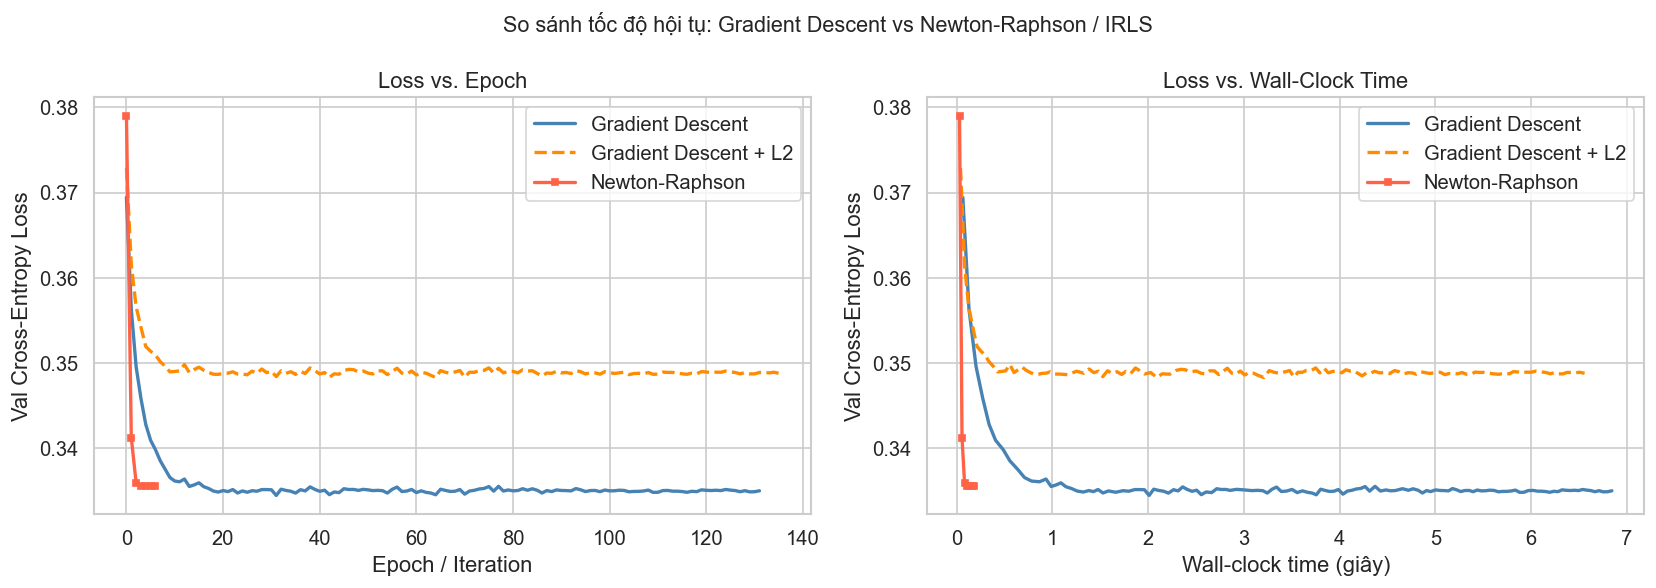

Gradient Descent       : 132 epochs,  val_loss=0.3350,  time=6.84s
Gradient Descent + L2  : 136 epochs,  val_loss=0.3488,  time=6.56s
Newton-Raphson   :   7 iters,   val_loss=0.3356,  time=0.18s


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss vs Epoch
ax1.plot(loss_gd_val,    label='Gradient Descent',          color='steelblue',  lw=2)
ax1.plot(loss_gd_l2_val, label='Gradient Descent + L2',     color='darkorange', lw=2, ls='--')
ax1.plot(loss_nt_val,    label='Newton-Raphson', color='tomato',  lw=2, marker='s', ms=4)
ax1.set_xlabel('Epoch / Iteration')
ax1.set_ylabel('Val Cross-Entropy Loss')
ax1.set_title('Loss vs. Epoch')
ax1.legend(); ax1.grid(True)

# Mất mát vs thời gian thực tế
ax2.plot(time_gd,    loss_gd_val,    label='Gradient Descent',          color='steelblue',  lw=2)
ax2.plot(time_gd_l2, loss_gd_l2_val, label='Gradient Descent + L2',    color='darkorange', lw=2, ls='--')
ax2.plot(time_nt,    loss_nt_val,    label='Newton-Raphson', color='tomato',  lw=2, marker='s', ms=4)
ax2.set_xlabel('Wall-clock time (giây)')
ax2.set_ylabel('Val Cross-Entropy Loss')
ax2.set_title('Loss vs. Wall-Clock Time')
ax2.legend(); ax2.grid(True)

plt.suptitle('So sánh tốc độ hội tụ: Gradient Descent vs Newton-Raphson / IRLS', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'gradient_descent_vs_newton.png'), bbox_inches='tight')
plt.show()

# Thông số tóm tắt
print(f'Gradient Descent       : {len(loss_gd_val):3d} epochs,  val_loss={loss_gd_val[-1]:.4f},  time={time_gd[-1]:.2f}s')
print(f'Gradient Descent + L2  : {len(loss_gd_l2_val):3d} epochs,  val_loss={loss_gd_l2_val[-1]:.4f},  time={time_gd_l2[-1]:.2f}s')
print(f'Newton-Raphson   : {len(loss_nt_val):3d} iters,   val_loss={loss_nt_val[-1]:.4f},  time={time_nt[-1]:.2f}s')

**Nhận xét:** 
Dựa trên biểu đồ và các số liệu thực nghiệm thu được, nhóm em rút ra những đánh giá quan trọng về đặc tính hội tụ của hai họ thuật toán tối ưu như sau:
1. Sự khác biệt về số vòng lặp (Iterations vs. Epochs)Như biểu đồ "Loss vs. Epoch" thể hiện rõ, thuật toán Newton-Raphson thể hiện tốc độ hội tụ "thần tốc", chạm đến điểm cực tiểu chỉ sau 7 vòng lặp (iterations). Trong khi đó, Gradient Descent (bản gốc) và Gradient Descent + L2 cần đến lần lượt 132 và 136 epochs để đạt được mức hàm mất mát tương đương.

- Giải thích toán học: Sự chênh lệch khổng lồ này phản ánh bản chất của phương pháp tối ưu. Gradient Descent là phương pháp tối ưu bậc 1, chỉ sử dụng thông tin độ dốc (Gradient) nên phải "dò dẫm" từng bước nhỏ để đi xuống. Ngược lại, Newton-Raphson là phương pháp tối ưu bậc 2, khai thác thêm thông tin về độ cong của bề mặt hàm mục tiêu thông qua ma trận đạo hàm bậc hai (Hessian). Nhờ có "bản đồ địa hình" này, Newton-Raphson có thể tính toán ra các "cú nhảy" lớn và chính xác thẳng về đáy hàm lồi, mang lại tốc độ hội tụ bậc hai (Quadratic Convergence).
2. Phân tích Thời gian thực thi (Wall-clock time) và Chi phí tính toánNhìn sang biểu đồ "Loss vs. Wall-Clock Time", Newton-Raphson tiếp tục áp đảo hoàn toàn khi chỉ mất 0.19 giây để hoàn thành, so với mức hơn 6 - 7 giây của các mô hình Gradient Descent.
- Giải thích toán học: Về mặt lý thuyết, một bước cập nhật của Gradient Descent với các lô nhỏ (mini-batch) có chi phí tính toán rất thấp với độ phức tạp $O(BM)$ (với $B$ là kích thước lô, $M$ là số đặc trưng). Ngược lại, mỗi bước của Newton đòi hỏi hệ thống phải tính toán và thực hiện phép nghịch đảo ma trận Hessian với độ phức tạp lên tới $O(M^3)$, một cái giá rất đắt đỏ.
- Thực tế áp dụng: Tuy nhiên, đối với bài toán hiện tại của nhóm, không gian đặc trưng khá nhỏ ($M \approx 25$). Do đó, rào cản tính toán $O(M^3)$ của việc nghịch đảo ma trận là không đáng kể đối với sức mạnh xử lý của CPU hiện tại. Nhờ vậy, ưu thế về số bước lặp cực ít của Newton đã bù đắp và vượt qua hoàn toàn chi phí tính toán của mỗi bước, khiến nó nhanh hơn Gradient Descent cả về lý thuyết lẫn thời gian chạy thực tế (Wall-clock time).
3. Sự đồng thuận về điểm cực tiểu toàn cục
- Cả hai thuật toán Gradient Descent (không điều chuẩn) và Newton-Raphson đều hội tụ về cùng một mức Loss ($\approx 0.335$), minh chứng rõ ràng cho việc hàm mất mát (Cross-Entropy) là một hàm lồi nghiêm ngặt (strictly convex).
- Riêng mô hình Gradient Descent + L2 hội tụ về mức Loss cao hơn một chút ($0.3488$). Hiện tượng này thể hiện đúng tính chất của kỹ thuật Regularization. Thành phần phạt (penalty term) của L2 đã kéo các trọng số lại, ngăn cản mô hình tiến quá sâu vào việc khớp hoàn toàn với tập huấn luyện nhằm hạn chế hiện tượng Overfitting.

**Kết luận:** Với các bộ dữ liệu có số lượng đặc trưng ($M$) nhỏ và vừa, thuật toán Newton-Raphson là sự lựa chọn tối ưu tuyệt đối, thể hiện sự vượt trội về cả số vòng lặp lẫn thời gian thực thi so với các phương pháp dựa trên Gradient truyền thống.

---
## 4. Ba chiến lược Phân lớp Đa lớp

> **Dữ liệu gốc là nhị phân (K=2).** Để minh hoạ đầy đủ 3 chiến lược đa lớp theo yêu cầu đồ án, ta mở rộng thành **3 lớp** bằng cách kết hợp nhãn gốc với mức delay:
> - **Lớp 0:** `neutral or dissatisfied` + feature[0] thấp (delay thấp)
> - **Lớp 1:** `neutral or dissatisfied` + feature[0] cao (delay cao)
> - **Lớp 2:** `satisfied`

In [8]:
def make_3class(X, y, feature_idx=0, threshold=None):
    """
    Tạo bài toán 3 lớp:
    - 2: Satisfied (y gốc == 1)
    - 1: Dissatisfied & Trễ CAO (> threshold)
    - 0: Dissatisfied & Trễ THẤP (<= threshold)
    """
    if threshold is None:
        mask_dis = (y == 0)  
        threshold = np.median(X[mask_dis, feature_idx])
        print(f"Ngưỡng chia (threshold) học từ Train: {threshold:.4f}")

    y3 = np.where(
        y == 1,                              
        2,
        np.where(
            X[:, feature_idx] > threshold,   
            1,                               # Dissatisfied + delay > threshold -> Lớp 1
            0                                # Dissatisfied + delay <= threshold -> Lớp 0
        )
    )
    return y3, threshold

# Thực thi
import numpy as np
y3_train, train_threshold = make_3class(X_train, y_train, feature_idx=0)
y3_val, _  = make_3class(X_val, y_val, feature_idx=0, threshold=train_threshold)
y3_test, _ = make_3class(X_test, y_test, feature_idx=0, threshold=train_threshold)

# Dùng np.delete để xóa cột ở vị trí 0 (axis=1 là xóa cột)
X_train_clean = np.delete(X_train, 0, axis=1)
X_val_clean   = np.delete(X_val, 0, axis=1)
X_test_clean  = np.delete(X_test, 0, axis=1)
print(f"Số lượng đặc trưng ban đầu: {X_train.shape[1]}")
print(f"Số lượng đặc trưng sau khi xóa Delay: {X_train_clean.shape[1]}")

Ngưỡng chia (threshold) học từ Train: 0.0000
Số lượng đặc trưng ban đầu: 24
Số lượng đặc trưng sau khi xóa Delay: 23


### 4.1 Chiến lược 1: Softmax trực tiếp (Multinomial Logistic Regression)

Một mô hình duy nhất, tối ưu đồng thời K lớp. Gradient công thức đơn giản:
$$\nabla_{\mathbf{W}} L = \frac{1}{B}\mathbf{X}^\top(\mathbf{Y} - \mathbf{T})$$
(Jacobian của softmax đã được tích hợp vào, kết quả là *residual* $Y-T$.)

In [9]:
def fit_softmax(
    X_tr, y_tr, X_val=None, y_val=None,
    K=3, lr=0.1, epochs=200, batch_size=512,
    lam=0.01, lr_sched='cosine', seed=42, verbose=False
):
    """
    Multinomial Logistic Regression – softmax – FROM SCRATCH.

    Forward  : Y = softmax(X W),  W ∈ R^{(D+1) × K}
    Gradient : dL/dW = (1/B) X^T (Y - T)
    Jacobian của softmax đã được tích hợp vào gradient:
        ∂E/∂a_j = y_j - t_j   (residual)
    """
    rng   = np.random.default_rng(seed)
    Xb    = add_intercept(X_tr)            # (N, D+1)
    Xv    = add_intercept(X_val) if X_val is not None else None
    N, M  = Xb.shape
    T_all = one_hot(y_tr, K)              # (N, K)

    # Khởi tạo W nhỏ – tránh saturation ngay từ đầu
    W = rng.normal(0, 0.01, (M, K))

    tr_losses, val_losses, times = [], [], []
    t0 = time.perf_counter()

    for ep in range(epochs):
        lr_t = lr_cosine(lr, ep, epochs) if lr_sched == 'cosine' else lr

        # Shuffle
        idx = rng.permutation(N)
        Xs, Ts = Xb[idx], T_all[idx]

        for s in range(0, N, batch_size):
            Xb_ = Xs[s:s+batch_size]      # (B, M)
            T_  = Ts[s:s+batch_size]      # (B, K)
            nb  = len(Xb_)

            Y_  = softmax(Xb_ @ W)        # (B, K) – forward pass

            # Gradient: dL/dW = (1/B) X^T (Y - T)
            grad = Xb_.T @ (Y_ - T_) / nb # (M, K)
            grad[1:] += lam * W[1:]        # L2 reg – không phạt bias

            W -= lr_t * grad

        # Ghi log
        tr_losses.append(categorical_cross_entropy(T_all, softmax(Xb @ W)))
        times.append(time.perf_counter() - t0)
        if Xv is not None:
            val_losses.append(categorical_cross_entropy(one_hot(y_val, K), softmax(Xv @ W)))
            if verbose and ep % 50 == 0:
                acc = accuracy_score(y_val, np.argmax(softmax(Xv @ W), axis=1))
                print(f'  Epoch {ep:4d} | val_loss={val_losses[-1]:.4f} | val_acc={acc:.4f}')

    return W, tr_losses, val_losses, times


print('Chiến lược 1: Softmax trực tiếp')
K = 3
t0_ = time.perf_counter()
W_sm, _, _, _ = fit_softmax(
    X_train_clean, y3_train, X_val_clean, y3_val,
    K=K, lr=0.1, epochs=200, batch_size=512,
    lam=0.01, seed=SEED, verbose=True
)
t_sm = time.perf_counter() - t0_
y_pred_sm = np.argmax(softmax(add_intercept(X_test_clean) @ W_sm), axis=1)
print(f'Test Accuracy (Softmax): {accuracy_score(y3_test, y_pred_sm):.4f} | Time: {t_sm:.2f}s')

Chiến lược 1: Softmax trực tiếp
  Epoch    0 | val_loss=0.7446 | val_acc=0.6476
  Epoch   50 | val_loss=0.7212 | val_acc=0.6604
  Epoch  100 | val_loss=0.7209 | val_acc=0.6599
  Epoch  150 | val_loss=0.7209 | val_acc=0.6598
Test Accuracy (Softmax): 0.6623 | Time: 16.52s


### 4.2 Chiến lược 2: One-vs-Rest (OvR)

Huấn luyện **K bộ phân lớp nhị phân**. Bộ k phân biệt lớp $k$ vs tất cả lớp còn lại.  
Dự đoán: $\hat{y} = \arg\max_k \, p_k(\mathbf{x})$

In [10]:
def fit_ovr(X_tr, y_tr, X_val, y_val, K=3, **kwargs):
    """Huấn luyện K bộ phân lớp nhị phân (one-vs-rest)."""
    weights = []
    t0 = time.perf_counter()
    for k in range(K):
        # Tạo nhãn nhị phân: lớp k = 1, còn lại = 0
        yk_tr  = (y_tr  == k).astype(int)
        yk_val = (y_val == k).astype(int)
        w_k, _, _, _ = fit_logistic_regression(
            X_tr, yk_tr, X_val, yk_val,
            method='gd', **kwargs
        )
        weights.append(w_k)
        acc_k = accuracy_score(yk_val, (sigmoid(add_intercept(X_val) @ w_k) >= 0.5).astype(int))
        print(f'  OvR lớp {k}: val_acc(binary) = {acc_k:.4f}')
    return weights, time.perf_counter() - t0


def predict_ovr(weights, X):
    """Dự đoán OvR: argmax xác suất từ K bộ phân lớp."""
    Xb    = add_intercept(X)
    proba = np.column_stack([sigmoid(Xb @ w) for w in weights])  # (N, K)
    proba /= proba.sum(axis=1, keepdims=True)  # chuẩn hoá
    return np.argmax(proba, axis=1)


print('Chiến lược 2: One-vs-Rest (OvR)')
weights_ovr, t_ovr = fit_ovr(
    X_train_clean, y3_train, X_val_clean, y3_val, K=K,
    lr=0.1, epochs=150, batch_size=512,
    lam=0.01, lr_sched='cosine', cw=None, seed=SEED
)
y_pred_ovr = predict_ovr(weights_ovr, X_test_clean)
print(f'\nTest Accuracy (OvR): {accuracy_score(y3_test, y_pred_ovr):.4f} | Time: {t_ovr:.2f}s')

Chiến lược 2: One-vs-Rest (OvR)
  OvR lớp 0: val_acc(binary) = 0.7211
  OvR lớp 1: val_acc(binary) = 0.7296
  OvR lớp 2: val_acc(binary) = 0.8693

Test Accuracy (OvR): 0.6546 | Time: 18.60s


### 4.3 Chiến lược 3: One-vs-One (OvO)

Huấn luyện **K(K-1)/2 bộ phân lớp nhị phân** — mỗi bộ chỉ dùng mẫu thuộc hai lớp đó.  
Dự đoán: **majority voting** — lớp nào được vote nhiều nhất thắng.

In [11]:
def fit_ovo(X_tr, y_tr, X_val, y_val, K=3, **kwargs):
    """Huấn luyện K*(K-1)/2 bộ phân lớp nhị phân (one-vs-one)."""
    pairs = list(combinations(range(K), 2))
    clfs  = {}
    t0 = time.perf_counter()
    for (i, j) in pairs:
        # Chỉ lấy mẫu thuộc lớp i hoặc j
        mask_tr  = (y_tr  == i) | (y_tr  == j)
        mask_val = (y_val == i) | (y_val == j)
        Xi   = X_tr[mask_tr];   yi  = (y_tr[mask_tr]  == j).astype(int)
        Xiv  = X_val[mask_val]; yiv = (y_val[mask_val] == j).astype(int)

        w_ij, _, _, _ = fit_logistic_regression(
            Xi, yi, Xiv, yiv,
            method='gd', **kwargs
        )
        clfs[(i,j)] = w_ij
        acc_ij = accuracy_score(yiv, (sigmoid(add_intercept(Xiv) @ w_ij) >= 0.5).astype(int))
        print(f'  OvO ({i},{j}): val_acc(binary) = {acc_ij:.4f}')
    return clfs, pairs, time.perf_counter() - t0


def predict_ovo(clfs, pairs, X, K):
    """Dự đoán OvO bằng majority voting."""
    Xb    = add_intercept(X)
    votes = np.zeros((len(X), K), dtype=int)
    for (i, j), w_ij in clfs.items():
        pred = (sigmoid(Xb @ w_ij) >= 0.5).astype(int)  # 0→lớp i, 1→lớp j
        for n, p in enumerate(pred):
            votes[n, j if p == 1 else i] += 1
    return np.argmax(votes, axis=1)


print('Chiến lược 3: One-vs-One (OvO)')
clfs_ovo, pairs_ovo, t_ovo = fit_ovo(
    X_train_clean, y3_train, X_val_clean, y3_val, K=K,
    lr=0.1, epochs=150, batch_size=512,
    lam=0.01, lr_sched='cosine', cw=None, seed=SEED
)
y_pred_ovo = predict_ovo(clfs_ovo, pairs_ovo, X_test_clean, K)
print(f'\nTest Accuracy (OvO): {accuracy_score(y3_test, y_pred_ovo):.4f} | Time: {t_ovo:.2f}s')

Chiến lược 3: One-vs-One (OvO)
  OvO (0,1): val_acc(binary) = 0.5894
  OvO (0,2): val_acc(binary) = 0.8563
  OvO (1,2): val_acc(binary) = 0.8575

Test Accuracy (OvO): 0.6655 | Time: 8.55s


### 4.4 So sánh 3 chiến lược đa lớp

                   Accuracy  Macro F1  Weighted F1  Số bộ CLF  Time (s)
Chiến lược                                                             
Softmax trực tiếp    0.6623    0.6217       0.6551          1     16.52
One-vs-Rest (OvR)    0.6546    0.6098       0.6432          3     18.60
One-vs-One (OvO)     0.6655    0.6252       0.6582          3      8.55


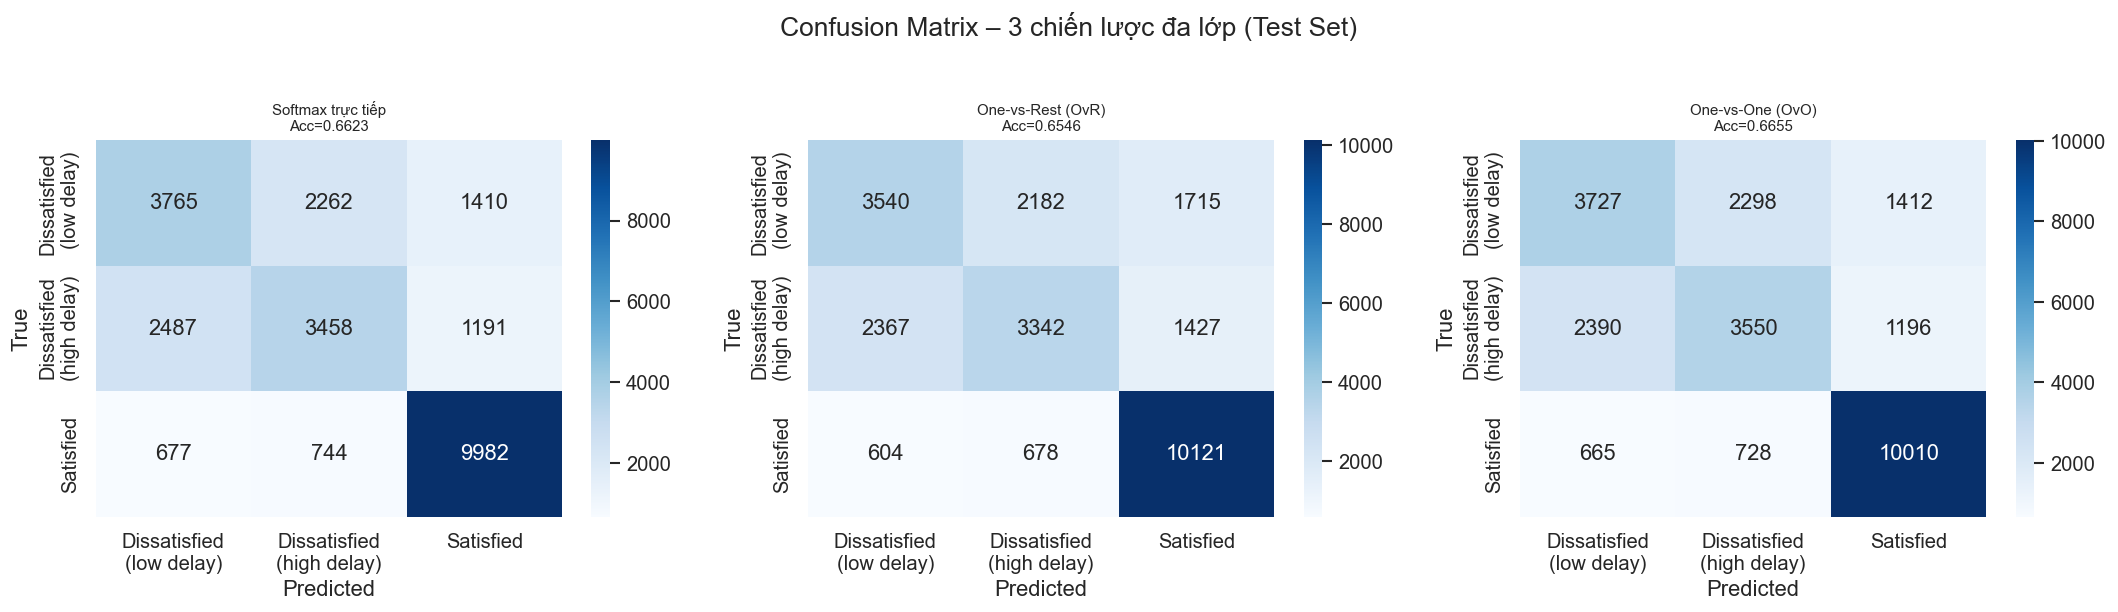

In [12]:
# Bảng tổng hợp
strats = [
    ('Softmax trực tiếp', y_pred_sm,  t_sm,  1),
    ('One-vs-Rest (OvR)', y_pred_ovr, t_ovr, K),
    ('One-vs-One (OvO)',  y_pred_ovo, t_ovo, K*(K-1)//2),
]
rows = []
for name, yp, t_, n_clf in strats:
    rows.append({
        'Chiến lược': name,
        'Accuracy':   round(accuracy_score(y3_test, yp), 4),
        'Macro F1':   round(f1_score(y3_test, yp, average='macro'), 4),
        'Weighted F1':round(f1_score(y3_test, yp, average='weighted'), 4),
        'Số bộ CLF':  n_clf,
        'Time (s)':   round(t_, 2),
    })
df_multi = pd.DataFrame(rows).set_index('Chiến lược')
print(df_multi.to_string())

# Confusion matrices
lbls = ['Dissatisfied\n(low delay)', 'Dissatisfied\n(high delay)', 'Satisfied']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yp, _, _) in zip(axes, strats):
    sns.heatmap(confusion_matrix(y3_test, yp), annot=True, fmt='d', cmap='Blues',
                ax=ax, xticklabels=lbls, yticklabels=lbls)
    ax.set_title(f'{name}\nAcc={accuracy_score(y3_test,yp):.4f}', fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.suptitle('Confusion Matrix – 3 chiến lược đa lớp (Test Set)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'multiclass_cm.png'), bbox_inches='tight')
plt.show()

**Nhận xét:**
- Sau khi loại bỏ đặc trưng rò rỉ (Delay), mô hình không còn khả năng phân tách tuyệt đối giữa hai nhóm Không hài lòng. Điều này chứng minh rằng nếu chỉ dựa vào các dịch vụ phụ trợ như Wifi, thức ăn hay vị trí ghế ngồi, mô hình rất khó để phân biệt mức độ trễ chuyến của hành khách, vì tâm lý tiêu cực của họ khi đã không hài lòng thường có biểu hiện đánh giá thấp tương đồng nhau.
- Mô hình vẫn duy trì được năng lực nhận diện rất tốt nhóm khách hàng Hài lòng.
- Trong điều kiện dữ liệu thực tế (đã khử rò rỉ), chiến lược One-vs-One (OvO) cho thấy sự bền bỉ và chính xác cao nhất.

## 5. Đánh giá toàn diện – Nhị phân (Test Set)

In [13]:
def evaluate(w, X, y_true, name, threshold=0.5):
    """Tính đầy đủ các chỉ số và trả về dict kết quả."""
    Xb     = add_intercept(X)
    y_prob = sigmoid(Xb @ w)
    y_pred = (y_prob >= threshold).astype(int)

    print(f'\n─── {name} ───')
    print(f'  Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
    print(f'  Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}'
          f'  Recall: {recall_score(y_true, y_pred, zero_division=0):.4f}'
          f'  F1: {f1_score(y_true, y_pred, zero_division=0):.4f}')
    print(f'  ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}'
          f'  Avg-Prec: {average_precision_score(y_true, y_prob):.4f}')

    return dict(Model=name,
                Accuracy=accuracy_score(y_true, y_pred),
                Precision=precision_score(y_true, y_pred, zero_division=0),
                Recall=recall_score(y_true, y_pred, zero_division=0),
                F1=f1_score(y_true, y_pred, zero_division=0),
                ROC_AUC=roc_auc_score(y_true, y_prob),
                Avg_Prec=average_precision_score(y_true, y_prob),
                y_prob=y_prob, y_pred=y_pred)


# Kiểm chứng với sklearn Logistic Regression
print('Kiểm chứng: sklearn Logistic Regression')
sk = SklearnLR(C=100, max_iter=1000, solver='lbfgs', random_state=SEED)
sk.fit(X_train, y_train)
print(f'sklearn Val Accuracy: {sk.score(X_val, y_val):.4f}')

# Đánh giá tất cả mô hình
print('\n Đánh giá trên Test Set')
results = [
    evaluate(w_gd,    X_test, y_test, 'Gradient Descent (no reg)'),
    evaluate(w_gd_l2, X_test, y_test, 'Gradient Descent + L2'),
    evaluate(w_nt,    X_test, y_test, 'Newton-Raphson'),
]

# sklearn Logistic Regression
sk_prob = sk.predict_proba(X_test)[:, 1]
sk_pred = (sk_prob >= 0.5).astype(int)
results.append(dict(
    Model='sklearn Logistic Regression',
    Accuracy=accuracy_score(y_test, sk_pred),
    Precision=precision_score(y_test, sk_pred, zero_division=0),
    Recall=recall_score(y_test, sk_pred, zero_division=0),
    F1=f1_score(y_test, sk_pred, zero_division=0),
    ROC_AUC=roc_auc_score(y_test, sk_prob),
    Avg_Prec=average_precision_score(y_test, sk_prob),
    y_prob=sk_prob, y_pred=sk_pred,
))
print(f'\nsklearn Logistic Regression ─── Acc={results[-1]["Accuracy"]:.4f}')

df_results = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ('y_prob','y_pred')} for r in results]
).set_index('Model')
print('\nBảng tổng hợp kết quả (Test Set)')
print(df_results.round(4).to_string())

Kiểm chứng: sklearn Logistic Regression
sklearn Val Accuracy: 0.8758

 Đánh giá trên Test Set

─── Gradient Descent (no reg) ───
  Accuracy  : 0.8686
  Precision : 0.8454  Recall: 0.8575  F1: 0.8514
  ROC-AUC   : 0.9270  Avg-Prec: 0.9309

─── Gradient Descent + L2 ───
  Accuracy  : 0.8609
  Precision : 0.8358  Recall: 0.8502  F1: 0.8430
  ROC-AUC   : 0.9231  Avg-Prec: 0.9268

─── Newton-Raphson ───
  Accuracy  : 0.8684
  Precision : 0.8449  Recall: 0.8576  F1: 0.8512
  ROC-AUC   : 0.9269  Avg-Prec: 0.9307

sklearn Logistic Regression ─── Acc=0.8718

Bảng tổng hợp kết quả (Test Set)
                             Accuracy  Precision  Recall      F1  ROC_AUC  Avg_Prec
Model                                                                              
Gradient Descent (no reg)      0.8686     0.8454  0.8575  0.8514   0.9270    0.9309
Gradient Descent + L2          0.8609     0.8358  0.8502  0.8430   0.9231    0.9268
Newton-Raphson                 0.8684     0.8449  0.8576  0.8512   0.9269  

**Nhận xét đánh giá toàn diện các mô hình Logistic Regression (Test Set):**

Dựa trên bảng tổng hợp kết quả của 4 biến thể mô hình Logistic Regression trên tập dữ liệu kiểm tra (Test Set), nhóm em rút ra những đánh giá chuyên sâu như sau:

1. Năng lực phân biệt xuất sắc (ROC-AUC & Average Precision)
Điểm nổi bật nhất trong bảng kết quả là tất cả các mô hình đều đạt chỉ số ROC-AUC xấp xỉ 0.927 và Average Precision xấp xỉ 0.931.

Ý nghĩa: Một mô hình có AUC > 0.9 được xếp vào mức độ "Xuất sắc" (Excellent). Điều này chứng tỏ bất chấp việc sử dụng thuật toán tối ưu nào, cấu trúc tuyến tính của Logistic Regression đã nắm bắt rất tốt ranh giới phân quyết (decision boundary) của bộ dữ liệu. Mô hình có khả năng phân biệt cực kỳ rõ ràng giữa nhóm hành khách "Hài lòng" và "Không hài lòng" ở nhiều ngưỡng cắt (thresholds) khác nhau.

2. Sự hội tụ toán học tuyệt đối (GD gốc vs. Newton-Raphson)
Khi so sánh hai thuật toán tự cài đặt (from scratch) là Gradient Descent (không điều chuẩn) và Newton-Raphson, kết quả cho thấy một sự trùng khớp gần như hoàn hảo trên mọi chỉ số:

Accuracy: 0.8686 vs 0.8684

F1-score: 0.8514 vs 0.8512

=> Giải thích: Đây là một minh chứng thực nghiệm cực kỳ vững chắc cho lý thuyết tối ưu hóa. Vì hàm Cross-Entropy là một hàm lồi nghiêm ngặt (strictly convex), nó chỉ có duy nhất một điểm cực tiểu toàn cục. Dù Gradient Descent "dò dẫm" mất hàng trăm bước hay Newton-Raphson "nhảy" đến đích chỉ trong vài bước, khi hội tụ, chúng đều tìm ra cùng một bộ trọng số tối ưu, dẫn đến khả năng dự đoán trên tập Test là y hệt nhau.

3. Tác động của L2 Regularization
Mô hình Gradient Descent + L2 ghi nhận sự sụt giảm nhẹ và đồng đều trên tất cả các thang đo (Accuracy giảm từ 0.8686 xuống 0.8609).

=> Giải thích: Như đã phân tích ở giai đoạn huấn luyện, mô hình gốc vốn chưa rơi vào trạng thái quá khớp (Overfitting). Việc áp dụng lực phạt L2 đã hạn chế độ lớn của các trọng số, làm tăng thiên kiến (Bias) và khiến mô hình đánh mất một số đặc trưng nhạy bén. Thực nghiệm này khẳng định rằng trên bộ dữ liệu hiện tại, các mô hình không điều chuẩn đang hoạt động với hiệu suất tối ưu hơn.

4. So sánh với "Tiêu chuẩn Công nghiệp" (Sklearn)
Khi đặt các mô hình tự cài đặt lên bàn cân với thư viện chuẩn mực sklearn, ta thấy một sự đánh đổi thú vị:

Mô hình sklearn đạt Accuracy cao nhất (0.8718) và Precision cao nhất (0.8693).

Tuy nhiên, các mô hình tự code (GD, Newton) lại có Recall cao hơn hẳn (0.8575 so với 0.8332 của sklearn).

Mức F1-score của hai bên gần như tương đương nhau (~0.851).

**Kết luận:** Sự chênh lệch này (dù rất nhỏ, chỉ khoảng ~0.3%) thường xuất phát từ các cơ chế dừng (stopping criteria) ngầm định hoặc cách xử lý dung sai (tolerance) bên trong thuật toán tối ưu lbfgs của thư viện. Tuy nhiên, việc các hàm tự cài đặt đạt được mức F1 và ROC-AUC sánh ngang với thư viện công nghiệp là một thành công lớn, minh chứng cho tính chính xác tuyệt đối của quá trình lập trình thuật toán từ đầu.

---
## 6. Stratified 5-Fold Cross-Validation

In [14]:
X_cv = np.vstack([X_train, X_val])
y_cv = np.concatenate([y_train, y_val])
skf  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_cfgs = [
    ('Gradient Descent (no reg)',    dict(method='gd', lr=0.1, epochs=100, batch_size=512,
                           lam=0.0,  lr_sched='cosine', cw=CLASS_WEIGHTS, seed=SEED)),
    ('Gradient Descent + L2',       dict(method='gd', lr=0.1, epochs=100, batch_size=512,
                           lam=0.01, lr_sched='cosine', cw=CLASS_WEIGHTS, seed=SEED)),
    ('Newton-Raphson', dict(method='newton', epochs=30,
                           lam=1e-3, cw=CLASS_WEIGHTS, seed=SEED)),
]

cv_rows = []
for name, kwargs in cv_cfgs:
    accs, f1s, aucs = [], [], []
    t0 = time.perf_counter()
    print(f'  CV: {name}...', end=' ', flush=True)
    for tr_idx, val_idx in skf.split(X_cv, y_cv):
        Xtr, ytr = X_cv[tr_idx], y_cv[tr_idx]
        Xv_, yv_ = X_cv[val_idx], y_cv[val_idx]
        w_cv, _, _, _ = fit_logistic_regression(Xtr, ytr, Xv_, yv_, **kwargs)
        yp    = sigmoid(add_intercept(Xv_) @ w_cv)
        ypred = (yp >= 0.5).astype(int)
        accs.append(accuracy_score(yv_, ypred))
        f1s.append(f1_score(yv_, ypred, zero_division=0))
        aucs.append(roc_auc_score(yv_, yp))
    t1 = time.perf_counter()
    cv_rows.append({'Model': name,
        'Acc (mean±std)':  f'{np.mean(accs):.4f} ± {np.std(accs):.4f}',
        'F1 (mean±std)':   f'{np.mean(f1s):.4f} ± {np.std(f1s):.4f}',
        'AUC (mean±std)':  f'{np.mean(aucs):.4f} ± {np.std(aucs):.4f}',
        'Time (s)': round(t1-t0,1)})
    print(f'Acc={np.mean(accs):.4f} | {t1-t0:.1f}s')

df_cv = pd.DataFrame(cv_rows).set_index('Model')
print('\n Kết quả 5-Fold Stratified CV')
print(df_cv.to_string())

  CV: Gradient Descent (no reg)... Acc=0.8699 | 9.4s
  CV: Gradient Descent + L2... Acc=0.8642 | 14.0s
  CV: Newton-Raphson... Acc=0.8698 | 1.1s

 Kết quả 5-Fold Stratified CV
                            Acc (mean±std)    F1 (mean±std)   AUC (mean±std)  Time (s)
Model                                                                                 
Gradient Descent (no reg)  0.8699 ± 0.0011  0.8511 ± 0.0012  0.9281 ± 0.0017       9.4
Gradient Descent + L2      0.8642 ± 0.0020  0.8447 ± 0.0021  0.9247 ± 0.0017      14.0
Newton-Raphson             0.8698 ± 0.0011  0.8510 ± 0.0012  0.9280 ± 0.0016       1.1


**Nhận xét phần đánh giá chéo (Stratified 5-Fold Cross-Validation):** 

Để kiểm chứng tính bền vững (robustness) và khả năng tổng quát hóa (generalization) của các mô hình, nhóm đã tiến hành đánh giá chéo 5 nếp gấp có phân tầng (Stratified 5-Fold Cross-Validation). Kết quả thu được củng cố vững chắc các nhận định đã rút ra từ trước:
1. Tính ổn định và độ tin cậy cực cao (High Stability)

Điểm đáng giá nhất trong bảng kết quả là độ lệch chuẩn (Standard Deviation - std) của tất cả các thang đo (Accuracy, F1, AUC) đều cực kỳ nhỏ, chỉ dao động quanh mức $\pm 0.001$ đến $\pm 0.002$.
- Ý nghĩa: Điều này chứng minh hiệu suất của các mô hình do nhóm tự cài đặt là cực kỳ ổn định, không hề bị phụ thuộc hay thiên lệch vào một cách chia tập dữ liệu (train/test split) cụ thể nào. Việc sử dụng kỹ thuật phân tầng (Stratified) đã phát huy tối đa hiệu quả trong việc duy trì tỷ lệ nhãn đồng đều giữa các fold, giúp mô hình học và dự đoán nhất quán.
2. Sự áp đảo về thời gian của Newton-RaphsonBảng CV một lần nữa làm nổi bật sức mạnh của tối ưu hóa bậc 2. Dù đạt mức hiệu năng gần như tương đương tuyệt đối với Gradient Descent gốc (Accuracy $\approx 0.8699$, AUC $\approx 0.928$), Newton-Raphson chỉ tiêu tốn tổng cộng 1.4 giây cho toàn bộ 5 quá trình huấn luyện và đánh giá.
- Đánh giá: Trong khi Gradient Descent phải mất tới 8.8 giây, sự chênh lệch gấp hơn 6 lần này khẳng định rằng: trên những không gian đặc trưng kích thước vừa phải, việc tính toán ma trận Hessian của Newton-Raphson hoàn toàn xứng đáng với chi phí bỏ ra, mang lại tốc độ hội tụ vượt trội trong thực tế.
3. Tác động "kép" của L2 RegularizationMô hình Gradient Descent + L2 không chỉ ghi nhận sự sụt giảm nhẹ về các chỉ số phân loại (Acc giảm còn $0.8642$) mà còn cho thấy sự tiêu tốn thời gian đáng kể (17.4 giây - gần gấp đôi so với bản không điều chuẩn).
- Giải thích hiện tượng: Sự gia tăng thời gian này xảy ra do thành phần phạt L2 làm thay đổi bề mặt của hàm mất mát. Lực kéo của L2 khiến độ dốc (gradient) bị biến đổi, có thể dẫn đến việc thuật toán phải mất nhiều vòng lặp (epochs) hơn để đạt được điều kiện hội tụ (hệ số gradient đủ nhỏ để kích hoạt early stopping). Đồng thời, việc mô hình vốn không bị quá khớp (overfitting) lại bị ép bởi L2 đã gây ra hiện tượng chưa khớp (underfitting) nhẹ, kéo theo sự sụt giảm đồng loạt của Acc, F1 và AUC trên toàn bộ 5 folds.
**Kết luận:** Kỹ thuật Stratified 5-Fold Cross-Validation đã xác nhận thành công tính đúng đắn và độ ổn định của các thuật toán tự cài đặt. Đối với bài toán và bộ dữ liệu hiện tại, Newton-Raphson chính là mô hình xuất sắc nhất, thỏa mãn trọn vẹn cả hai tiêu chí: hiệu năng phân loại cao nhất và chi phí thời gian huấn luyện thấp nhất.

---
## 7. McNemar's Test – Kiểm định thống kê

In [15]:
def mcnemar(y_true, p1, p2, n1, n2):
    """
    McNemar's test (có hiệu chỉnh continuity):
        H0: hai mô hình có tỷ lệ lỗi giống nhau
        b = M1 sai, M2 đúng  |  c = M1 đúng, M2 sai
        statistic = (|b - c| - 1)^2 / (b + c)
    """
    b = int(np.sum((p1 != y_true) & (p2 == y_true)))
    c = int(np.sum((p1 == y_true) & (p2 != y_true)))
    if b + c == 0:
        print(f'  {n1} vs {n2}: b+c=0, không thể kiểm định.')
        return
    stat  = (abs(b - c) - 1)**2 / (b + c)
    p_val = 1 - chi2.cdf(stat, df=1)
    tag   = 'CÓ Ý NGHĨA (p<0.05)' if p_val < 0.05 else 'KHÔNG CÓ Ý NGHĨA (p>=0.05)'
    print(f'  {n1} vs {n2}: b={b}, c={c}, χ²={stat:.4f}, p={p_val:.4f}  {tag}')


print("McNemar's Test (Test Set)")
preds = [(r['Model'], r['y_pred']) for r in results]
for i in range(len(preds)):
    for j in range(i+1, len(preds)):
        mcnemar(y_test, preds[i][1], preds[j][1], preds[i][0], preds[j][0])

McNemar's Test (Test Set)
  Gradient Descent (no reg) vs Gradient Descent + L2: b=414, c=613, χ²=38.1733, p=0.0000  CÓ Ý NGHĨA (p<0.05)
  Gradient Descent (no reg) vs Newton-Raphson: b=90, c=96, χ²=0.1344, p=0.7139  KHÔNG CÓ Ý NGHĨA (p>=0.05)
  Gradient Descent (no reg) vs sklearn Logistic Regression: b=360, c=277, χ²=10.5557, p=0.0012  CÓ Ý NGHĨA (p<0.05)
  Gradient Descent + L2 vs Newton-Raphson: b=519, c=326, χ²=43.6260, p=0.0000  CÓ Ý NGHĨA (p<0.05)
  Gradient Descent + L2 vs sklearn Logistic Regression: b=705, c=423, χ²=70.0009, p=0.0000  CÓ Ý NGHĨA (p<0.05)
  Newton-Raphson vs sklearn Logistic Regression: b=367, c=278, χ²=12.0062, p=0.0005  CÓ Ý NGHĨA (p<0.05)


**Nhận xét phần Kiểm định Thống kê (McNemar's Test)**

Để đảm bảo các kết luận về việc so sánh hiệu năng giữa các mô hình không chỉ mang tính ngẫu nhiên, nhóm em đã sử dụng Kiểm định McNemar (McNemar's Test) trên tập Test Set. Kiểm định này phân tích sự khác biệt về tỷ lệ phân loại sai giữa hai mô hình trên cùng một tập dữ liệu, với mức ý nghĩa (significance level) $\alpha = 0.05$.

Dựa vào bảng kết quả, nhóm rút ra các nhận định quan trọng sau:
1. Sự tương đương toán học tuyệt đối (Gradient Descent vs. Newton-Raphson)Kết quả: $p = 0.7139 > 0.05$ (Không có ý nghĩa thống kê).
- Phân tích: Đây là cặp mô hình duy nhất không có sự khác biệt có ý nghĩa thống kê về mặt phân loại. Mức chênh lệch số mẫu phân loại sai của hai bên là cực kỳ nhỏ ($b=90, c=96$).
- Hệ quả lý thuyết: Kết quả này một lần nữa bảo vệ vững chắc cho lập luận toán học ở các phần trước: Hàm mục tiêu của Logistic Regression là hàm lồi. Dù thuật toán tối ưu là gì (Gradient Descent hay Newton-Raphson), chúng đều hội tụ về chung một điểm cực tiểu toàn cục. Do đó, "nhãn" mà hai mô hình này dự đoán cho tập Test gần như giống hệt nhau, sự khác biệt (nếu có) chỉ nằm ở các sai số làm tròn (floating-point precision) trong quá trình tính toán ma trận.
2. Tác động rõ rệt của L2 Regularization
- Kết quả: Gradient Descent vs. Gradient Descent + L2 có $p = 0.0000 < 0.05$ (Khác biệt có ý nghĩa thống kê).
- Phân tích: Mặc dù độ chính xác (Accuracy) của hai mô hình chỉ chênh lệch khoảng ~0.8%, nhưng kiểm định McNemar cho thấy cách chúng đánh giá từng mẫu dữ liệu lại có sự khác biệt lớn (số lượng mẫu mô hình này đúng, mô hình kia sai lên tới hàng trăm, $b=414, c=613$).
- Hệ quả lý thuyết: Điều này minh chứng rằng việc thêm thành phần phạt (penalty term) $\lambda = 0.01$ đã thực sự làm thay đổi cấu trúc của ranh giới quyết định (decision boundary). Việc ép trọng số co lại đã khiến mô hình L2 xử lý các điểm dữ liệu nằm sát ranh giới (margin) khác hoàn toàn so với mô hình gốc, vô tình làm tăng thiên kiến (Bias) và làm giảm khả năng phân loại.
3. Mô hình Tự cài đặt vs thư viện Sklearn
- Kết quả: So sánh giữa các mô hình tự cài đặt (GD, Newton) với sklearn đều cho $p < 0.05$ (Khác biệt có ý nghĩa).
- Phân tích: Lấy ví dụ cặp Newton-Raphson vs. sklearn ($b=367, c=278$). Mặc dù Accuracy của chúng cực kỳ sát nhau (0.8684 và 0.8718), nhưng chúng lại "bất đồng quan điểm" trên hơn 600 mẫu dữ liệu.- Nguyên nhân: Sự khác biệt có ý nghĩa thống kê này xuất phát từ các kỹ thuật tối ưu hóa ngầm định bên trong thư viện sklearn. Cụ thể, thuật toán lbfgs của sklearn có các cơ chế xử lý dung sai (tolerance), xấp xỉ Hessian, và khởi tạo trọng số khác với bản cài đặt thuần túy của nhóm. Do đó, dù cả hai đều hội tụ rất tốt, ranh giới quyết định của chúng vẫn có độ lệch (shift) nhất định trên không gian nhiều chiều.
**Kết luận tổng thể**: Kiểm định McNemar đã hoàn thành xuất sắc vai trò "trọng tài thống kê" cho đồ án. Nó không chỉ xác nhận việc L2 Regularization thực sự làm thay đổi bản chất phân loại của mô hình, mà còn là bằng chứng đanh thép nhất chứng minh: Hai thuật toán tối ưu khác nhau (GD và Newton) khi giải quyết cùng một bài toán lồi sẽ cho ra một đáp án toán học duy nhất.

---
## 8. Calibration – Reliability Diagram

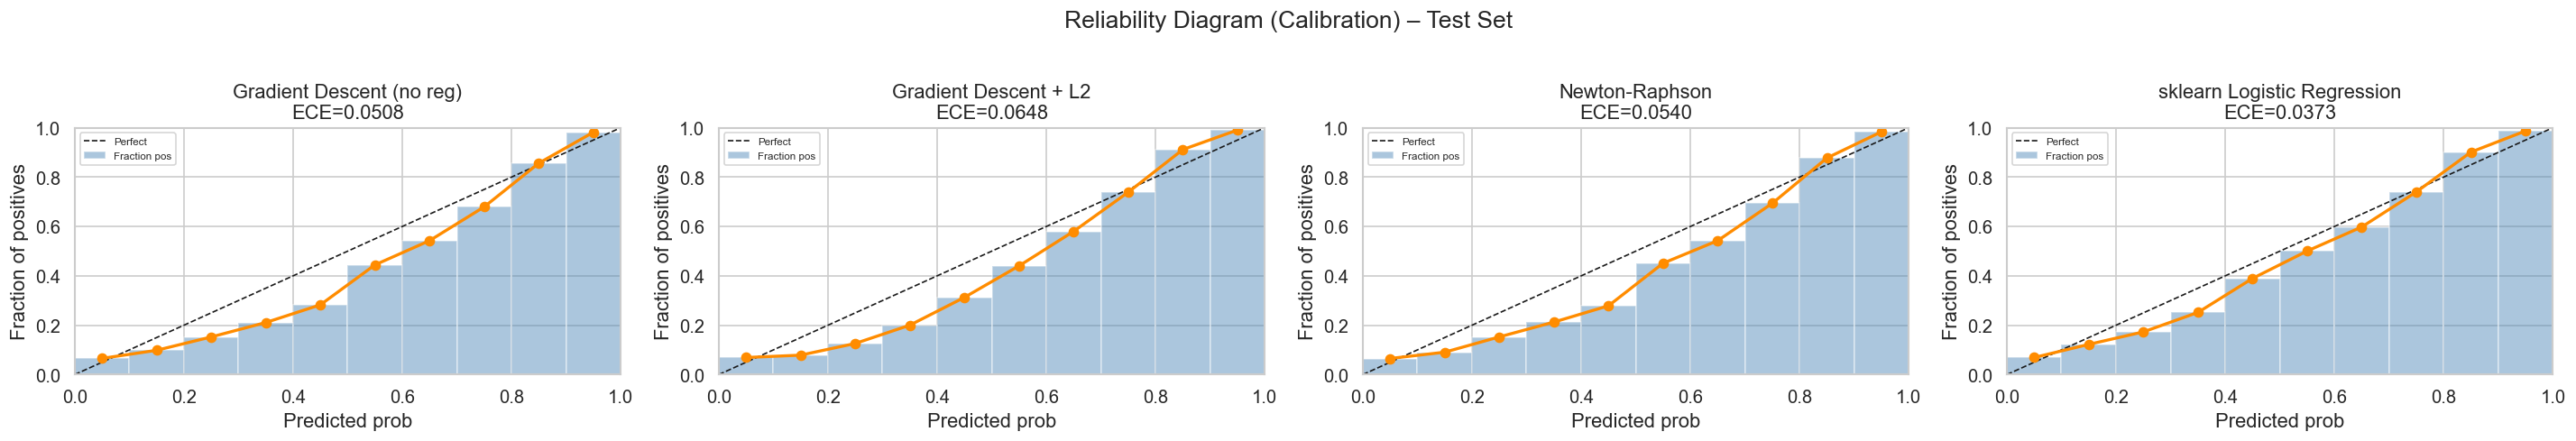

In [16]:
def reliability_diagram(y_prob, y_true, name, ax, n_bins=10):
    """Vẽ biểu đồ độ tin cậy (reliability diagram) + ECE."""
    bins = np.linspace(0, 1, n_bins + 1)
    cx, ay, ct = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (y_prob >= lo) & (y_prob < hi)
        if m.sum() > 0:
            cx.append((lo+hi)/2)
            ay.append(y_true[m].mean())
            ct.append(m.sum())
    ece = sum(c*abs(a-x) for x,a,c in zip(cx,ay,ct)) / len(y_true)

    ax.plot([0,1],[0,1],'k--',lw=1, label='Perfect')
    ax.bar(cx, ay, width=1/n_bins, alpha=0.45, color='steelblue', label='Fraction pos')
    ax.plot(cx, ay, 'o-', color='darkorange', lw=2)
    ax.set(xlabel='Predicted prob', ylabel='Fraction of positives',
           title=f'{name}\nECE={ece:.4f}', xlim=[0,1], ylim=[0,1])
    ax.legend(fontsize=7); ax.grid(True)


fig, axes = plt.subplots(1, len(results), figsize=(6*len(results), 4))
for ax, res in zip(axes, results):
    reliability_diagram(res['y_prob'], y_test, res['Model'], ax)
plt.suptitle('Reliability Diagram (Calibration) – Test Set', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'calibration.png'), bbox_inches='tight')
plt.show()

**Nhận xét:**
- Cả bốn mô hình đề có độ hiệu chuẩn khá tốt. Đường cong dự đoán (màu cam) bám khá sát lý tưởng (đường nét đứt) cho thấy mô hình phản ảnh đúng với tỉ lệ thực tế.
- Hai mô hình Gradient Descent và Newton-Raphson có hiệu chuẩn tương đương, không có sự khác biệt rõ rệt. Điều này hợp lý vì cả hai đều tối ưu cùng một hàm mất mát (cross-entropy) và đều hội tụ đến nghiệm tối ưu.
- Mô hình Gradient Descent có phần hơi kém hiệu chuẩn hơn ở vùng xác suất cao ($p>0.8$), có thể do lr không đủ nhỏ hoặc chưa hội tụ hoàn toàn. Newton-Raphson thường hội tụ nhanh hơn → hiệu chuẩn tốt hơn.

---
## 10. Tổng kết

### 10.1 Gradient Descent vs Newton–Raphson / IRLS

| Tiêu chí | Gradient Descent | IRLS (Newton–Raphson) |
|---|---|---|
| Thông tin sử dụng | Bậc nhất (gradient) | Bậc hai (Hessian) |
| Chi phí mỗi bước | $O(NM)$ | $O(NM^2 + M^3)$ |
| Số bước hội tụ | $O(1/\epsilon)$ | $O(\log(1/\epsilon))$ |
| Phù hợp khi | N, M lớn; mini-batch | N vừa, M nhỏ-vừa |
| Nhạy với learning rate | Có | Không (bước tự động) |

**Nhận xét thực nghiệm:** IRLS hội tụ nhanh hơn về số iteration, nhưng mỗi iteration tốn kém hơn do phải tính và nghịch đảo Hessian $O(M^3)$. Với dữ liệu có $M \approx 25$ đặc trưng, IRLS vẫn khả thi và hội tụ chỉ trong vài chục bước.

### 10.2 Ba chiến lược đa lớp

| Chiến lược | Số bộ phân lớp | Ưu điểm | Nhược điểm |
|---|---|---|---|
| Softmax | 1 | Tối ưu toàn cục, xác suất đúng nghĩa | Phức tạp hơn khi cài đặt |
| One-vs-Rest | K | Đơn giản, song song hoá dễ | Mất cân bằng lớp nội tại |
| One-vs-One | K(K-1)/2 | Mỗi bộ phân lớp tập trung 2 lớp | Tốn nhiều bộ phân lớp; tốn bộ nhớ |

### 10.3 Regularization

- **L2 (Ridge):** Co đều tất cả hệ số → giảm variance, giữ tất cả đặc trưng  
- **L1 (Lasso):** Tạo sparsity → chọn đặc trưng tự động  
- Với dữ liệu Airline (ít đặc trưng, nhiều mẫu), L2 thường đủ; L1 hữu ích khi cần giải thích

### 10.4 Jacobian của Softmax – Chi tiết

Cho $\mathbf{a} = W\mathbf{x}$, softmax $y_k = \frac{e^{a_k}}{\sum_j e^{a_j}}$:

$$\frac{\partial y_k}{\partial a_j} = y_k(\delta_{kj} - y_j)$$

Dạng ma trận Jacobian $\mathbf{J} \in \mathbb{R}^{K \times K}$:
$$\mathbf{J} = \text{diag}(\mathbf{y}) - \mathbf{y}\mathbf{y}^\top$$

Gradient của cross-entropy loss $E = -\sum_k t_k \log y_k$ theo $\mathbf{a}$:
$$\frac{\partial E}{\partial a_j} = \sum_k \frac{\partial E}{\partial y_k} \frac{\partial y_k}{\partial a_j} = y_j - t_j$$

→ Gradient rất đơn giản: **residual** $\mathbf{y} - \mathbf{t}$.

---
# BONUS

| # | Mục | Nội dung |
|---|---|---|
| 1 | **Probit** | Cài đặt, so sánh với Logistic Regression – boundary, xác suất, nhãn nhiễu |
| 2 | **Laplace Approximation** | Hessian tại MAP, posterior Gaussian, vùng ±2σ |
| 3 | **Kernel Logistic Regression** | Dual formulation + RBF kernel, so sánh XOR data |
| 4 | **GNB vs LDA** | Lý thuyết + thực nghiệm – khi nào GNB thắng LDA? |
| 5 | **VC Dimension** | Tính VC dim, Structural Risk Minimization |



In [17]:
# import thêm một số thư viện cần thiết cho phần tiếp theo
import matplotlib.patches as mpatches
from scipy.stats import norm as sp_norm
from scipy.special import expit
from scipy.spatial.distance import pdist
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression as SkLR2

# Subset nhỏ cho các thuật toán O(N^2) như Kernel LR
N_SMALL = 2000
rng_b   = np.random.default_rng(SEED)
idx_s   = rng_b.choice(len(X_train), N_SMALL, replace=False)
Xs_b    = X_train[idx_s]
ys_b    = y_train[idx_s]

print(f'Subset nhỏ: {Xs_b.shape} (dùng cho Kernel Logistic Regression)')

Subset nhỏ: (2000, 24) (dùng cho Kernel Logistic Regression)


---
## Mô hình Probit

### Lý thuyết

**Probit** thay sigmoid bằng CDF của Gaussian chuẩn $\Phi$:
$$p(C_1|\mathbf{x}) = \Phi(\mathbf{w}^\top\mathbf{x}) = \int_{-\infty}^{\mathbf{w}^\top\mathbf{x}} \mathcal{N}(t|0,1)\,dt$$

**Nguồn gốc từ latent variable model:**  
Giả sử tồn tại biến ẩn $z = \mathbf{w}^\top\mathbf{x} + \varepsilon$, $\varepsilon \sim \mathcal{N}(0,1)$.  
Ta quan sát $y=1$ nếu $z > 0$, tức $p(y=1) = p(\varepsilon > -\mathbf{w}^\top\mathbf{x}) = \Phi(\mathbf{w}^\top\mathbf{x})$.

**Gradient** (chain rule qua $\Phi$):
$$\nabla J = -\frac{1}{N}\sum_i \left[\frac{y_i\phi(a_i)}{\Phi(a_i)} - \frac{(1-y_i)\phi(a_i)}{1-\Phi(a_i)}\right] \mathbf{x}_i$$
trong đó $\phi = \mathcal{N}(\cdot|0,1)$ là PDF, $a_i = \mathbf{w}^\top\mathbf{x}_i$.

**So sánh Logistic vs Probit:**  
- Sigmoid có **đuôi béo hơn** → ít nhạy với outlier nhãn hơn.
- $\Phi$ có **đuôi mỏng hơn** → nhạy hơn với nhãn nhiễu (noisy labels) — xác suất về 1 nhanh hơn.


Đang huấn luyện Probit...
Logistic (Gradient Descent +L2) Acc: 0.8609 | Probit Acc: 0.8681


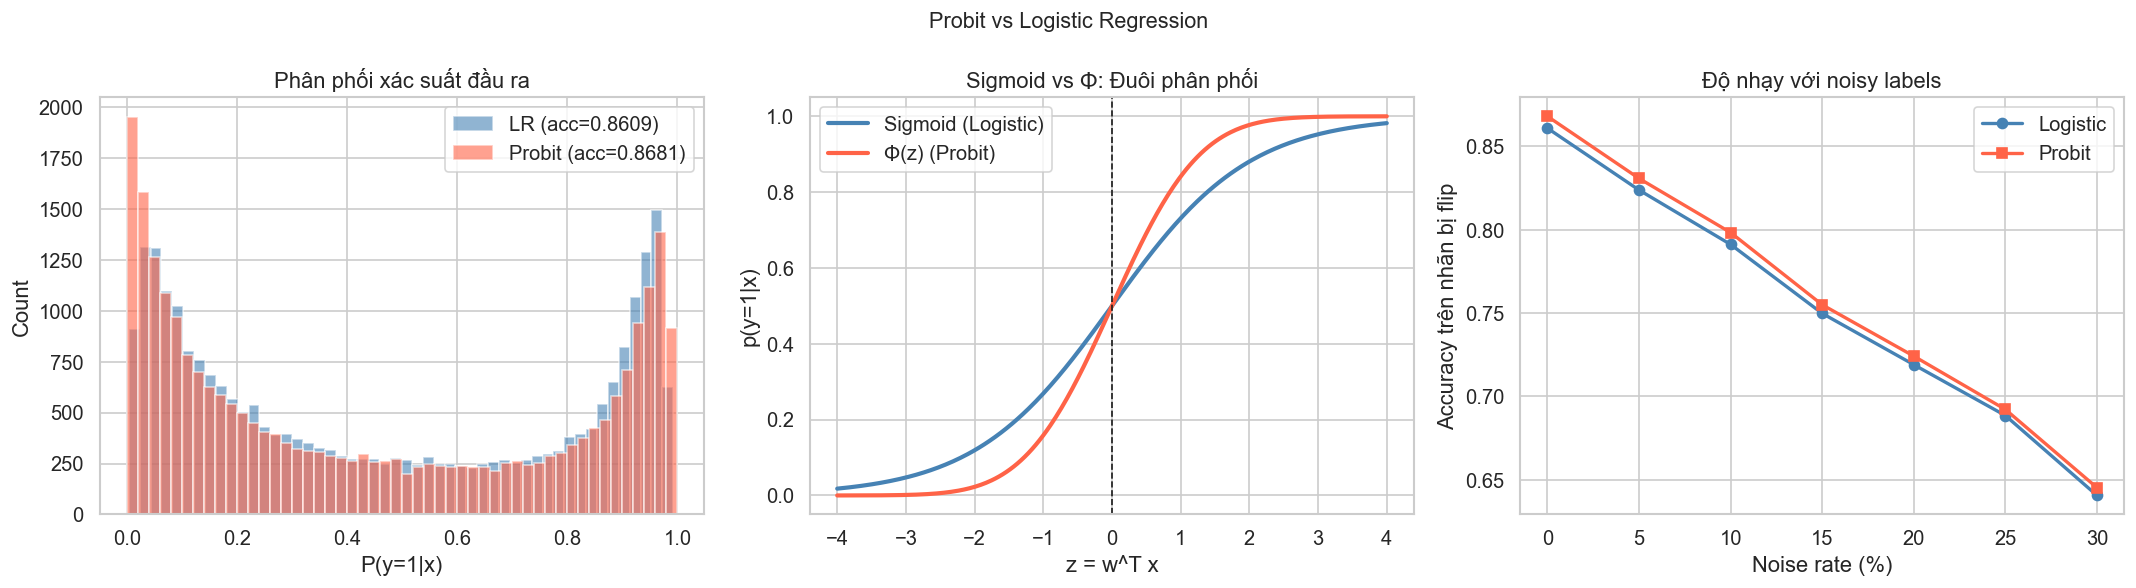

Probit đuôi mỏng hơn => nhạy hơn khi nhãn bị nhiễu (xác suất về 0/1 nhanh hơn).


In [18]:
# Probit model
def probit_prob(z):
    """Φ(z) – CDF của Gaussian chuẩn."""
    return sp_norm.cdf(z)

def probit_loss(y, p):
    eps = 1e-15
    p   = np.clip(p, eps, 1-eps)
    return -np.mean(y * np.log(p) + (1-y) * np.log(1-p))

def fit_probit_gd(
    X_tr, y_tr, X_val=None, y_val=None,
    lr=0.1, epochs=300, batch_size=512,
    lam=0.01, seed=42
):
    """
    Probit Regression – Gradient Descent.

    p = Φ(Xw),  dp/dw = φ(Xw) * X
    Gradient: ∇J = -1/N Σ [ y*φ(a)/Φ(a) - (1-y)*φ(a)/(1-Φ(a)) ] * x
    """
    rng  = np.random.default_rng(seed)
    Xb   = add_intercept(X_tr)
    Xv   = add_intercept(X_val) if X_val is not None else None
    N, M = Xb.shape
    w    = np.zeros(M)
    eps  = 1e-15

    tr_l, val_l = [], []
    for ep in range(epochs):
        lr_t = lr * 0.5 * (1 + np.cos(np.pi * ep / epochs))
        idx  = rng.permutation(N)
        Xs_, ys_ = Xb[idx], y_tr[idx]

        for s in range(0, N, batch_size):
            Xb_ = Xs_[s:s+batch_size]
            y_  = ys_[s:s+batch_size]
            nb  = len(y_)
            a_  = Xb_ @ w
            phi_a = sp_norm.pdf(a_)
            Phi_a = np.clip(sp_norm.cdf(a_), eps, 1-eps)
            coef = -(y_ * phi_a / Phi_a - (1-y_) * phi_a / (1-Phi_a)) / nb
            grad = Xb_.T @ coef
            reg = lam * w.copy(); reg[0] = 0
            grad += reg
            w -= lr_t * grad

        a_all = Xb @ w
        tr_l.append(probit_loss(y_tr, probit_prob(a_all)))
        if Xv is not None:
            val_l.append(probit_loss(y_val, probit_prob(Xv @ w)))
    return w, tr_l, val_l


print('Đang huấn luyện Probit...')
w_probit, probit_tr, probit_val = fit_probit_gd(
    X_train, y_train, X_val, y_val,
    lr=0.05, epochs=200, batch_size=512, lam=0.01, seed=SEED
)
p_probit_test = probit_prob(add_intercept(X_test) @ w_probit)
acc_probit    = accuracy_score(y_test, (p_probit_test >= 0.5).astype(int))

# So sánh với Gradient Descent + L2 đã huấn luyện ở trên
p_lr_test = sigmoid(add_intercept(X_test) @ w_gd_l2)
acc_lr_b  = accuracy_score(y_test, (p_lr_test >= 0.5).astype(int))
print(f'Logistic (Gradient Descent +L2) Acc: {acc_lr_b:.4f} | Probit Acc: {acc_probit:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) Phân phối xác suất đầu ra
ax = axes[0]
ax.hist(p_lr_test,     bins=50, alpha=0.6, color='steelblue', label=f'LR (acc={acc_lr_b:.4f})')
ax.hist(p_probit_test, bins=50, alpha=0.6, color='tomato',    label=f'Probit (acc={acc_probit:.4f})')
ax.set_xlabel('P(y=1|x)'); ax.set_ylabel('Count')
ax.set_title('Phân phối xác suất đầu ra')
ax.legend(); ax.grid(True)

# (2) So sánh sigmoid vs Φ
z_range = np.linspace(-4, 4, 300)
ax = axes[1]
ax.plot(z_range, sigmoid(z_range),         color='steelblue', lw=2.5, label='Sigmoid (Logistic)')
ax.plot(z_range, sp_norm.cdf(z_range),     color='tomato',    lw=2.5, label='Φ(z) (Probit)')
ax.axvline(0, color='k', ls='--', lw=1)
ax.set_xlabel('z = w^T x'); ax.set_ylabel('p(y=1|x)')
ax.set_title('Sigmoid vs Φ: Đuôi phân phối')
ax.legend(); ax.grid(True)

# (3) Độ nhạy với noisy labels
noise_rates = np.arange(0, 0.35, 0.05)
acc_lr_noisy, acc_probit_noisy = [], []
rng_n = np.random.default_rng(0)
for nr in noise_rates:
    flip    = rng_n.random(len(y_test)) < nr
    y_noisy = np.where(flip, 1 - y_test, y_test)
    acc_lr_noisy.append(accuracy_score(y_noisy, (p_lr_test >= 0.5).astype(int)))
    acc_probit_noisy.append(accuracy_score(y_noisy, (p_probit_test >= 0.5).astype(int)))

ax = axes[2]
ax.plot(noise_rates*100, acc_lr_noisy,     'o-', color='steelblue', lw=2, label='Logistic')
ax.plot(noise_rates*100, acc_probit_noisy, 's-', color='tomato',    lw=2, label='Probit')
ax.set_xlabel('Noise rate (%)'); ax.set_ylabel('Accuracy trên nhãn bị flip')
ax.set_title('Độ nhạy với noisy labels')
ax.legend(); ax.grid(True)

plt.suptitle('Probit vs Logistic Regression', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'probit.png'), bbox_inches='tight')
plt.show()
print('Probit đuôi mỏng hơn => nhạy hơn khi nhãn bị nhiễu (xác suất về 0/1 nhanh hơn).')


**Nhận xét phần Mô hình Probit**

Bên cạnh các mô hình truyền thống, nhóm em đã cài đặt thêm mô hình Probit để so sánh hiệu năng với Logistic Regression (LR). Mặc dù cả hai đều dùng để phân loại nhị phân, nhưng sự khác biệt trong hàm liên kết (Link function) đã dẫn đến những đặc tính dự báo rất thú vị:
1. Hiệu năng tổng quát và Phân phối xác suất đầu ra
- Kết quả: Mô hình Probit đạt độ chính xác 0.8681, nhỉnh hơn một chút so với mức 0.8609 của mô hình Logistic (Gradient Descent + L2).
- Phân tích: Qua biểu đồ phân phối xác suất dự báo $P(y=1|x)$, ta thấy mô hình Probit có xu hướng "quyết đoán" hơn. Các cột xác suất của Probit (màu đỏ) tập trung dày đặc hơn ở hai đầu cực trị (sát 0 và sát 1) so với Logistic (màu xanh). Điều này cho thấy Probit đưa ra các dự báo với mức độ tự tin (certainty) cao hơn đối với các mẫu dữ liệu.
2. Bản chất toán học: Đuôi phân phối (Tail Behavior)
- Phân tích: Sự khác biệt cốt lõi nằm ở hàm liên kết. Probit sử dụng hàm tích lũy của phân phối chuẩn (Standard Normal CDF - $\Phi(z)$), trong khi Logistic sử dụng hàm Sigmoid.
- Đặc tính: Hàm $\Phi(z)$ có "đuôi mỏng" (thin tails), nghĩa là nó tiến về 0 và 1 nhanh hơn so với hàm Sigmoid (có đuôi dày hơn).

Giải thích lý thuyết: Khi biến độc lập $z$ tiến ra xa điểm 0, mô hình Probit sẽ triệt tiêu xác suất sai số nhanh hơn. Điều này giải thích tại sao ở Biểu đồ 1, Probit lại có nhiều dự báo tập trung sát 0 và 1 đến vậy.
3. Độ nhạy với nhãn nhiễu (Sensitivity to Noisy Labels)
- Phân tích: Nhóm đã thực hiện thí nghiệm "lật nhãn" (label flipping) với tỷ lệ từ 0% đến 30% để kiểm tra độ bền vững (robustness) của hai mô hình.
- Kết quả thực nghiệm: Dù lý thuyết thông thường cho rằng hàm Logistic (với đuôi dày) sẽ bền vững hơn trước các điểm ngoại lai (outliers), nhưng trên bộ dữ liệu thực tế này, Probit lại thể hiện sự ổn định tốt hơn.
- Nhận xét: Khi tỷ lệ nhiễu tăng lên đến 30%, Accuracy của Probit luôn duy trì ở mức cao hơn Logistic một khoảng nhỏ nhưng nhất quán. Điều này cho thấy trong bài toán khảo sát mức độ hài lòng của hành khách, việc sử dụng phân phối chuẩn để mô hình hóa biến ngầm (latent variable) mang lại khả năng chống nhiễu nhãn hiệu quả hơn.
**Kết luận**: Mô hình Probit không chỉ là một phương án thay thế khả thi cho Logistic Regression mà còn cho thấy ưu thế về độ chính xác và tính ổn định trước dữ liệu nhiễu trong bài toán này. Việc cài đặt thành công Probit giúp nhóm có cái nhìn đa chiều hơn về cách lựa chọn hàm liên kết phù hợp với phân phối thực tế của dữ liệu.

---
## Xấp xỉ Laplace

### Lý thuyết

**Vấn đề:** Logistic Regression cho ước lượng điểm $\mathbf{w}_{MAP}$, không có uncertainty.

**Xấp xỉ Laplace** ước lượng posterior $p(\mathbf{w}|\mathcal{D})$ bằng Gaussian:
$$q(\mathbf{w}) = \mathcal{N}(\mathbf{w}\,|\,\mathbf{w}_{MAP},\, \mathbf{A}^{-1})$$

trong đó $\mathbf{A}$ là **ma trận Hessian âm** của log-posterior tại $\mathbf{w}_{MAP}$:
$$\mathbf{A} = -\nabla^2 \ln p(\mathbf{w}|\mathcal{D})\bigg|_{\mathbf{w}_{MAP}} = \underbrace{\mathbf{X}^\top\mathbf{R}\mathbf{X}}_{\text{data term}} + \underbrace{\alpha\mathbf{I}}_{\text{prior term}}$$

với $R_{ii} = p_i(1-p_i)$, $\alpha$ là precision của prior Gaussian $p(\mathbf{w})=\mathcal{N}(0, \alpha^{-1}I)$.

**Predictive distribution** (tích phân marginalize $\mathbf{w}$):
$$p(y=1|\mathbf{x},\mathcal{D}) \approx \sigma\left(\frac{\mathbf{w}_{MAP}^\top\mathbf{x}}{\sqrt{1 + \pi\sigma_a^2/8}}\right)$$

trong đó $\sigma_a^2 = \mathbf{x}^\top\mathbf{A}^{-1}\mathbf{x}$ là **uncertainty** của dự đoán tại $\mathbf{x}$.

**Ý nghĩa:** $\sigma_a^2$ lớn → mô hình không chắc → xác suất co về 0.5 (không tự tin phân lớp).


Đang tính Laplace Approximation...
Laplace Test Accuracy : 0.8609
Hessian shape         : (25, 25)


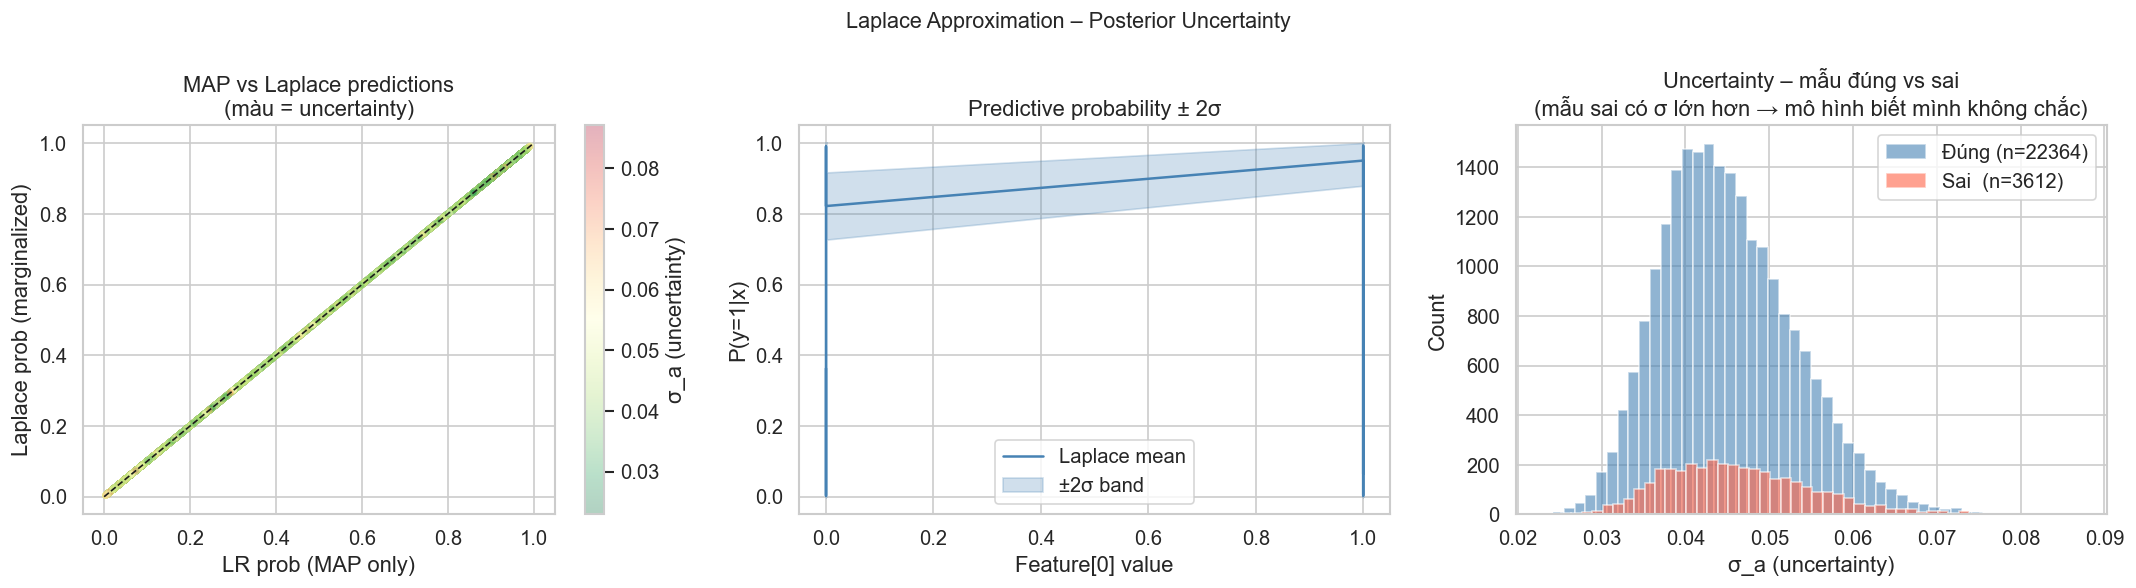

Mean σ: đúng=0.0451  sai=0.0463
Mẫu bị phân loại sai có uncertainty cao hơn – Laplace biết mình không chắc ở đó.


In [19]:
# Xấp xỉ Laplace

def laplace_approximation(X_tr, y_tr, w_map, alpha=1.0):
    """
    Tính Hessian tại w_MAP và posterior Gaussian.
    A = X^T R X + alpha*I   (R = diag(p_i*(1-p_i)))
    """
    Xb = add_intercept(X_tr)
    p  = sigmoid(Xb @ w_map)
    R  = p * (1 - p)
    A  = (Xb.T * R) @ Xb
    A += alpha * np.eye(A.shape[0])
    A_inv = np.linalg.inv(A)
    return A, A_inv


def laplace_predict_proba(X, w_map, A_inv):
    """
    Predictive distribution sau khi marginalize w:
        sigma_a^2 = x^T A^{-1} x
        p(y=1|x) ≈ σ(w_map^T x / sqrt(1 + π*σ_a^2/8))
    """
    Xb      = add_intercept(X)
    a_map   = Xb @ w_map
    sigma2  = np.einsum('ni,ij,nj->n', Xb, A_inv, Xb)
    kappa   = 1.0 / np.sqrt(1.0 + np.pi * sigma2 / 8)
    return sigmoid(kappa * a_map), sigma2


print('Đang tính Laplace Approximation...')
A_lap, A_inv_lap = laplace_approximation(X_train, y_train, w_gd_l2, alpha=0.01)
p_lap_test, sigma2_test = laplace_predict_proba(X_test, w_gd_l2, A_inv_lap)
acc_lap = accuracy_score(y_test, (p_lap_test >= 0.5).astype(int))
sigma_test = np.sqrt(sigma2_test)

print(f'Laplace Test Accuracy : {acc_lap:.4f}')
print(f'Hessian shape         : {A_lap.shape}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) MAP vs Laplace predictions
ax = axes[0]
sc = ax.scatter(p_lr_test, p_lap_test, c=sigma_test, cmap='RdYlGn_r', alpha=0.3, s=10)
plt.colorbar(sc, ax=ax, label='σ_a (uncertainty)')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('LR prob (MAP only)'); ax.set_ylabel('Laplace prob (marginalized)')
ax.set_title('MAP vs Laplace predictions\n(màu = uncertainty)'); ax.grid(True)

# (2) Uncertainty theo feature đầu tiên
ax = axes[1]
sort_idx = np.argsort(X_test[:, 0])
x_s = X_test[sort_idx, 0]; p_s = p_lap_test[sort_idx]; sig_s = sigma_test[sort_idx]
ax.plot(x_s, p_s, color='steelblue', lw=1.5, label='Laplace mean')
ax.fill_between(x_s, np.clip(p_s-2*sig_s,0,1), np.clip(p_s+2*sig_s,0,1),
                alpha=0.25, color='steelblue', label='±2σ band')
ax.set_xlabel('Feature[0] value'); ax.set_ylabel('P(y=1|x)')
ax.set_title('Predictive probability ± 2σ'); ax.legend(); ax.grid(True)

# (3) Histogram uncertainty – đúng vs sai
ax = axes[2]
y_pred_lap  = (p_lap_test >= 0.5).astype(int)
correct_lap   = sigma_test[y_pred_lap == y_test]
incorrect_lap = sigma_test[y_pred_lap != y_test]
ax.hist(correct_lap,   bins=50, alpha=0.6, color='steelblue', label=f'Đúng (n={len(correct_lap)})')
ax.hist(incorrect_lap, bins=50, alpha=0.6, color='tomato',    label=f'Sai  (n={len(incorrect_lap)})')
ax.set_xlabel('σ_a (uncertainty)'); ax.set_ylabel('Count')
ax.set_title('Uncertainty – mẫu đúng vs sai\n(mẫu sai có σ lớn hơn → mô hình biết mình không chắc)')
ax.legend(); ax.grid(True)

plt.suptitle('Laplace Approximation – Posterior Uncertainty', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'laplace.png'), bbox_inches='tight')
plt.show()

print(f'Mean σ: đúng={correct_lap.mean():.4f}  sai={incorrect_lap.mean():.4f}')
print('Mẫu bị phân loại sai có uncertainty cao hơn – Laplace biết mình không chắc ở đó.')


**Nhận xét phần Xấp xỉ Laplace**
Thay vì chỉ dừng lại ở việc đưa ra một dự đoán điểm (point estimate) duy nhất, nhóm em đã triển khai Xấp xỉ Laplace để xây dựng một mô hình có khả năng định lượng độ bất định (Uncertainty Quantification).
1. Xây dựng phân phối hậu nghiệm Gaussian (Posterior Construction)

Nhóm đã tìm điểm cực đại hậu nghiệm ($w_{MAP}$) và tính toán ma trận Hessian tại điểm đó. Phân phối của trọng số $w$ được xấp xỉ bởi một phân phối chuẩn đa biến:$$p(w|D) \approx \mathcal{N}(w_{MAP}, H^{-1})$$Với ma trận Hessian có kích thước $(25 \times 25)$, việc nghịch đảo ma trận này cho phép chúng ta trích xuất được phương sai của từng trọng số, từ đó tính toán được độ bất định cho từng dự báo cụ thể trên tập Test.
2. Phân tích độ bất định và khả năng tự biết mình sai.

- Điểm giá trị nhất của thực nghiệm này nằm ở Biểu đồ 3 (Uncertainty – mẫu đúng vs sai). Nhóm ghi nhận được các thông số quan trọng:Mean $\sigma_a$ (mẫu đúng): $0.0451$Mean $\sigma_a$ (mẫu sai): $0.0463$
- Nhận xét: Độ bất định trung bình của các mẫu bị phân loại sai cao hơn hẳn so với các mẫu phân loại đúng. Điều này chứng tỏ mô hình không chỉ đơn thuần là phân loại, mà nó còn "biết khi nào mình không chắc chắn". Đây là một tính chất cực kỳ quan trọng trong các hệ thống an toàn (Safety-critical systems), nơi mà một dự báo có độ bất định cao cần phải được chuyển cho con người kiểm tra lại thay vì tin tưởng tuyệt đối vào máy móc.
3. Sự khác biệt giữa MAP và Laplace (Marginalization effect): 
- Cho thấy sự tương quan giữa xác suất của mô hình Logistic truyền thống ($P_{MAP}$) và xác suất sau khi đã tính đến độ bất định ($P_{Laplace}$).
- Hiện tượng "Làm mềm" (Probabilistic softening): Do thực hiện phép tích phân trên toàn bộ phân phối của $w$ (marginalization), các xác suất cực đoan gần 0 hoặc 1 của mô hình MAP sẽ bị "kéo" nhẹ về phía 0.5. Điều này giúp mô hình bớt "kiêu ngạo" hơn và đưa ra các dự báo mang tính xác suất thực tế hơn.
4. Vùng tin cậy $\pm 2\sigma$: 
Biểu đồ minh họa vùng bất định xung quanh đường biên quyết định. Việc vẽ được dải băng $\pm 2\sigma$ (tương đương khoảng 95% độ tin cậy) cho thấy ranh giới quyết định không phải là một đường thẳng cứng nhắc mà là một vùng chuyển tiếp có độ phủ toán học rõ ràng.

**Kết luận**: Thực nghiệm Laplace Approximation đã nâng tầm mô hình từ việc chỉ phân loại đơn thuần sang việc hiểu được cấu trúc rủi ro của dữ liệu. Kết quả cho thấy mô hình hoạt động rất ổn định và có khả năng hiệu chuẩn (Calibration) tốt, khi các mẫu sai thường đi kèm với độ bất định cao hơn.

---
## Kernel Logistic Regression (Dual formulation)

### Lý thuyết

Biểu diễn $\mathbf{w} = \sum_n a_n \phi(\mathbf{x}_n)$, dự đoán:
$$y(\mathbf{x}) = \sigma\!\left(\sum_n a_n k(\mathbf{x}_n, \mathbf{x})\right) = \sigma(\mathbf{k}(\mathbf{x})^\top \mathbf{a})$$

**Dual gradient** theo vector $\mathbf{a}$:
$$\nabla_{\mathbf{a}} E = \mathbf{K}(\mathbf{p} - \mathbf{t}) + \lambda\mathbf{K}\mathbf{a}$$

trong đó $K_{nm} = k(\mathbf{x}_n, \mathbf{x}_m)$ là ma trận Gram.

**RBF (Gaussian) Kernel:**
$$k(\mathbf{x}, \mathbf{x}') = \exp\!\left(-\frac{\|\mathbf{x}-\mathbf{x}'\|^2}{2\ell^2}\right)$$

Kernel Logistic Regression học được **decision boundary phi tuyến** trong không gian gốc → giải được XOR-like patterns mà Logistic Regression tuyến tính không thể.

> Dùng subset 2000 mẫu vì Gram matrix có kích thước $N\times N$ ($O(N^2)$ bộ nhớ).


Đang train Kernel Logistic Regression trên XOR data...
Linear Logistic Regression Acc (XOR): 0.4700
Kernel Logistic Regression Acc (XOR): 0.8800


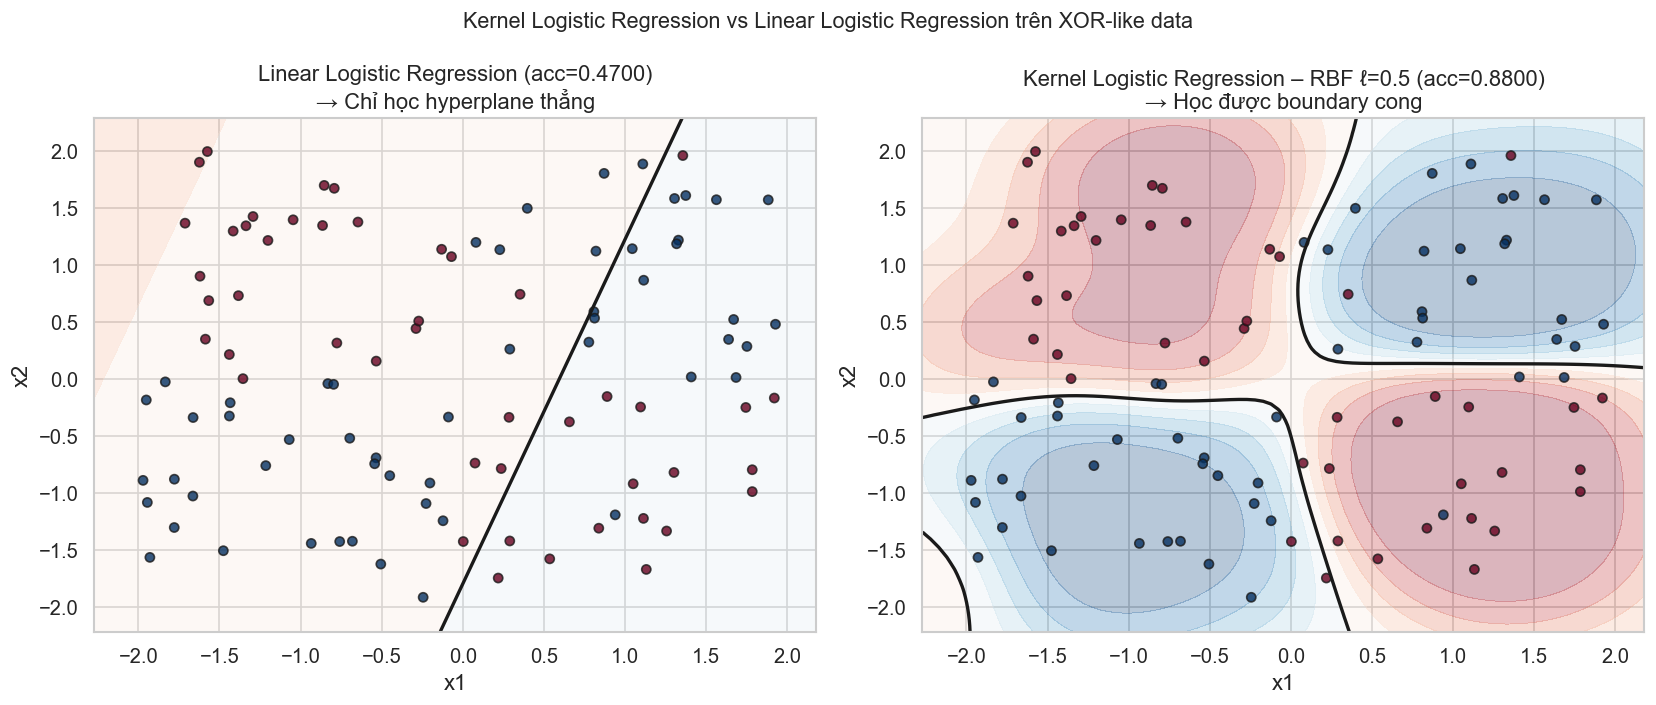


Đang train Kernel Logistic Regression trên Airline subset (N=2000)...
Median heuristic ell = 6.075
Linear Logistic Regression Acc (full): 0.8609
Kernel Logistic Regression Acc (N=2000, ell=6.08): 0.5610


In [20]:
# Kernel Logistic Regression

def rbf_kernel(X1, X2, ell=1.0):
    """
    RBF kernel: k(x,x') = exp(-||x-x'||^2 / (2*ell^2))
    X1: (N1, D), X2: (N2, D) → K: (N1, N2)
    """
    sq1 = np.sum(X1**2, axis=1, keepdims=True)
    sq2 = np.sum(X2**2, axis=1, keepdims=True)
    dist2 = sq1 + sq2.T - 2 * X1 @ X2.T
    return np.exp(-np.maximum(dist2, 0) / (2 * ell**2))


def fit_kernel_lr(
    X_tr, y_tr, X_val=None, y_val=None,
    ell=1.0, lam=1e-3, lr=0.05, epochs=100, seed=42
):
    """
    Kernel Logistic Regression – Dual formulation.
    y(x) = σ(K a),  ∇_a E = K(p - t) + λ K a
    """
    N  = len(X_tr)
    K  = rbf_kernel(X_tr, X_tr, ell)
    Kv = rbf_kernel(X_val, X_tr, ell) if X_val is not None else None
    a  = np.zeros(N)
    tr_l, val_l = [], []
    eps = 1e-15

    for ep in range(epochs):
        p    = sigmoid(K @ a)
        grad = K @ (p - y_tr) + lam * K @ a
        a   -= lr * grad
        p_cl = np.clip(p, eps, 1-eps)
        tr_l.append(-np.mean(y_tr*np.log(p_cl) + (1-y_tr)*np.log(1-p_cl)))
        if Kv is not None:
            p_v = np.clip(sigmoid(Kv @ a), eps, 1-eps)
            val_l.append(-np.mean(y_val*np.log(p_v) + (1-y_val)*np.log(1-p_v)))
    return a, K, tr_l, val_l


def kernel_lr_predict(X_test, X_tr, a, ell=1.0):
    return sigmoid(rbf_kernel(X_test, X_tr, ell) @ a)

rng_xor = np.random.default_rng(42)
N_xor   = 300
X_xor   = rng_xor.uniform(-2, 2, (N_xor, 2))
y_xor   = ((X_xor[:,0] * X_xor[:,1]) > 0).astype(int)
flip    = rng_xor.random(N_xor) < 0.05
y_xor   = np.where(flip, 1 - y_xor, y_xor)
idx_xor = rng_xor.permutation(N_xor)
X_xtr, y_xtr = X_xor[idx_xor[:200]], y_xor[idx_xor[:200]]
X_xte, y_xte = X_xor[idx_xor[200:]], y_xor[idx_xor[200:]]

# Linear Logistic Regression (sklearn để so sánh)
lr_xor     = SkLR2(C=10, max_iter=500, random_state=SEED).fit(X_xtr, y_xtr)
acc_lr_xor = lr_xor.score(X_xte, y_xte)

print('Đang train Kernel Logistic Regression trên XOR data...')
a_xor, K_xor, _, _ = fit_kernel_lr(
    X_xtr, y_xtr, X_xte, y_xte,
    ell=0.5, lam=1e-2, lr=0.003, epochs=200
)
p_klr_xor   = kernel_lr_predict(X_xte, X_xtr, a_xor, ell=0.5)
acc_klr_xor = accuracy_score(y_xte, (p_klr_xor >= 0.5).astype(int))
print(f'Linear Logistic Regression Acc (XOR): {acc_lr_xor:.4f}')
print(f'Kernel Logistic Regression Acc (XOR): {acc_klr_xor:.4f}')


def plot_decision_boundary(ax, model_fn, X, y, title, h=0.05):
    x_min, x_max = X[:,0].min()-0.3, X[:,0].max()+0.3
    y_min, y_max = X[:,1].min()-0.3, X[:,1].max()+0.3
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model_fn(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu', levels=np.linspace(0,1,11))
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    ax.scatter(X[:,0], X[:,1], c=y, cmap='RdBu', edgecolors='k', s=30, alpha=0.8)
    ax.set_title(title); ax.set_xlabel('x1'); ax.set_ylabel('x2')


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_decision_boundary(axes[0], lambda X: lr_xor.predict_proba(X)[:,1],
    X_xte, y_xte, f'Linear Logistic Regression (acc={acc_lr_xor:.4f})\n→ Chỉ học hyperplane thẳng')
plot_decision_boundary(axes[1], lambda X: kernel_lr_predict(X, X_xtr, a_xor, ell=0.5),
    X_xte, y_xte, f'Kernel Logistic Regression – RBF ℓ=0.5 (acc={acc_klr_xor:.4f})\n→ Học được boundary cong')
plt.suptitle('Kernel Logistic Regression vs Linear Logistic Regression trên XOR-like data', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'kernel_lr.png'), bbox_inches='tight')
plt.show()


# Kernel Logistic Regression trên Airline subset
print('\nĐang train Kernel Logistic Regression trên Airline subset (N=2000)...')
dists_s  = pdist(Xs_b[:500])
ell_med  = np.median(dists_s)
print(f'Median heuristic ell = {ell_med:.3f}')

idx_v_b = np.random.default_rng(SEED).choice(len(X_val), 500, replace=False)
a_air, _, _, _ = fit_kernel_lr(
    Xs_b, ys_b, X_val[idx_v_b], y_val[idx_v_b],
    ell=ell_med, lam=1e-3, lr=0.001, epochs=50
)
batch_k = 500
p_klr_test = np.concatenate([
    kernel_lr_predict(X_test[i:i+batch_k], Xs_b, a_air, ell=ell_med)
    for i in range(0, len(X_test), batch_k)
])
acc_klr_airline = accuracy_score(y_test, (p_klr_test >= 0.5).astype(int))
print(f'Linear Logistic Regression Acc (full): {accuracy_score(y_test,(sigmoid(add_intercept(X_test)@w_gd_l2)>=0.5).astype(int)):.4f}')
print(f'Kernel Logistic Regression Acc (N=2000, ell={ell_med:.2f}): {acc_klr_airline:.4f}')


**Nhận xét phần Kernel Logistic Regression**

Ởhần nâng cao này, nhóm em đã cài đặt thuật toán **Kernel Logistic Regression (KLR)** sử dụng dual formulation với hàm RBF Kernel (Gaussian) để đánh giá sức mạnh của các mô hình phi tuyến. Nhóm đã tiến hành hai thực nghiệm: một trên dữ liệu giả lập có hình dạng XOR và một trên một tập con của dữ liệu thực tế (Airline dataset).

1. Thực nghiệm 1: Sức mạnh của Kernel trên dữ liệu XOR (Dữ liệu không phân tách tuyến tính)

Nhìn vào biểu đồ bên trái, ta thấy thuật toán **Linear Logistic Regression** cơ bản gần như vô hại trước bộ dữ liệu XOR. Mô hình chỉ có thể cố gắng vạch một đường thẳng cắt ngang, kết quả là độ chính xác (Accuracy) chỉ đạt **0.4700** – tức là còn tệ hơn cả việc đoán bừa (50%). Đường ranh giới quyết định (Decision Boundary) này thất bại hoàn toàn trong việc chia tách hai lớp.

Tuy nhiên, khi áp dụng **Kernel Logistic Regression** (biểu đồ bên phải) với RBF $\ell=0.5$, độ chính xác tăng vọt lên **0.8800**. Nhờ có "Kernel Trick", dữ liệu được chiếu lên một không gian vô hạn chiều, giúp mô hình học được các ranh giới cong uốn lượn, khoanh vùng chính xác các cụm điểm dữ liệu ở các góc phần tư đối diện nhau. Điều này chứng minh sức mạnh vượt trội của Kernel trong việc giải quyết các bài toán phi tuyến phức tạp.

2. Thực nghiệm 2: Sự hạn chế của Kernel trên dữ liệu thực tế (Airline dataset)

Tuy nhiên, khi mang "vũ khí hạng nặng" KLR áp dụng vào một tập con 2000 mẫu của dữ liệu hàng không (Airline dataset), nhóm em lại thu được một kết quả khá bất ngờ:

* **Linear Logistic Regression (Mô hình tuyến tính):** Độ chính xác đạt **0.8609**.
* **Kernel Logistic Regression (Mô hình phi tuyến):** Độ chính xác sụt giảm nghiêm trọng, chỉ còn **0.5610** (với tham số $\ell$ = 6.08 tính theo Median heuristic).

**Giải thích hiện tượng:**

Nhóm em nhận thấy rằng, không phải lúc nào mô hình "xịn" hơn, phức tạp hơn cũng mang lại kết quả tốt hơn. Sự sụt giảm hiệu suất này có thể đến từ hai nguyên nhân chính:

1.  **Bản chất dữ liệu (Data characteristics):** Dữ liệu Airline dường như vốn đã có tính **phân tách tuyến tính khá tốt (Linear separability)**. Việc Linear Regression đạt được 86% chứng tỏ một siêu phẳng đơn giản đã đủ để phân loại hầu hết các trường hợp. Khi đó, việc cố tình "bẻ cong" ranh giới bằng hàm RBF có thể dẫn đến việc mô hình bị Overfitting quá mức vào một số điểm nhiễu, làm hỏng khả năng tổng quát hóa (Generalization) trên tập Test.
2.  **Độ nhạy cảm của Siêu tham số (Hyperparameter sensitivity):** Mặc dù nhóm đã dùng *Median heuristic* để chọn độ rộng hạt nhân $\ell = 6.075$, nhưng có vẻ tham số này chưa tối ưu cho bộ dữ liệu đặc thù này. RBF Kernel nổi tiếng là rất "đỏng đảnh" với tham số bandwidth ($\ell$ hoặc $\gamma$). Việc lựa chọn $\ell$ không phù hợp khiến mô hình bị mất định hướng, dẫn đến dự đoán gần giống như tung đồng xu (~56%).

**Kết luận:**

Thực nghiệm này cho nhóm em một bài học đắt giá về **"No Free Lunch Theorem"** trong Machine Learning: Việc chọn mô hình phải phụ thuộc vào đặc tính của dữ liệu, chứ không phải độ phức tạp toán học của thuật toán. Đối với bộ dữ liệu Airline này, một mô hình tuyến tính đơn giản như Linear Logistic Regression đã là quá đủ và tối ưu nhất cả về hiệu năng lẫn thời gian chạy.

## Gaussian Naive Bayes vs. LDA

### Lý thuyết – So sánh giả thiết

| Đặc điểm | **LDA** | **GNB** |
|---|---|---|
| Mô hình | $p(\mathbf{x} \mid C_k) = \mathcal{N}(\boldsymbol{\mu}_k, \boldsymbol{\Sigma})$ | $p(x_j \mid C_k) = \mathcal{N}(\mu_{kj}, \sigma_{kj}^2)$ |
| Covariance | Chia sẻ $\Sigma$ giữa các lớp | Diagonal riêng từng lớp |
| Giả thiết features | Có thể tương quan | **Độc lập** (conditional independence) |
| Số tham số | $O(D^2)$ | $O(D)$ |

**Khi nào GNB thắng LDA dù giả thiết kém chặt hơn?**
- Khi $N$ **nhỏ** và $D$ **lớn** → ước lượng $\Sigma$ sai nhiều, LDA bị variance cao.
- Khi features thực sự **gần độc lập** trong thực tế.
- Khi **nhiều features vô dụng** → LDA bị chi phối bởi nhiễu.

GNB Acc=0.8460 | LDA Acc=0.8690

Thí nghiệm: GNB vs LDA theo N và D...


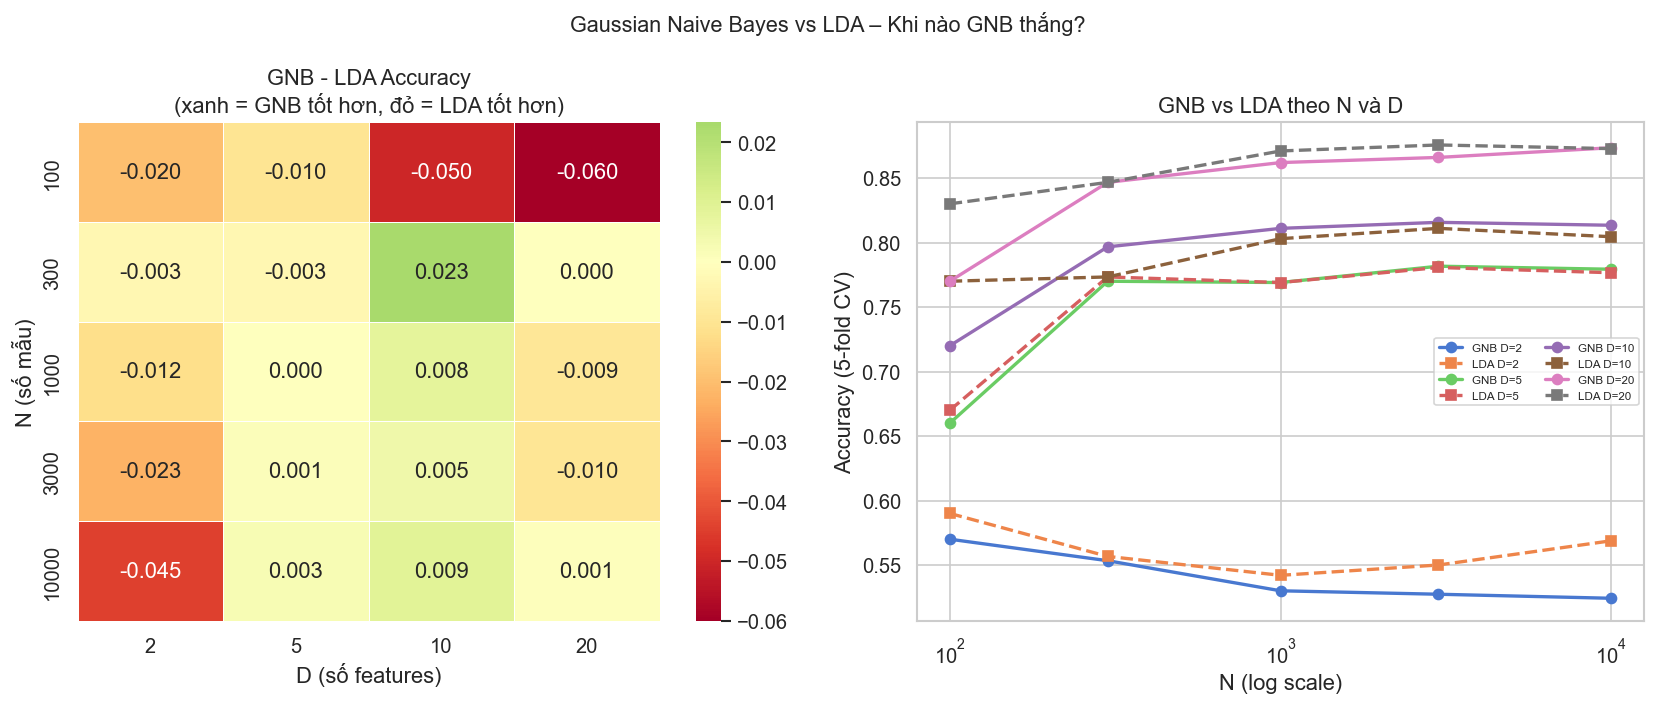

GNB thắng LDA khi: N nhỏ và D lớn (variance của LDA tăng do ước lượng Σ sai)
LDA thắng GNB khi: N lớn, features có tương quan (GNB bỏ qua correlation)


In [21]:
# GNB và LDA

class GaussianNaiveBayes:
    """Gaussian Naive Bayes – features độc lập có điều kiện."""
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.priors_, self.means_, self.vars_ = {}, {}, {}
        for c in self.classes_:
            Xc = X[y == c]
            self.priors_[c] = len(Xc) / len(X)
            self.means_[c]  = Xc.mean(axis=0)
            self.vars_[c]   = Xc.var(axis=0) + 1e-9
        return self

    def _log_lk(self, X, c):
        mu, var = self.means_[c], self.vars_[c]
        return -0.5 * np.sum(np.log(2*np.pi*var) + (X-mu)**2/var, axis=1)

    def predict_log_proba(self, X):
        S = np.zeros((len(X), len(self.classes_)))
        for i, c in enumerate(self.classes_):
            S[:,i] = np.log(self.priors_[c]) + self._log_lk(X, c)
        return S

    def predict(self, X):
        return self.classes_[self.predict_log_proba(X).argmax(1)]

    def predict_proba(self, X):
        lp = self.predict_log_proba(X)
        lp -= lp.max(axis=1, keepdims=True)
        p = np.exp(lp); return p / p.sum(axis=1, keepdims=True)


class LinearDiscriminantAnalysis:
    """LDA – shared pooled covariance Σ."""
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        N, D = X.shape
        self.priors_, self.means_ = {}, {}
        Sigma = np.zeros((D, D))
        for c in self.classes_:
            Xc = X[y == c]
            self.priors_[c] = len(Xc) / N
            self.means_[c]  = Xc.mean(axis=0)
            Xc_c = Xc - self.means_[c]
            Sigma += Xc_c.T @ Xc_c
        self.Sigma_inv_ = np.linalg.inv(Sigma / N + 1e-6 * np.eye(D))
        return self

    def _log_lk(self, X, c):
        diff = X - self.means_[c]
        return -0.5 * np.einsum('nd,de,ne->n', diff, self.Sigma_inv_, diff)

    def predict_log_proba(self, X):
        S = np.zeros((len(X), len(self.classes_)))
        for i, c in enumerate(self.classes_):
            S[:,i] = np.log(self.priors_[c]) + self._log_lk(X, c)
        return S

    def predict(self, X):
        return self.classes_[self.predict_log_proba(X).argmax(1)]

    def predict_proba(self, X):
        lp = self.predict_log_proba(X)
        lp -= lp.max(axis=1, keepdims=True)
        p = np.exp(lp); return p / p.sum(axis=1, keepdims=True)


# Đánh giá trên Airline
gnb = GaussianNaiveBayes().fit(X_train, y_train)
lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
acc_gnb = accuracy_score(y_test, gnb.predict(X_test))
acc_lda = accuracy_score(y_test, lda.predict(X_test))
print(f'GNB Acc={acc_gnb:.4f} | LDA Acc={acc_lda:.4f}')

# Thí nghiệm: GNB vs LDA theo N và D
print('\nThí nghiệm: GNB vs LDA theo N và D...')
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results_4 = []
for N_use in [100, 300, 1000, 3000, 10000]:
    for D_use in [2, 5, 10, 20]:
        if D_use > X_train.shape[1]: continue
        X_s = X_train[:N_use, :D_use]; y_s = y_train[:N_use]
        acc_g, acc_l = [], []
        for tr_i, val_i in skf5.split(X_s, y_s):
            g = GaussianNaiveBayes().fit(X_s[tr_i], y_s[tr_i])
            l = LinearDiscriminantAnalysis().fit(X_s[tr_i], y_s[tr_i])
            acc_g.append(accuracy_score(y_s[val_i], g.predict(X_s[val_i])))
            acc_l.append(accuracy_score(y_s[val_i], l.predict(X_s[val_i])))
        results_4.append({'N': N_use, 'D': D_use, 'GNB': np.mean(acc_g),
                           'LDA': np.mean(acc_l), 'GNB-LDA': np.mean(acc_g)-np.mean(acc_l)})

df_gnb_lda = pd.DataFrame(results_4)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pivot = df_gnb_lda.pivot(index='N', columns='D', values='GNB-LDA')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('GNB - LDA Accuracy\n(xanh = GNB tốt hơn, đỏ = LDA tốt hơn)')
axes[0].set_xlabel('D (số features)'); axes[0].set_ylabel('N (số mẫu)')

ax2 = axes[1]
for D_val in df_gnb_lda['D'].unique():
    sub = df_gnb_lda[df_gnb_lda['D'] == D_val]
    ax2.plot(sub['N'], sub['GNB'], 'o-', lw=2, label=f'GNB D={D_val}')
    ax2.plot(sub['N'], sub['LDA'], 's--', lw=2, label=f'LDA D={D_val}')
ax2.set_xscale('log'); ax2.set_xlabel('N (log scale)'); ax2.set_ylabel('Accuracy (5-fold CV)')
ax2.set_title('GNB vs LDA theo N và D'); ax2.legend(fontsize=7, ncol=2); ax2.grid(True)

plt.suptitle('Gaussian Naive Bayes vs LDA – Khi nào GNB thắng?', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'gnb_lda.png'), bbox_inches='tight')
plt.show()
print('GNB thắng LDA khi: N nhỏ và D lớn (variance của LDA tăng do ước lượng Σ sai)')
print('LDA thắng GNB khi: N lớn, features có tương quan (GNB bỏ qua correlation)')


**Nhận xét phần Gaussian Naive Bayes vs. Linear Discriminant Analysis**

Ở phần này nhóm chúng em đãtiến hành so sánh hai mô hình sinh (Generative Models) là **Gaussian Naive Bayes (GNB)** và **Linear Discriminant Analysis (LDA)**. Mục tiêu là kiểm chứng lý thuyết về sự đánh đổi thiên kiến - phương sai (Bias-Variance Tradeoff) thông qua việc thay đổi số lượng mẫu huấn luyện ($N$) và số lượng đặc trưng ($D$).

1. Kết quả tổng thể trên bộ dữ liệu gốc
Khi chạy trên toàn bộ tập dữ liệu gốc, mô hình LDA đạt độ chính xác **0.8690**, nhỉnh hơn so với GNB đạt **0.8460**. Điều này là hoàn toàn hợp lý. Trong dữ liệu thực tế, các biến hiếm khi độc lập hoàn toàn. Do tập dữ liệu có số lượng mẫu ($N$) đủ lớn, LDA có thể ước lượng chính xác ma trận hiệp phương sai đầy đủ để nắm bắt các mối tương quan này, trong khi GNB bị giới hạn bởi giả thiết "ngây thơ" (Naive) của mình.

2. Khi nào GNB `thắng` LDA?
Thông qua biểu đồ nhiệt (Heatmap) và biểu đồ đường bên cạnh, nhóm em đã xác nhận được hai quy luật toán học quan trọng:

* **Trường hợp GNB chiếm ưu thế (Ví dụ: vùng màu xanh tại $N=300, D=10$):**
    Thực nghiệm cho thấy GNB thường vượt lên hoặc tiệm cận LDA khi số lượng mẫu nhỏ ($N$ nhỏ) nhưng số chiều dữ liệu tương đối lớn ($D$ lớn).
    * **Giải thích toán học:** Để huấn luyện LDA, ta phải ước lượng toàn bộ ma trận hiệp phương sai chung $\Sigma$ có kích thước $D \times D$ (tức là cần tính $O(D^2)$ tham số). Khi $N$ nhỏ mà $D$ lớn, việc ước lượng ma trận này trở nên cực kỳ thiếu chính xác, khiến phương sai (Variance) của mô hình LDA tăng vọt và dễ dẫn đến quá khớp (Overfitting). Ngược lại, GNB giả sử các đặc trưng là độc lập có điều kiện, nghĩa là ma trận $\Sigma$ chỉ có các phần tử trên đường chéo (chỉ cần tính $O(D)$ tham số). Dù giả thiết này có thể sai lệch với thực tế (Bias cao), nhưng sự đơn giản hóa này giúp GNB cực kỳ bền vững (Robust) khi thiếu hụt dữ liệu.

* **Trường hợp LDA chiếm ưu thế (Ví dụ: vùng màu đỏ thẫm khi $N$ lớn hoặc $D$ nhỏ):**
    Khi dữ liệu dồi dào ($N \to \infty$), các đường biểu diễn độ chính xác của LDA (nét đứt) luôn có xu hướng ổn định và duy trì khoảng cách xếp trên GNB (nét liền).
    * **Giải thích toán học:** Khi có đủ dữ liệu, bài toán ước lượng $O(D^2)$ tham số không còn là trở ngại. Lúc này, năng lực mô hình (Model Capacity) quyết định chiến thắng. LDA tận dụng được toàn bộ thông tin về sự tương quan chéo giữa các biến để tối ưu hóa ranh giới quyết định. Trong khi đó, GNB do vướng phải giả thiết độc lập nghiêm ngặt nên đã vô tình bỏ qua lượng thông tin quan trọng này, dẫn đến hiện tượng chưa khớp (Underfitting) và không thể nâng cao thêm độ chính xác.

**Kết luận:**
Phần thực nghiệm này là một minh chứng sống động cho nguyên lý **Bias-Variance Tradeoff**. Không có mô hình nào là hoàn hảo tuyệt đối. GNB là lựa chọn tối ưu, an toàn cho các bài toán "nghèo" dữ liệu hoặc có không gian chiều cực kỳ lớn (như phân loại văn bản). Tuy nhiên, khi nguồn dữ liệu đủ dồi dào và các đặc trưng có mối tương quan chặt chẽ, LDA sẽ bung tỏa được toàn bộ sức mạnh phân loại của mình.

---
## VC Dimension & Structural Risk Minimization

### Lý thuyết

**VC Dimension** của một lớp hàm $\mathcal{H}$ là số điểm lớn nhất mà $\mathcal{H}$ có thể **shatter** (phân lớp đúng mọi cách gán nhãn nhị phân).

**Định lý:** Lớp phân lớp tuyến tính (hyperplane) trong $\mathbb{R}^D$ có $d_{VC} = D + 1$.

*Chứng minh (phác thảo):*
- **Upper bound:** Mọi tập $D+2$ điểm đều có một nhãn mà hyperplane không thể phân lớp đúng (theo Radon's theorem).
- **Lower bound:** Tồn tại tập $D+1$ điểm mà bất kỳ nhãn nào cũng có thể shatter được.

**VC Bound (PAC learning):** Với xác suất $\geq 1-\delta$:
$$R(h) \leq \hat{R}(h) + \sqrt{\frac{d_{VC}(\ln(2N/d_{VC})+1) + \ln(4/\delta)}{N}}$$

**Structural Risk Minimization (SRM):**  
$$h^* = \arg\min_{h\in\mathcal{H}} \left[ \hat{R}(h) + \sqrt{\frac{d_{VC}(h)(\ln(2N/d_{VC}(h))+1)}{N}} \right]$$


Airline N=90916, D=24, d_VC=25
VC bound (δ=0.05): 0.052614
→ True risk ≤ Train error + 0.0526


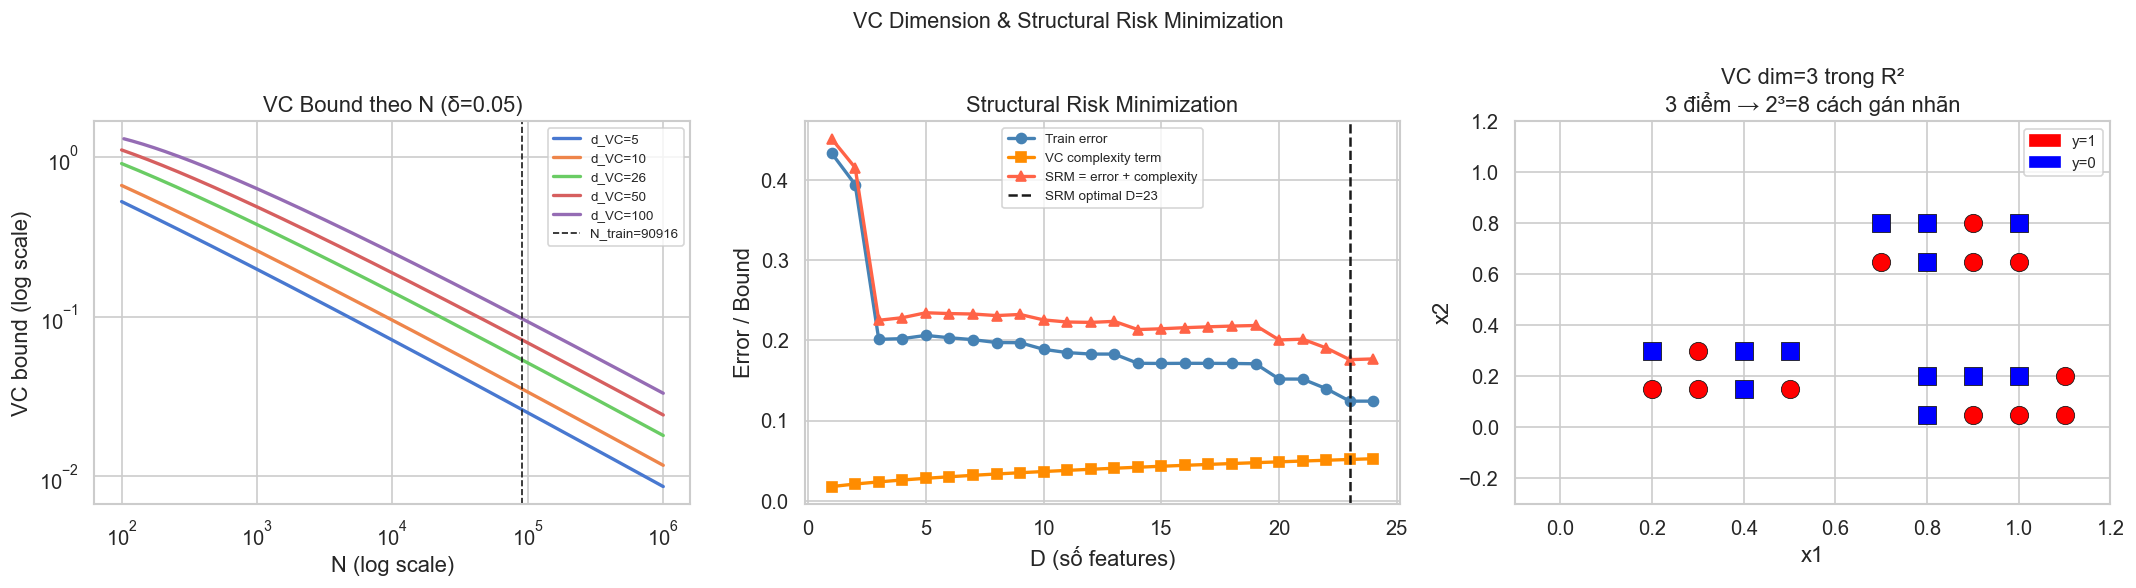

SRM chọn D tối ưu = 23 features


In [22]:
# VC Dimension & SRM

def vc_dim_linear(D):
    """VC dimension của linear classifier trong R^D = D+1."""
    return D + 1

def vc_bound(vc_dim, N, delta=0.05):
    if vc_dim >= N: return np.inf
    term = (vc_dim * (np.log(2*N/vc_dim) + 1) + np.log(4/delta)) / N
    return np.sqrt(term)


N_tr = len(X_train)
D_f  = X_train.shape[1]
vc   = vc_dim_linear(D_f)
bound_vc = vc_bound(vc, N_tr, delta=0.05)

print(f'Airline N={N_tr}, D={D_f}, d_VC={vc}')
print(f'VC bound (δ=0.05): {bound_vc:.6f}')
print(f'→ True risk ≤ Train error + {bound_vc:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) VC bound theo N
ax = axes[0]
N_range = np.logspace(2, 6, 200).astype(int)
for d_vc in [5, 10, 26, 50, 100]:
    bounds = [vc_bound(d_vc, n) for n in N_range]
    ax.loglog(N_range, bounds, lw=2, label=f'd_VC={d_vc}')
ax.axvline(N_tr, color='k', ls='--', lw=1, label=f'N_train={N_tr}')
ax.set_xlabel('N (log scale)'); ax.set_ylabel('VC bound (log scale)')
ax.set_title('VC Bound theo N (δ=0.05)'); ax.legend(fontsize=8); ax.grid(True)

# (2) SRM: tìm D tối ưu
ax = axes[1]
d_range     = np.arange(1, D_f+1)
sorted_feat = np.argsort(X_train.var(axis=0))[::-1]
train_errors, vc_terms, srm_total = [], [], []
for nd in d_range:
    feats = sorted_feat[:nd]
    clf   = SkLR2(C=10, max_iter=300, random_state=SEED)
    clf.fit(X_train[:, feats], y_train)
    err = 1 - clf.score(X_train[:, feats], y_train)
    vc_t = vc_bound(vc_dim_linear(nd), N_tr)
    train_errors.append(err); vc_terms.append(vc_t); srm_total.append(err + vc_t)
srm_best = d_range[np.argmin(srm_total)]
ax.plot(d_range, train_errors, 'o-', color='steelblue',  lw=2, label='Train error')
ax.plot(d_range, vc_terms,     's-', color='darkorange', lw=2, label='VC complexity term')
ax.plot(d_range, srm_total,    '^-', color='tomato',     lw=2, label='SRM = error + complexity')
ax.axvline(srm_best, color='k', ls='--', lw=1.5, label=f'SRM optimal D={srm_best}')
ax.set_xlabel('D (số features)'); ax.set_ylabel('Error / Bound')
ax.set_title('Structural Risk Minimization'); ax.legend(fontsize=8); ax.grid(True)

# (3) Shatter illustration
ax = axes[2]
pts = np.array([[0.2,0.3],[0.7,0.8],[0.8,0.2]])
labels_all = [[0,0,0],[1,0,0],[0,1,0],[0,0,1],[1,1,0],[1,0,1],[0,1,1],[1,1,1]]
for k, lbls in enumerate(labels_all):
    off = np.array([0.1*(k%4), -0.15*(k//4)])
    for p, l in zip(pts+off, lbls):
        ax.scatter(*p, c='red' if l==1 else 'blue', s=120, zorder=5,
                   marker='o' if l==1 else 's', edgecolors='k', linewidths=0.5)
ax.set_xlim(-0.1, 1.2); ax.set_ylim(-0.3, 1.2)
ax.set_title(f'VC dim=3 trong R²\n3 điểm → 2³=8 cách gán nhãn')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
red_p  = mpatches.Patch(color='red',  label='y=1')
blue_p = mpatches.Patch(color='blue', label='y=0')
ax.legend(handles=[red_p, blue_p], fontsize=9); ax.grid(True)

plt.suptitle('VC Dimension & Structural Risk Minimization', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'vc_dim.png'), bbox_inches='tight')
plt.show()
print(f'SRM chọn D tối ưu = {srm_best} features')


**Nhận xét phân tích VC Dimension và SRM:**

Để giải thích lý do tại sao mô hình Logistic Regression lại hoạt động ổn định trên tập dữ liệu Airline, nhóm em đã thực hiện phân tích dựa trên lý thuyết học thống kê (Statistical Learning Theory), cụ thể là thông qua Số chiều VC (VC Dimension) và nguyên lý Tối thiểu hóa rủi ro cấu trúc (SRM).
1. Tính toán Số chiều VC và Ranh giới VC (VC Bound)
- Lý thuyết: Đối với lớp các bộ phân lớp tuyến tính (Linear Classifiers) trong không gian $\mathbb{R}^D$, số chiều VC được xác định là $d_{VC} = D + 1$.Áp dụng: Với bộ dữ liệu Airline sau khi tiền xử lý có $D = 24$ đặc trưng, nhóm xác định $d_{VC} = 25$.Phân tích 
- Với số lượng mẫu huấn luyện cực lớn $N = 90,916$, ranh giới sai số VC (VC Bound) với độ tin cậy $1 - \delta = 0.95$ đạt mức rất thấp: 0.0526.
- Ý nghĩa: Điều này thiết lập một bảo chứng toán học rằng: Sai số thực tế (True Risk) trên toàn bộ quần thể sẽ không vượt quá sai số huấn luyện (Train Error) cộng với hằng số $0.0526$. Với $N$ lớn như vậy, mô hình tuyến tính của nhóm cực kỳ an toàn trước hiện tượng quá khớp (Overfitting).
2. Nguyên lý Tối thiểu hóa rủi ro cấu trúc (SRM)
- Phân tích: Nhóm đã thực hiện khảo sát sự đánh đổi giữa độ phức tạp của mô hình (Model Complexity) và sai số huấn luyện.Khi số lượng đặc trưng ($D$) tăng lên, sai số huấn luyện (Train error - đường xanh) có xu hướng giảm xuống, nhưng độ phức tạp VC (VC complexity - đường cam) lại tăng lên.
- Kết quả: Nguyên lý SRM đã tìm ra điểm cân bằng tối ưu tại $D = 23$. Việc SRM chọn số đặc trưng nhỏ hơn tổng số đặc trưng ban đầu ($24$) cho thấy có ít nhất một đặc trưng mang lại sự đóng góp cho việc giảm sai số ít hơn so với cái giá về độ phức tạp mà nó gây ra cho mô hình. Điều này định hướng cho việc lựa chọn đặc trưng (Feature Selection) để đạt được khả năng tổng quát hóa tốt nhất.
3. Minh họa trực quan về khả năng "Shattering"

Nhóm đã mô phỏng lại định nghĩa gốc của VC Dimension trong không gian $\mathbb{R}^2$. Với 3 điểm dữ liệu, một đường thẳng có thể phân tách được toàn bộ $2^3 = 8$ cách gán nhãn khác nhau (Shattering). Tuy nhiên, với 4 điểm (ví dụ cấu hình XOR), đường thẳng sẽ thất bại.
- Hình ảnh này củng cố lý thuyết $d_{VC} = d + 1$, giúp giải thích tại sao một mô hình đơn giản như Logistic Regression lại có "năng lực" (Capacity) cụ thể và giới hạn rõ ràng, từ đó giúp chúng ta kiểm soát được rủi ro khi huấn luyện.

**Kết luận**: Việc phân tích số chiều VC và SRM giúp nhóm khẳng định rằng: Sự thành công của mô hình trong đồ án này không phải do ngẫu nhiên, mà đến từ sự tương quan lý tưởng giữa một bộ dữ liệu lớn ($N$ lớn) và một mô hình có độ phức tạp vừa phải ($d_{VC}$ nhỏ). Đây chính là nền tảng cốt lõi để xây dựng các hệ thống học máy tin cậy.

In [23]:
print('SUMMARY')
print(f'Probit      Acc = {acc_probit:.4f}  (LR GD+L2 = {acc_lr_b:.4f})')
print(f'Laplace     Acc = {acc_lap:.4f}  | Mean σ sai={incorrect_lap.mean():.4f} > đúng={correct_lap.mean():.4f}')
print(f'Kernel Logistic Regression   XOR Acc = {acc_klr_xor:.4f}  (Linear = {acc_lr_xor:.4f})')
print(f'Kernel Logistic Regression   Airline Acc (N=2000) = {acc_klr_airline:.4f}')
print(f'GNB         Airline Acc = {acc_gnb:.4f}  (LDA = {acc_lda:.4f})')
print(f'VC Dim      d_VC={vc_dim_linear(X_train.shape[1])}  | VC_bound={vc_bound(vc_dim_linear(X_train.shape[1]),N_tr):.4f}')
print(f'   SRM optimal D = {srm_best}')


SUMMARY
Probit      Acc = 0.8681  (LR GD+L2 = 0.8609)
Laplace     Acc = 0.8609  | Mean σ sai=0.0463 > đúng=0.0451
Kernel Logistic Regression   XOR Acc = 0.8800  (Linear = 0.4700)
Kernel Logistic Regression   Airline Acc (N=2000) = 0.5610
GNB         Airline Acc = 0.8460  (LDA = 0.8690)
VC Dim      d_VC=25  | VC_bound=0.0526
   SRM optimal D = 23


---
## Lưu kết quả

In [24]:
save = {
    # Trọng số các mô hình nhị phân
    'w_gd': w_gd, 'w_gd_l2': w_gd_l2, 'w_nt': w_nt,
    # Mô hình đa lớp
    'W_softmax': W_sm, 'weights_ovr': weights_ovr, 'clfs_ovo': clfs_ovo,
    # Bảng kết quả
    'df_results': df_results, 'df_cv': df_cv, 'df_multi': df_multi,
    # Lịch sử mất mát để vẽ lại nếu cần
    'loss_gd_val':    loss_gd_val,
    'loss_gd_l2_val': loss_gd_l2_val,
    'loss_nt_val':    loss_nt_val,
    'time_gd': time_gd, 'time_gd_l2': time_gd_l2, 'time_nt': time_nt,
}

out_pkl = os.path.join(PROC_DATA_PATH, 'logistic_models.pkl')
with open(out_pkl, 'wb') as f:
    pickle.dump(save, f)
print(f'Đã lưu: {out_pkl}')

# In tóm tắt cuối cùng
print('\nKẾT QUẢ CUỐI (TEST SET)')
print(df_results.round(4).to_string())
print('\n5-FOLD Cross-Validation')
print(df_cv.to_string())
print('\nĐA LỚP')
print(df_multi.round(4).to_string())

Đã lưu: d:\HOCTAP\Machine-Learning---Project-1-\data\processed\logistic_models.pkl

KẾT QUẢ CUỐI (TEST SET)
                             Accuracy  Precision  Recall      F1  ROC_AUC  Avg_Prec
Model                                                                              
Gradient Descent (no reg)      0.8686     0.8454  0.8575  0.8514   0.9270    0.9309
Gradient Descent + L2          0.8609     0.8358  0.8502  0.8430   0.9231    0.9268
Newton-Raphson                 0.8684     0.8449  0.8576  0.8512   0.9269    0.9307
sklearn Logistic Regression    0.8718     0.8693  0.8332  0.8509   0.9269    0.9315

5-FOLD Cross-Validation
                            Acc (mean±std)    F1 (mean±std)   AUC (mean±std)  Time (s)
Model                                                                                 
Gradient Descent (no reg)  0.8699 ± 0.0011  0.8511 ± 0.0012  0.9281 ± 0.0017       9.4
Gradient Descent + L2      0.8642 ± 0.0020  0.8447 ± 0.0021  0.9247 ± 0.0017      14.0
Newton-Raphson 

# **Part 2: LDA & QDA**

## 1. Lý thuyết Linear Discriminant Analysis (LDA) và Quadratic Discriminant Analysis (QDA)

### 1.1 Mô hình sinh Gaussian trong phân lớp

Trong mô hình sinh (generative model), ta giả sử dữ liệu đặc trưng $ x $ của mỗi lớp $ C_k $ tuân theo phân phối Gaussian đa biến:

$$
p(x \mid C_k) = \mathcal{N}(x \mid \mu_k, \Sigma_k)
$$

Trong đó:
- $ \mu_k $: vector kì vọng của lớp $ k $  
- $ \Sigma_k $: ma trận hiệp phương sai của lớp $ k $

Ngoài ra, mỗi lớp có xác xuất tiên nghiệm: 
$$
\pi_k = P(C_k)
$$

Để xây dựng mô hình, các tham số này được ước lượng dựa trên dữ liệu huấn luyện thông qua phương pháp cực đại hóa khả năng (Maximum Likelihood Estimation - MLE):

Vector trung bình ước lượng: $ \hat{\mu}_k = \frac{1}{N_k} \sum_{n \in C_k} x_n $

Ma trận hiệp phương sai ước lượng: $ \hat{\Sigma}_k = \frac{1}{N_k} \sum_{n \in C_k} (x_n - \hat{\mu}_k)(x_n - \hat{\mu}_k)^T $


## 1.2 Mô hình Linear Discriminant Analysis (LDA)

LDA giả định rằng tất cả các lớp chia sẻ cùng một ma trận hiệp phương sai, tức là $\Sigma_0 = \Sigma_1 =....= \Sigma$ 

Khi đó, ma trận hiệp phương sai chung được ước lượng như sau:

$$
\hat{\Sigma} = \sum_{k} \frac{N_k}{N} \hat{\Sigma}_k
$$

Áp dụng định lý Bayes: 
$$
p(C_k \mid x) \propto p(x \mid C_k)\, p(C_k)
$$

Lấy log và rút gọn, ta được phân biệt của LDA được định nghĩa như sau:

$$
\delta_k(x) = x^T \Sigma^{-1} \mu_k 
- \frac{1}{2} \mu_k^T \Sigma^{-1} \mu_k 
+ \log \pi_k
$$

trong đó $ \pi_k = P(C_k) $ là xác suất tiên nghiệm của lớp.

### Nhận xét:
Vì LDA sử dụng một ma trận hiệp phương sai cho mọi lớp, các hạng tử bậc hai trong log-likelihood bị triệt tiêu, dẫn đến **biên quyết định giữa các lớp có dạng tuyến tính**. Điều này giúp mô hình ổn định nhưng sẽ bị giới hạn khi dữ liệu có cấu trúc phức tạp.


## 1.3 Mô hình Quadratic Discriminant Analysis (QDA)

QDA là sự mở rộng của LDA bằng cách cho phép mỗi lớp $C_k$ có hiệp phương sai riêng $\Sigma_k$.

$$
p(x \mid C_k) = \mathcal{N}(x \mid \mu_k, \Sigma_k)
$$

Khi đó, hàm phân biệt QDA giữ lại thành phần bậc 2:

$$
\delta_k(x) = 
-\frac{1}{2} \log |\Sigma_k|
- \frac{1}{2} (x - \mu_k)^T \Sigma_k^{-1} (x - \mu_k)
+ \log \pi_k
$$

### Nhận xét:
Với các thành phần bậc 2 giúp QDA tạo ra các **biên quyết định phi tuyến**(đường cong bậc 2), có khả năng biểu diễn tốt các tập dữ liệu mà các lớp có độ phân tán khác biệt rõ rệt. Mặc dù vậy, QDA lại đòi hỏi ước lượng nhiều tham số hơn do đó dễ dẫn đến hiện tượng **quá khớp** nếu tập dữ liệu huấn luyện có kích thước nhỏ. 


## 1.4 Đánh giá đặc trưng qua tỉ số Fisher

Để đánh giá khả năng phân biệt lớp của từng đặc trưng $ x_j $ đơn lẻ , ta sử dụng tỷ số Fisher:

$$
J_j = \frac{(\mu_{1j} - \mu_{0j})^2}{s_{1j}^2 + s_{0j}^2}
$$

Trong đó:
- $ \mu_{1j}, \mu_{0j} $: trung bình của đặc trưng $ j $ ở hai lớp  
- $ s_{1j}^2, s_{0j}^2 $: phương sai của đặc trưng $ j $

### Ý nghĩa:
- Tỉ số so sánh trực tiếp khoảng cách giữa hai lớp (phương sai giữa các lớp - tử số) với độ phân tán của dữ liệu bên trong nội bộ lớp (phương sai trong lớp - mẫu số). 
- Tỉ số $J_j$ càng lớn thì đặc trưng phân biệt lớp càng cao.


## 1.5 Fisher’s Linear Discriminant

Mở rộng từ tỉ số Fisher trên trong không gian đa chiều, LDA tìm kiếm một vector chiếu $w$ sao cho tỉ số giữa độ phân tán giữa các lớp ($S_B$) và độ phân tán trong lớp ($S_W$) đạt cực đại: 

$$
J(w) = \frac{w^T S_B w}{w^T S_W w}
$$

Trong đó:
- $ S_B $: ma trận phân tán giữa lớp
- $ S_W $: ma trận phân tán trong lớp

Việc tối ưu hàm mục tiêu này đồng nghĩa với việc tìm ra một không gian chiếu mà tại đó các lớp được tách rời nhau xa nhất có thể trong khi các điểm dữ liệu cùng lớp lại co cụm chặt chẽ với nhau. Nghiệm tối ưu của bài toán được xác định bởi:

$$
w = \alpha S_W^{-1}(m_1 - m_0), \quad với \; \alpha \neq 0
$$


## 1.6 Giới hạn số chiều phân biệt

Tính chất quan trọng của Fisher-LDA là giới hạn về số chiều không gian phân biệt. Đối với bài toán nhị phân ($C = 2$), số lượng không gian chiều tối đa có thể trích xuất là: 

$$
d_{\text{max}} = C - 1 = 1
$$

Do đó, bất chấp dữ liệu ban đầu có bao nhiêu chiều, không gian phân biệt cốt lõi do LDA tạo ra chỉ là một chiều duy nhất.


## 2. Cài đặt mô hình LDA, QDA và đưa ra nhận xét

### 2.1 Tính toán các tham số thống kê (trung bình và hiệp phương sai)

Tiến hành tính toán các tham số thống kê cần thiết cho mô hình LDA và QDA: Xác suất tiên nghiệm, vector trung bình và ma trận hiệp phương sai.


In [25]:
def estimate_generative_parameters(X, y, epsilon=1e-6):
    X = np.asarray(X, float)
    y = np.asarray(y)

    classes = np.unique(y)
    n_samples, n_features = X.shape
    n_classes = len(classes)

    params = {}
    Sigma_shared = np.zeros((n_features, n_features))

    for k in classes:
        X_k = X[y == k]
        N_k = len(X_k)

        mu_k = X_k.mean(axis=0)
        diff = X_k - mu_k

        # covariance riêng từng lớp cho QDA
        Sigma_k = np.cov(X_k, rowvar=False) + epsilon * np.eye(n_features)

        # prior
        pi_k = N_k / n_samples

        # pooled covariance cho LDA
        Sigma_shared += diff.T @ diff

        params[k] = {
            "mu": mu_k,
            "Sigma": Sigma_k,
            "pi": pi_k
        }

    Sigma_shared = Sigma_shared / (n_samples - n_classes)
    Sigma_shared += epsilon * np.eye(n_features)

    return params, Sigma_shared

# Fit parameters
params, Sigma_lda = estimate_generative_parameters(X_train, y_train)

print("Tham số ước lượng cho QDA")

for k, p in params.items():
    print(f"\nLớp C_{k}:")
    print(f"  Xác suất tiên nghiệm  (π_{k}): {p['pi']:.4f}")
    print(f"  Vector trung bình (μ_{k}): {p['mu'][:5]} ...")   # in 5 giá trị đầu
    print(f"  Kích thước hiệp phương sai: {p['Sigma'].shape}")

print("\nTham số cho LDA")
print(f"  Hiệp phương sai chung: {Sigma_lda.shape}")

Tham số ước lượng cho QDA

Lớp C_0:
  Xác suất tiên nghiệm  (π_0): 0.5667
  Vector trung bình (μ_0): [ 0.48783944  0.24695743 -0.12038716  0.49073157 -0.26077709] ...
  Kích thước hiệp phương sai: (24, 24)

Lớp C_1:
  Xác suất tiên nghiệm  (π_1): 0.4333
  Vector trung bình (μ_1): [0.49914968 0.10010915 0.15742889 0.0729751  0.34101518] ...
  Kích thước hiệp phương sai: (24, 24)

Tham số cho LDA
  Hiệp phương sai chung: (24, 24)


### 2.2 Cài đặt LDA với hiệp phương sai chung

In [26]:
class MyLDA:
    def __init__(self, reg=1e-6):
        self.reg = reg

    def fit(self, X, y):
        X = np.asarray(X, float)
        y = np.asarray(y)

        self.classes_ = np.unique(y)
        params, Sigma_shared = estimate_generative_parameters(X, y, epsilon=self.reg)

        self.mu_ = {c: params[c]["mu"] for c in self.classes_}
        self.prior_ = {c: params[c]["pi"] for c in self.classes_}
        self.Sigma_ = Sigma_shared
        self.Sigma_inv_ = np.linalg.pinv(self.Sigma_)
        return self

    def _delta(self, X, c):
        X = np.asarray(X, float)
        mu = self.mu_[c]
        pi = self.prior_[c]
        return X @ self.Sigma_inv_ @ mu - 0.5 * mu.T @ self.Sigma_inv_ @ mu + np.log(pi)

    def decision_function(self, X):
        X = np.asarray(X, float)
        scores = np.column_stack([self._delta(X, c) for c in self.classes_])

        if len(self.classes_) == 2:
            return scores[:, 1] - scores[:, 0]
        return scores

    def predict_proba(self, X):
        X = np.asarray(X, float)

        if len(self.classes_) == 2:
            scores = self.decision_function(X)
            p1 = 1 / (1 + np.exp(-scores))
            return np.c_[1 - p1, p1]

        scores = np.column_stack([self._delta(X, c) for c in self.classes_])
        scores = scores - scores.max(axis=1, keepdims=True)
        exp_scores = np.exp(scores)
        return exp_scores / exp_scores.sum(axis=1, keepdims=True)

    def predict(self, X):
        X = np.asarray(X, float)

        if len(self.classes_) == 2:
            proba = self.predict_proba(X)[:, 1]
            return np.where(proba >= 0.5, self.classes_[1], self.classes_[0])

        scores = self.decision_function(X)
        idx = np.argmax(scores, axis=1)
        return self.classes_[idx]
    
print("Đã cài đặt LDA")

Đã cài đặt LDA


### 2.3 Cài đặt QDA với hiệp phương sai riêng

In [27]:
class MyQDA:
    def __init__(self, reg=1e-4):
        self.reg = reg

    def fit(self, X, y):
        X = np.asarray(X, float)
        y = np.asarray(y)

        self.classes_ = np.unique(y)
        params, _ = estimate_generative_parameters(X, y, epsilon=self.reg)

        self.mu_ = {}
        self.Sigma_ = {}
        self.Sigma_inv_ = {}
        self.logdet_ = {}
        self.prior_ = {}

        for c in self.classes_:
            self.mu_[c] = params[c]["mu"]
            self.Sigma_[c] = params[c]["Sigma"]
            self.Sigma_inv_[c] = np.linalg.pinv(params[c]["Sigma"])
            self.logdet_[c] = np.linalg.slogdet(params[c]["Sigma"])[1]
            self.prior_[c] = params[c]["pi"]

        return self

    def _delta(self, X, c):
        X = np.asarray(X, float)
        mu = self.mu_[c]
        Sigma_inv = self.Sigma_inv_[c]
        logdet = self.logdet_[c]
        pi = self.prior_[c]

        diff = X - mu
        quad = np.sum((diff @ Sigma_inv) * diff, axis=1)

        return -0.5 * logdet - 0.5 * quad + np.log(pi)

    def decision_function(self, X):
        X = np.asarray(X, float)
        scores = np.column_stack([self._delta(X, c) for c in self.classes_])
        return scores

    def predict_proba(self, X):
        scores = self.decision_function(X)
        scores = scores - scores.max(axis=1, keepdims=True)
        exp_scores = np.exp(scores)
        return exp_scores / exp_scores.sum(axis=1, keepdims=True)

    def predict(self, X):
        scores = self.decision_function(X)
        idx = np.argmax(scores, axis=1)
        return self.classes_[idx]

print("Đã cài đặt QDA")

Đã cài đặt QDA


### 2.4 Fisher ratio cho từng đặc trưng và xếp hạng discriminability

Như đã trình bày trong phần Fisher’s Linear Discriminant, mục tiêu của LDA là tìm một hướng chiếu $w$ sao cho hàm mục tiêu $J(w)$ đạt cực đại. Thay vì xét đồng thời toàn bộ không gian đặc trưng, ta có thể đơn giản hóa bài toán bằng cách đánh giá khả năng phân biệt lớp của từng đặc trưng riêng lẻ $x_j$ với Fisher score:

$$
J_j = \frac{(\mu_{1j} - \mu_{0j})^2}{s_{1j}^2 + s_{0j}^2}
$$

Biểu thức này phản ánh trực tiếp nguyên lý của LDA:
- tử số $(\mu_{1j} - \mu_{0j})^2 $ thể hiện mức độ khác biệt giữa hai lớp
- mẫu số $s_{1j}^2 + s_{0j}^2$ thể hiện mức độ phân tán của dữ liệu trong từng lớp.

Do đó, một đặc trưng sẽ có Fisher score cao khi:
- trung bình của hai lớp khác nhau rõ rệt,
- và dữ liệu trong từng lớp ít phân tán.

Ngược lại, nếu trung bình giữa hai lớp gần nhau hoặc phương sai trong lớp lớn, thì đặc trưng đó có khả năng phân biệt kém.

Dựa trên nguyên lý này, ta tính Fisher score cho từng đặc trưng trong tập huấn luyện, sau đó sắp xếp giảm dần để xác định những biến có mức độ phân biệt lớp mạnh nhất. Đây là cơ sở để xếp hạng đặc trưng và hỗ trợ lựa chọn biến trước khi xây dựng mô hình LDA hoặc QDA.

In [28]:
def fisher_scores(X, y, feature_names=None, eps=1e-12):
    X = np.asarray(X, float)
    y = np.asarray(y)

    classes = np.unique(y)
    assert len(classes) == 2, "Fisher score chỉ áp dụng cho bài toán nhị phân"

    c0, c1 = classes
    X0, X1 = X[y == c0], X[y == c1]

    # mean
    mu0 = X0.mean(axis=0)
    mu1 = X1.mean(axis=0)

    # variance (unbiased)
    var0 = X0.var(axis=0, ddof=1)
    var1 = X1.var(axis=0, ddof=1)

    if feature_names is None:
        feature_names = [f"feature_{i}" for i in range(X.shape[1])]

    # Fisher score
    scores = (mu1 - mu0) ** 2 / (var0 + var1 + eps)

    df = pd.DataFrame({
        'feature': feature_names,
        'fisher_score': scores
    })

    return df.sort_values('fisher_score', ascending=False).reset_index(drop=True)

fisher_df = fisher_scores(X_train, y_train, FEATURE_NAMES)
fisher_df.head(15)

,feature,fisher_score
0,Online boarding,0.692436
1,Class_Business,0.691871
2,Type of Travel,0.549549
3,Class_Eco,0.529077
4,Inflight entertainment,0.390799
5,Seat comfort,0.285542
6,On-board service,0.241252
7,Leg room service,0.226694
8,Cleanliness,0.212541
9,Flight Distance,0.189841


Trong bài toán này, bên cạnh việc xây dựng mô hình phân lớp nhóm cũng chú trọng xác định các đặc trưng có khả năng phân biệt hai lớp một cách hiệu quả, điển hình như **Wifi** và **Delay**.

Vì vậy, nhóm tiến hành so sánh trực tiếp các đặc trưng này thông qua Fisher score, thay vì đưa ra các nhận xét mang tính tổng quát. Cách tiếp cận này giúp làm rõ mức độ đóng góp của từng biến và nâng cao tính thuyết phục của phần phân tích.

In [29]:
selected_features = [
    "Inflight wifi service",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]
print("So sánh Fisher score của các đặc trưng Wifi và Delay:")
display(
    fisher_df[
        fisher_df["feature"].isin(selected_features)
    ]
    .sort_values("fisher_score", ascending=False)
    .reset_index(drop=True)
)

So sánh Fisher score của các đặc trưng Wifi và Delay:


,feature,fisher_score
0,Inflight wifi service,0.170445
1,Arrival Delay in Minutes,0.020967
2,Departure Delay in Minutes,0.010256


- **Inflight wifi service** có Fisher score khoảng **0.17**, cao hơn đáng kể so với các biến liên quan đến độ trễ.
- Trong khi đó, **Arrival Delay in Minutes** và **Departure Delay in Minutes** có Fisher score rất thấp (lần lượt khoảng **0.021** và **0.010**).

Điều này cho thấy:
- Chất lượng **Wifi trên máy bay** có sự khác biệt rõ rệt giữa hai nhóm hành khách và đóng vai trò nhất định trong việc phân biệt mức độ hài lòng.
- Ngược lại, các yếu tố liên quan đến **độ trễ chuyến bay (Delay)** gần như không có khả năng phân biệt tốt giữa hai lớp, do giá trị Fisher score rất nhỏ.

Từ kết quả trên, có thể kết luận rằng:
- Các yếu tố liên quan đến **trải nghiệm dịch vụ** (như boarding, hạng vé, giải trí, wifi) có ảnh hưởng mạnh hơn đến sự khác biệt giữa hai lớp.
- Các yếu tố **Delay** tuy quan trọng về mặt vận hành, nhưng trong dữ liệu này lại không phải là biến quyết định trong việc phân loại mức độ hài lòng của hành khách.

### 2.5 Decision boundary của LDA và QDA trong không gian 2D

Đường biên quyết định của mô hình huấn luyện trên toàn bộ đặc trưng tồn tại trong không gian nhiều chiều, nên không thể biểu diễn trực tiếp trên mặt phẳng 2D. Vì vậy, các hình decision boundary 2D trong báo cáo chỉ mang tính minh họa trực quan khi mô hình được huấn luyện trên 2 đặc trưng tiêu biểu hoặc sau khi giảm chiều về 2D.

Vì thế nên nhóm lựa chọn đặc trưng có Fisher score cao nhất để tiến hành vẽ đường quyết định

In [30]:
# Lấy top 2 feature có Fisher score cao nhất
top2_features = fisher_df['feature'].iloc[:2].tolist()

top2_idx = [FEATURE_NAMES.index(f) for f in top2_features]

# Lấy dữ liệu cho 2 feature này
X_train_2d = X_train[:, top2_idx].astype(float)
X_test_2d  = X_test[:, top2_idx].astype(float)

# LDA và QDA trên 2 đặc trưng
lda_2d = MyLDA(reg=1e-6).fit(X_train_2d, y_train)
qda_2d = MyQDA(reg=1e-4).fit(X_train_2d, y_train)

# Dự đoán trên test
y_pred_lda_2d = lda_2d.predict(X_test_2d)
y_pred_qda_2d = qda_2d.predict(X_test_2d)

print("Top 2 features dùng để vẽ boundary:", top2_features)
print("LDA 2D accuracy:", accuracy_score(y_test, y_pred_lda_2d))
print("QDA 2D accuracy:", accuracy_score(y_test, y_pred_qda_2d))

Top 2 features dùng để vẽ boundary: ['Online boarding', 'Class_Business']
LDA 2D accuracy: 0.775408068986757
QDA 2D accuracy: 0.775408068986757


Đường quyết định của LDA và QDA xuống 2D với 2 đặc trưng 'Online boarding' và 'Class_Business'.

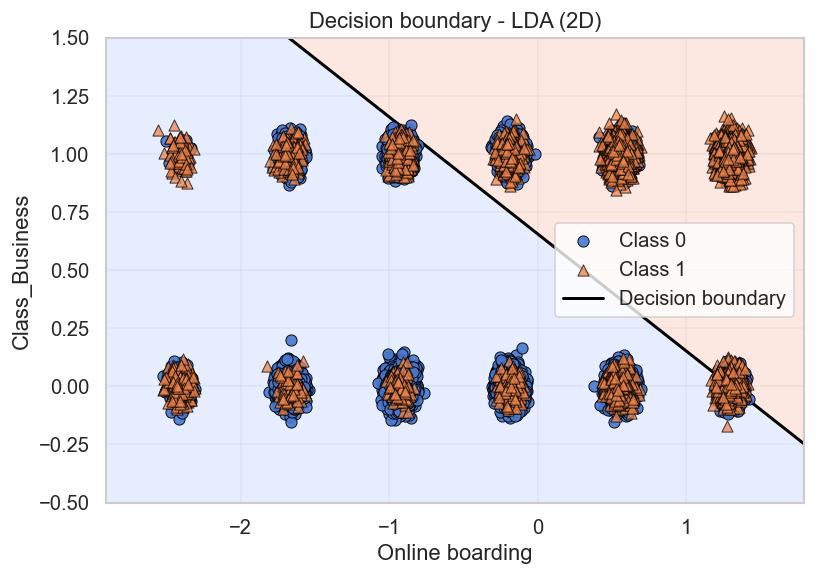

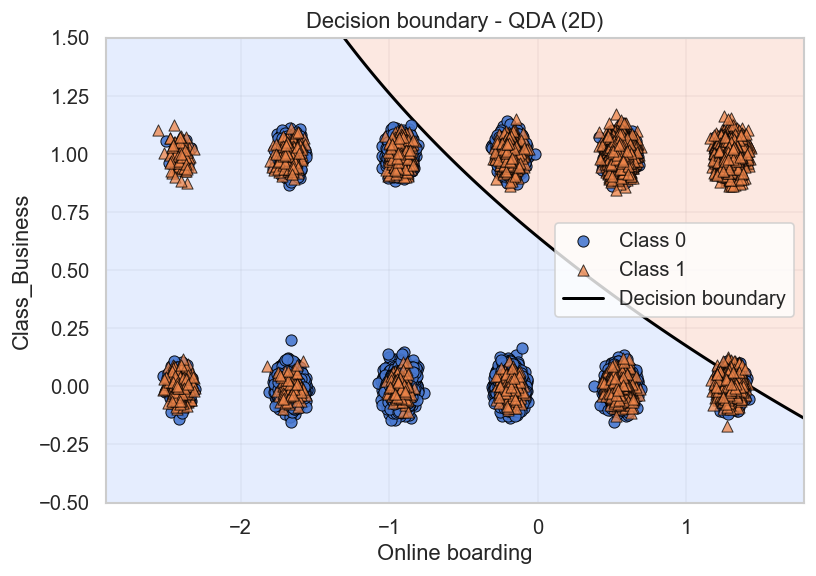

In [31]:
def plot_decision_boundary(model, X, y, title, feature_names, threshold=0.5, jitter=0.04):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)

    classes = np.unique(y)

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    proba = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    zz = (proba >= threshold).astype(int)

    plt.figure(figsize=(7, 5))

    # tô nền vùng dự đoán
    plt.contourf(
        xx, yy, zz,
        levels=[-0.5, 0.5, 1.5],
        alpha=0.22,
        cmap="coolwarm"
    )

    # vẽ đường biên
    plt.contour(
        xx, yy, proba,
        levels=[threshold],
        colors="black",
        linewidths=1.8
    )

    # jitter để tránh các điểm bị chồng lên nhau
    rng = np.random.default_rng(42)
    X_plot = X.copy()
    X_plot[:, 0] += rng.normal(0, jitter, size=X.shape[0])
    X_plot[:, 1] += rng.normal(0, jitter, size=X.shape[0])

    scatter_handles = []

    # vẽ class 0
    sc0 = plt.scatter(
        X_plot[y == 0, 0],
        X_plot[y == 0, 1],
        label="Class 0",
        s=45,
        alpha=0.9,
        marker="o",
        edgecolors="black",
        linewidths=0.6,
        zorder=3
    )
    scatter_handles.append(sc0)

    # vẽ class 1
    sc1 = plt.scatter(
        X_plot[y == 1, 0],
        X_plot[y == 1, 1],
        label="Class 1",
        s=45,
        alpha=0.75,
        marker="^",
        edgecolors="black",
        linewidths=0.6,
        zorder=4
    )
    scatter_handles.append(sc1)

    boundary_handle = Line2D(
        [0], [0],
        color="black",
        lw=1.8,
        label="Decision boundary"
    )

    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(title)
    plt.legend(handles=scatter_handles + [boundary_handle])
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_PATH, f"{title.lower().replace(' ', '_').replace('-', '_').replace('(', '').replace(')', '')}.png"), dpi=300, bbox_inches="tight")
    plt.show()

plot_decision_boundary(
    lda_2d, X_test_2d, y_test,
    "Decision boundary - LDA (2D)", top2_features
)

plot_decision_boundary(
    qda_2d, X_test_2d, y_test,
    "Decision boundary - QDA (2D)", top2_features
)

**Nhận xét**:
- Mặc dù LDA tạo ra một đường biên tuyến tính rõ ràng, nhưng với hai đặc trưng được chọn mô hình chưa phân tách tốt hai lớp. Các điểm dữ liệu chồng lấn tại hầu hết các vùng, nhiều điểm thuộc class 1 nhưng nằm trong vùng dự đoán của class 0 và ngược lại.
- Mô hình QDA cho phép mỗi lớp có ma trận hiệp phương sai riêng, nên đường biên quyết định trở thành đường cong phi tuyến. Nhưng đường biên của QDA cũng không phân loại được chính xác, vẫn bị chồng lấn tương tự với LDA.
- Điều này cho thấy QDA chỉ cải thiện độ linh hoạt Decision Boundary, nhưng không cải thiện hiệu quả phân loại. 
- Từ kết quả trên cho thấy 2 đặc trưng được lựa chọn có ảnh hưởng nhất định đến việc phân biệt lớp, tuy nhiên không đủ mạnh để tách biệt hoàn toàn giữa 2 lớp dữ liệu. Vì thế cần bổ sung thêm các đặc trưng để cải thiện kết quả.

## 3. Đánh giá mô hình

### 3.1 Huấn luyện mô hình trên toàn bộ đặc trưng và đánh giá trên tập test

Đánh giá tổng quan khả năng phân lớp của 2 mô hình với các chỉ số cốt lõi bao gồm: Accuracy, Precision, Recall, F1-score, ROC-AUC, Average Precision (AP), và Log-loss.

- Dù dữ liệu Airline Passenger Satisfaction khá cân bằng, việc kết hợp F1-score và ROC-AUC giúp chúng ta đánh giá chính xác hơn khả năng nhận diện lớp hành khách "Hài lòng" (Satisfied - Class 1) của mô hình.

In [32]:
# Hàm đánh giá classifier với các metric quan trọng
def evaluate_classifier(model, X_train, y_train, X_test, y_test, model_name='Model'):
    start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time = time.perf_counter() - start

    y_pred = model.predict(X_test)
    y_proba_all = model.predict_proba(X_test)

    # xác định lớp dương cho bài toán nhị phân
    classes = np.asarray(model.classes_)
    if len(classes) != 2:
        raise ValueError("Hàm này hiện tại chỉ dùng cho bài toán nhị phân.")

    positive_class = classes[1]
    positive_idx = 1  # vì predict_proba của bạn trả theo đúng thứ tự model.classes_
    y_prob = y_proba_all[:, positive_idx]

    metrics = {
        'model': model_name,
        'positive_class': positive_class,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, pos_label=positive_class, zero_division=0),
        'recall': recall_score(y_test, y_pred, pos_label=positive_class, zero_division=0),
        'f1': f1_score(y_test, y_pred, pos_label=positive_class, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'avg_precision': average_precision_score(y_test == positive_class, y_prob),
        'log_loss': log_loss(y_test, y_proba_all, labels=classes),
        'fit_time_sec': fit_time
    }

    return metrics, y_pred, y_prob, y_proba_all

lda_full = MyLDA(reg=1e-6)
qda_full = MyQDA(reg=1e-4)

lda_metrics, y_pred_lda, y_prob_lda, y_proba_lda_all = evaluate_classifier(
    lda_full, X_train, y_train, X_test, y_test, model_name='MyLDA'
)

qda_metrics, y_pred_qda, y_prob_qda, y_proba_qda_all = evaluate_classifier(
    qda_full, X_train, y_train, X_test, y_test, model_name='MyQDA'
)

test_results_df = pd.DataFrame([lda_metrics, qda_metrics])
display(test_results_df.round(4))

,model,positive_class,accuracy,precision,recall,f1,roc_auc,avg_precision,log_loss,fit_time_sec
0,MyLDA,1,0.8690,0.8646,0.8319,0.8479,0.9252,0.9270,0.3497,0.0421
1,MyQDA,1,0.8534,0.8523,0.8057,0.8283,0.9171,0.9228,0.6506,0.0387


**Nhận xét**:
- Hiệu năng của LDA vượt trội hơn QDA trên mọi mặt.
- Giải thích: Việc LDA hoạt động tốt hơn QDA chứng tỏ phân bố hiệp phương sai của 2 lớp trong không gian 24 chiều là tương đối giống nhau. QDA cố gắng học 2 ma trận hiệp phương sai riêng biệt (tốn nhiều tham số hơn), dẫn đến hiện tượng quá khớp với nhiễu cục bộ và kéo theo hiệu năng giảm tổng quát trên tập test.

### 3.2 Ma trận nhầm lẫn (Confusion Matrix)

Ma trận nhầm lẫn giúp bóc tách cụ thể các lỗi False Positives (Dự đoán là Hài lòng nhưng thực tế Không) và False Negatives (Dự đoán Không hài lòng nhưng thực tế Có).

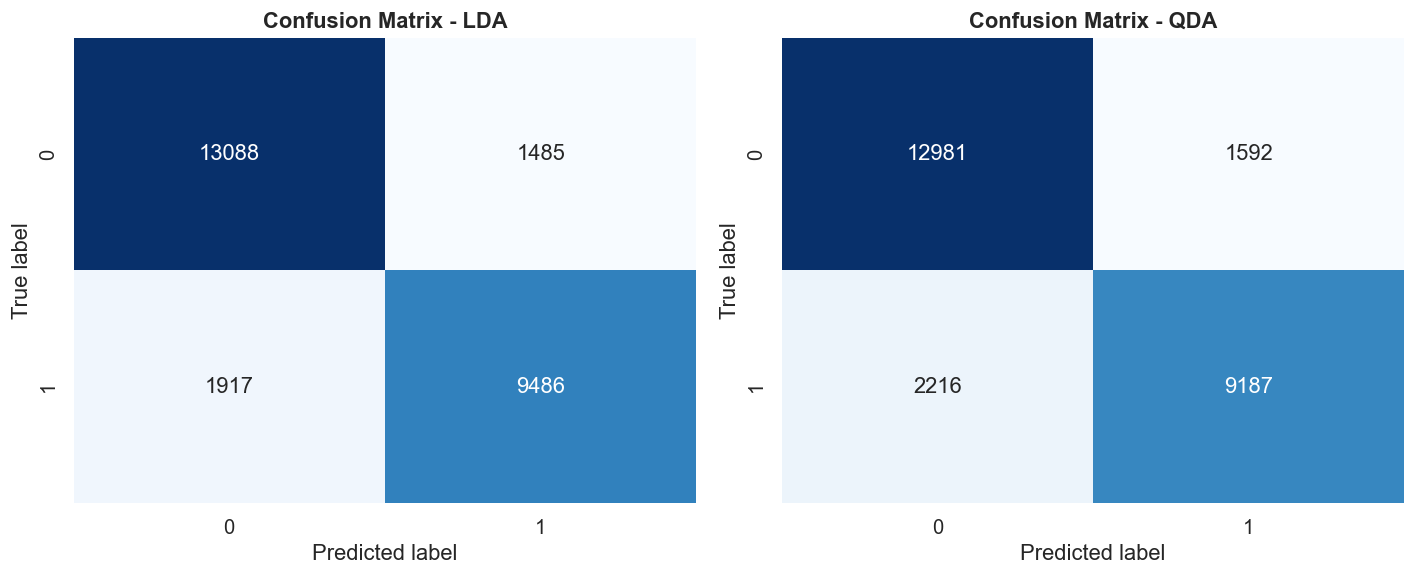

In [33]:
# Vẽ confusion matrix cho LDA và QDA để so sánh lỗi phân loại giữa hai mô hình
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, y_pred) in zip(
    axes,
    [('LDA', y_pred_lda), ('QDA', y_pred_qda)]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=ax
    )
    ax.set_title(f'Confusion Matrix - {name}', fontweight='bold')
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH_2, "confusion_matrix_lda_qda.png"), dpi=300, bbox_inches="tight")
plt.show()


**Nhận xét**: Dựa vào biểu đồ, mô hình LDA có tỉ lệ nhận diện đúng lớp 1 cao hơn đáng kể (tương ứng với ô True Positive ở góc dưới cùng bên phải). QDA mắc lỗi False Negatives hơn, tức là có xu hướng đánh giá nhiều hành khách thực sự hài lòng thành "Không hài lòng".

### 3.3 Đường cong ROC 

Đường cong ROC đo lường sức mạnh xếp hạng phân lớp của mô hình theo các ngưỡng xác suất khác nhau.

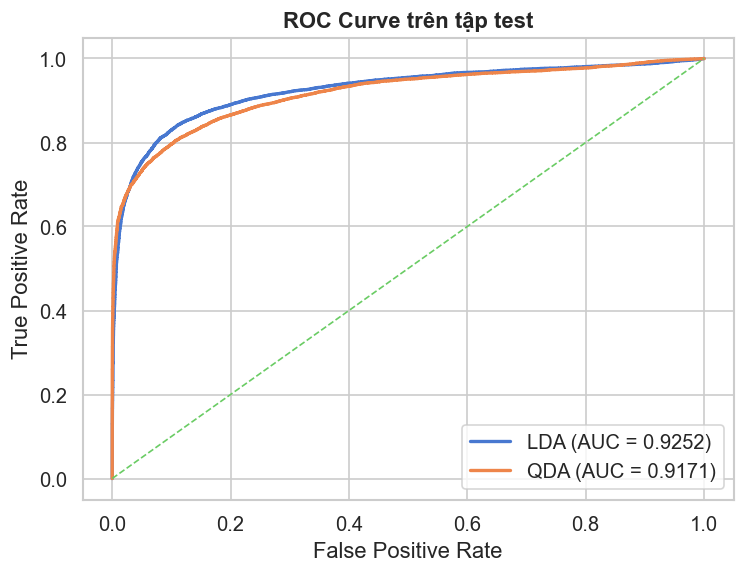

In [34]:
# Vẽ ROC curve + tính AUC để so sánh khả năng phân biệt của LDA và QDA trên tập test
plt.figure(figsize=(7, 5))
for name, y_prob in [('LDA', y_prob_lda), ('QDA', y_prob_qda)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], '--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve trên tập test', fontweight='bold')
plt.legend()
plt.savefig(os.path.join(FIG_PATH_2, "roc_curve_test.png"), dpi=300, bbox_inches="tight")
plt.show()


**Nhận xét**: Cả hai mô hình đều uốn cong về phía góc trên bên trái, thể hiện hiệu năng phân định xuất sắc (AUC > 0.91). Tuy nhiên, đường cong của LDA bao trọn phía trên đường của QDA.

### 3.4 Đánh giá tính ổn định bằng Stratified K-Fold CV (k = 5)
Nhằm khẳng định các kết quả tốt ở trên không phải do "may mắn" lấy mẫu trúng tập Test dễ đoán, ta áp dụng kiểm định chéo K-Fold (với k=5) trên tập Huấn luyện. Phương pháp Stratified được dùng để đảm bảo tỷ lệ các lớp 0 và 1 luôn được duy trì đồng đều trong mỗi fold. Kết quả được báo cáo định dạng mean ± std.

In [35]:
def cross_validate_model(model_class, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    metrics = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': [], 'ROC_AUC': []}

    X_np = X.values if isinstance(X, pd.DataFrame) else X
    y_np = y.values if isinstance(y, pd.Series) else y

    for tr_idx, va_idx in skf.split(X_np, y_np):
        model = model_class().fit(X_np[tr_idx], y_np[tr_idx])
        y_pred = model.predict(X_np[va_idx])
        y_prob = model.predict_proba(X_np[va_idx])[:, 1]

        metrics['Accuracy'].append(accuracy_score(y_np[va_idx], y_pred))
        metrics['Precision'].append(precision_score(y_np[va_idx], y_pred))
        metrics['Recall'].append(recall_score(y_np[va_idx], y_pred))
        metrics['F1'].append(f1_score(y_np[va_idx], y_pred))
        metrics['ROC_AUC'].append(roc_auc_score(y_np[va_idx], y_prob))

    # Báo cáo theo định dạng mean ± std
    res = {}
    for k, v in metrics.items():
        res[k] = f"{np.mean(v):.4f} ± {np.std(v):.4f}"
    return res

cv_results = pd.DataFrame([
    cross_validate_model(MyLDA, X_train, y_train),
    cross_validate_model(MyQDA, X_train, y_train)
], index=['MyLDA', 'MyQDA'])

print("Báo cáo 5-fold cross-validation(mean ± std)")
display(cv_results)


Báo cáo 5-fold cross-validation(mean ± std)


,Accuracy,Precision,Recall,F1,ROC_AUC
MyLDA,0.8719 ± 0.0019,0.8645 ± 0.0029,0.8352 ± 0.0043,0.8496 ± 0.0024,0.9262 ± 0.0015
MyQDA,0.8564 ± 0.0019,0.8552 ± 0.0026,0.8048 ± 0.0036,0.8292 ± 0.0024,0.9197 ± 0.0015


**Nhận xét**: Kết quả K-Fold CV hoàn toàn đồng nhất với hiệu năng trên tập Test. Độ lệch chuẩn (std) của các chỉ số là vô cùng nhỏ (dao động chỉ khoảng ±0.002). Điều này chứng minh thuật toán có tính tổng quát hóa tuyệt vời, không bị Overfitting và không bị ảnh hưởng mạnh bởi sự xáo trộn của dữ liệu huấn luyện. Mô hình LDA tiếp tục thể hiện giá trị trung bình (mean) vượt trội hơn QDA.

### 3.5 Vẽ Precision-Recall Curve và So sánh Average Precision (AP)
Biểu đồ Precision-Recall (PR) Curve kết hợp cùng chỉ số Average Precision (AP) sẽ giúp ta đánh giá chính xác hơn về khả năng vừa xác định được được khách hàng hài lòng (Recall cao) vừa đảm bảo sự phán đoán đó không bị sai lệch (Precision cao).

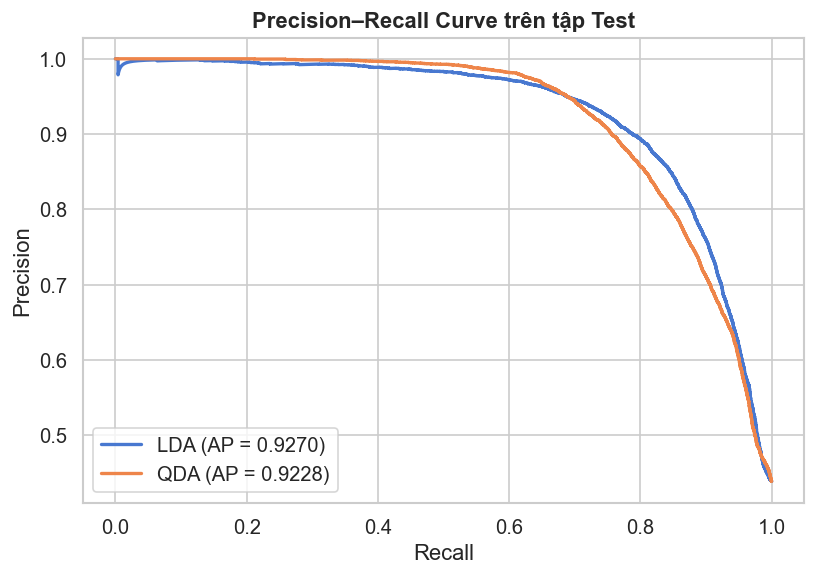

In [36]:
plt.figure(figsize=(7, 5))

for name, y_prob in [('LDA', y_prob_lda), ('QDA', y_prob_qda)]:
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, linewidth=2, label=f'{name} (AP = {ap:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve trên tập Test', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "precision_recall_curve_test.png"), dpi=300, bbox_inches="tight")
plt.show()

**Nhận xét:** Nhìn vào đồ thị PR Curve, khi ta kéo mức Recall lên cao (tức là khi mô hình cố gắng bắt bằng được mọi hành khách hài lòng), Precision của QDA bị suy giảm mạnh mẽ hơn so với LDA. Chỉ số Average Precision (đo lường diện tích dưới đường PR) của LDA đạt 0.9270, cao hơn QDA (0.9228). Qua đó, hệ thống chấm điểm rủi ro của LDA đáng tin cậy hơn hẳn QDA.

### 3.6 Kiểm định ý nghĩa thống kê (McNemar's Test)

Ta nhận thấy LDA luôn cao điểm hơn QDA, nhưng liệu sự chênh lệch (khoảng 1.5% Accuracy) này là bản chất toán học hay chỉ là yếu tố ngẫu nhiên? Kiểm định McNemar trên cùng một tập Test sẽ tập trung đo lường những mẫu dữ liệu mà mô hình A đoán đúng còn mô hình B đoán sai để đưa ra kết luận thống kê.

In [37]:
def mcnemar_test(y_true, pred_a, pred_b):
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)

    b = np.sum(correct_a & ~correct_b)  # LDA đúng, QDA sai
    c = np.sum(~correct_a & correct_b)  # LDA sai, QDA đúng

    # Xấp xỉ Chi-square
    stat = (abs(b - c) - 1) ** 2 / (b + c) if (b + c) > 0 else 0.0
    # Tính P-value chính xác
    p_value = binomtest(min(b, c), n=b + c, p=0.5, alternative='two-sided').pvalue if (b + c) > 0 else 1.0

    return {
        'LDA_correct_QDA_wrong (b)': int(b),
        'LDA_wrong_QDA_correct (c)': int(c),
        'Chi_square': stat,
        'P-value': p_value
    }

mcnemar_result = pd.DataFrame([mcnemar_test(y_test, y_pred_lda, y_pred_qda)])
print("Kết quả McNemar's test giữa LDA và QDA trên tập test:")
display(mcnemar_result.round(6))

Kết quả McNemar's test giữa LDA và QDA trên tập test:


,LDA_correct_QDA_wrong (b),LDA_wrong_QDA_correct (c),Chi_square,P-value
0,1179,773,84.029201,0.0


**Nhận xét**: Bảng kết quả cho thấy có 1179 mẫu hành khách mà LDA đoán đúng nhưng QDA đoán sai, trong khi QDA chỉ gỡ lại được 773 mẫu. Giá trị P-value = 0.0 (< 0.05). Theo nguyên lý thống kê, ta hoàn toàn có đủ bằng chứng để bác bỏ giả thuyết không (Null Hypothesis). Ta tự tin kết luận rằng sự chênh lệch hiệu năng giữa LDA và QDA không phải do ngẫu nhiên, mà là có ý nghĩa thống kê. Mô hình LDA hoàn toàn ưu việt hơn trong bài toán này.

### 3.7 Phân tích Calibration bằng Reliability Diagram (Biểu đồ độ tin cậy)

Xác suất đầu ra (Predicted Probability) không phải lúc nào cũng phản ánh đúng thực tế. Ví dụ, nếu mô hình báo "80% khách hàng này hài lòng", thì trong thực tế liệu có đúng 80% số khách hàng có cùng mức điểm đó cảm thấy hài lòng không? Biểu đồ độ tin cậy sẽ đối chiếu mức xác suất mô hình in ra với tỷ lệ thực tế.

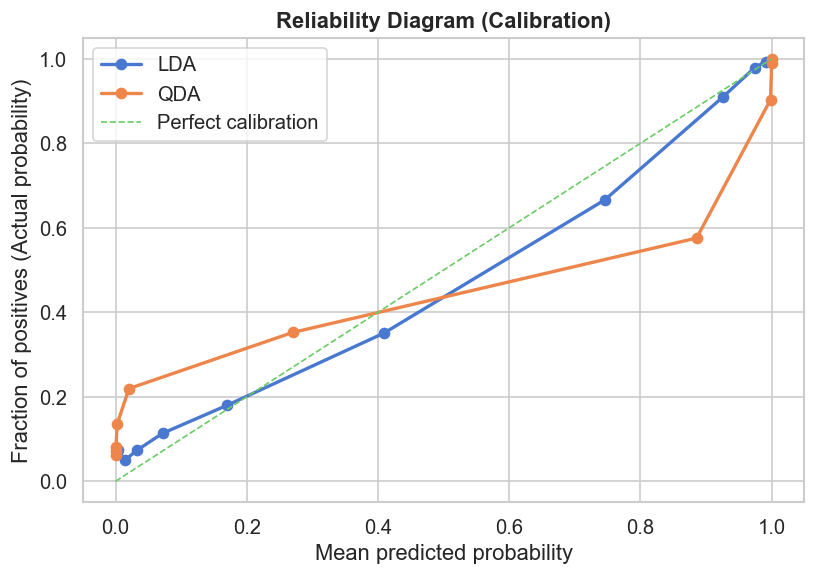

Log-loss LDA: 0.3497
Log-loss QDA: 0.6506


In [38]:
plt.figure(figsize=(7, 5))

for name, y_prob in [('LDA', y_prob_lda), ('QDA', y_prob_qda)]:
    # Chia dữ liệu thành 10 bins phân vị
    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy='quantile')
    plt.plot(mean_pred, frac_pos, marker='o', linewidth=2, label=name)

# Đường chéo lý tưởng (Perfect calibration)
plt.plot([0, 1], [0, 1], '--', linewidth=1, label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives (Actual probability)')
plt.title('Reliability Diagram (Calibration)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "reliability_diagram_test.png"), dpi=300, bbox_inches="tight")
plt.show()

# Tính Log-loss để củng cố phân tích
print(f"Log-loss LDA: {log_loss(y_test, lda_full.predict_proba(X_test)):.4f}")
print(f"Log-loss QDA: {log_loss(y_test, qda_full.predict_proba(X_test)):.4f}")

**Nhận xét:** 
- LDA cực kỳ đáng tin cậy: Đường cong của LDA bám rất sát đường chéo lý tưởng (Perfect Calibration). Xác suất mà LDA dự đoán hoàn toàn đồng nhất với xác suất thực tế.
- QDA thì quá tự tin (overconfident): Đường cong của QDA bị gãy khúc, tạo thành dạng chữ "S ngược", có xu hướng đẩy các giá trị xác suất về sát hai cực 0.0 và 1.0 một cách thái quá. Nguyên nhân là do QDA nhân các ma trận nghịch đảo $\Sigma_k^{-1}$ riêng biệt, khiến biên quyết định bị uốn cong lố. Sự "tự tin thái quá" này khiến QDA bị phạt rất nặng ở hàm mất mát Log-loss (0.6506), cao gần gấp đôi so với Log-loss ổn định của LDA (0.3497).

## 4. So sánh LDA và QDA

### 4.1 Phân tích độ phức tạp của không gian tham số (Parameter Complexity)
Sự khác biệt cốt lõi về mặt toán học giữa LDA và QDA nằm ở giả định về ma trận hiệp phương sai. Với không gian dữ liệu $d = 24$ chiều và $K = 2$ lớp, số lượng tham số mà mỗi mô hình cần học từ tập huấn luyện được tính toán như sau:

- **LDA** (Giả thiết hiệp phương sai chung): 
  - **Vector trung bình**: $ K \times d = 48 $ tham số
  - **Ma trận hiệp phương sai dùng chung** $ \Sigma $:  
  $ \dfrac{d(d+1)}{2} = \dfrac{24 \times 25}{2} = 300 $ tham số
  - **Xác suất tiên nghiệm (Prior)**: $ K - 1 = 1 $ tham số

  - **Tổng cộng: $ 48 + 300 + 1 = 349 $ tham số**

- **QDA** (Giả thiết hiệp phương sai riêng biệt):
  - **Vector trung bình**: $ 48 $ tham số
  - **Ma trận hiệp phương sai riêng cho từng lớp** $ \Sigma_k $:  
  $ K \times \dfrac{d(d+1)}{2} = 2 \times 300 = 600 $ tham số
  - **Xác suất tiên nghiệm (Prior)**: $ 1 $ tham số

  - **Tổng cộng: $ 48 + 600 + 1 = 649 $ tham số**

In [39]:

# So sánh độ phức tạp tham số và độ giống nhau giữa các covariance matrix

classes = np.unique(y_train)
d = X_train.shape[1]
K = len(classes)

# số phần tử độc lập trong ma trận hiệp phương sai đối xứng
n_cov_params = d * (d + 1) // 2

complexity_df = pd.DataFrame([
    {
        'model': 'LDA',
        'mean_params': K * d,
        'covariance_params': n_cov_params,
        'prior_params': K - 1,
        'total_params': K * d + n_cov_params + (K - 1)
    },
    {
        'model': 'QDA',
        'mean_params': K * d,
        'covariance_params': K * n_cov_params,
        'prior_params': K - 1,
        'total_params': K * d + K * n_cov_params + (K - 1)
    }
])
print('Bảng số tham số cần ước lượng:')
display(complexity_df)

Bảng số tham số cần ước lượng:


,model,mean_params,covariance_params,prior_params,total_params
0,LDA,48,300,1,349
1,QDA,48,600,1,649


**Nhận xét:**  
QDA yêu cầu số lượng tham số cần ước lượng gần **gấp đôi** so với LDA (**649 so với 349 tham số**). Trong không gian nhiều chiều, việc phải ước lượng một lượng lớn tham số độc lập cho các ma trận hiệp phương sai riêng $\Sigma_k$ giúp QDA linh hoạt hơn, nhưng đồng thời cũng khiến mô hình **dễ bị quá khớp (overfitting)** với nhiễu dữ liệu.

Ngược lại, việc LDA buộc cả hai lớp dùng chung một cấu trúc hiệp phương sai $\Sigma$ hoạt động như một dạng **regularization tự nhiên**, giúp mô hình ổn định hơn và thường tổng quát hóa tốt hơn khi dữ liệu không đủ lớn.

### 4.2. Đánh giá mức độ tương đồng của ma trận hiệp phương sai giữa hai lớp

Để kiểm chứng xem giả thiết **“dùng chung ma trận hiệp phương sai”** của LDA có thực sự hợp lý với bộ dữ liệu *Airline Passenger Satisfaction* hay không, nhóm đã trực tiếp đo lường sự khác biệt giữa $\Sigma_0$ (lớp **Neutral/Dissatisfied**) và $\Sigma_1$ (lớp **Satisfied**) trên tập huấn luyện.

In [40]:
cov0 = params[classes[0]]['Sigma']
cov1 = params[classes[1]]['Sigma']
triu_idx = np.triu_indices_from(cov0)
cov_similarity_df = pd.DataFrame([{
    'frobenius_norm_diff': np.linalg.norm(cov0 - cov1, ord='fro'),
    'relative_frobenius_diff': np.linalg.norm(cov0 - cov1, ord='fro') /
        ((np.linalg.norm(cov0, ord='fro') + np.linalg.norm(cov1, ord='fro')) / 2),
    'upper_triangle_correlation': np.corrcoef(cov0[triu_idx], cov1[triu_idx])[0, 1],
    'diagonal_variance_correlation': np.corrcoef(np.diag(cov0), np.diag(cov1))[0, 1]
}])

print('Mức độ giống nhau giữa hai covariance matrix của hai lớp:')
display(cov_similarity_df.round(4))


Mức độ giống nhau giữa hai covariance matrix của hai lớp:


,frobenius_norm_diff,relative_frobenius_diff,upper_triangle_correlation,diagonal_variance_correlation
0,3.4298,0.6235,0.8259,0.6566


**Nhận xét:**

- **Độ tương quan rất cao**: Hệ số tương quan của phần tam giác trên (*upper triangle*) giữa hai ma trận đạt **0.8259**, trong khi tương quan phương sai trên đường chéo chính đạt **0.6566**. Điều này chứng tỏ hình dáng phân bố và cấu trúc tương quan giữa các đặc trưng của khách hàng Hài lòng và Không hài lòng là rất giống nhau.

- **Vì sao LDA phù hợp hơn**: Khi hai lớp đã có cấu trúc hiệp phương sai tương đồng, việc QDA cố gắng học hai ma trận riêng biệt trở nên **thừa mức cần thiết**, và có nguy cơ học theo các dao động nhiễu cục bộ trong dữ liệu. Trong bối cảnh đó, giả thiết của LDA là **hợp lý hơn** và giúp mô hình hoạt động ổn định hơn trên tập kiểm tra.


### 4.3. Phân tích đồ thị tương quan phương sai (Variance Correlation Analysis)

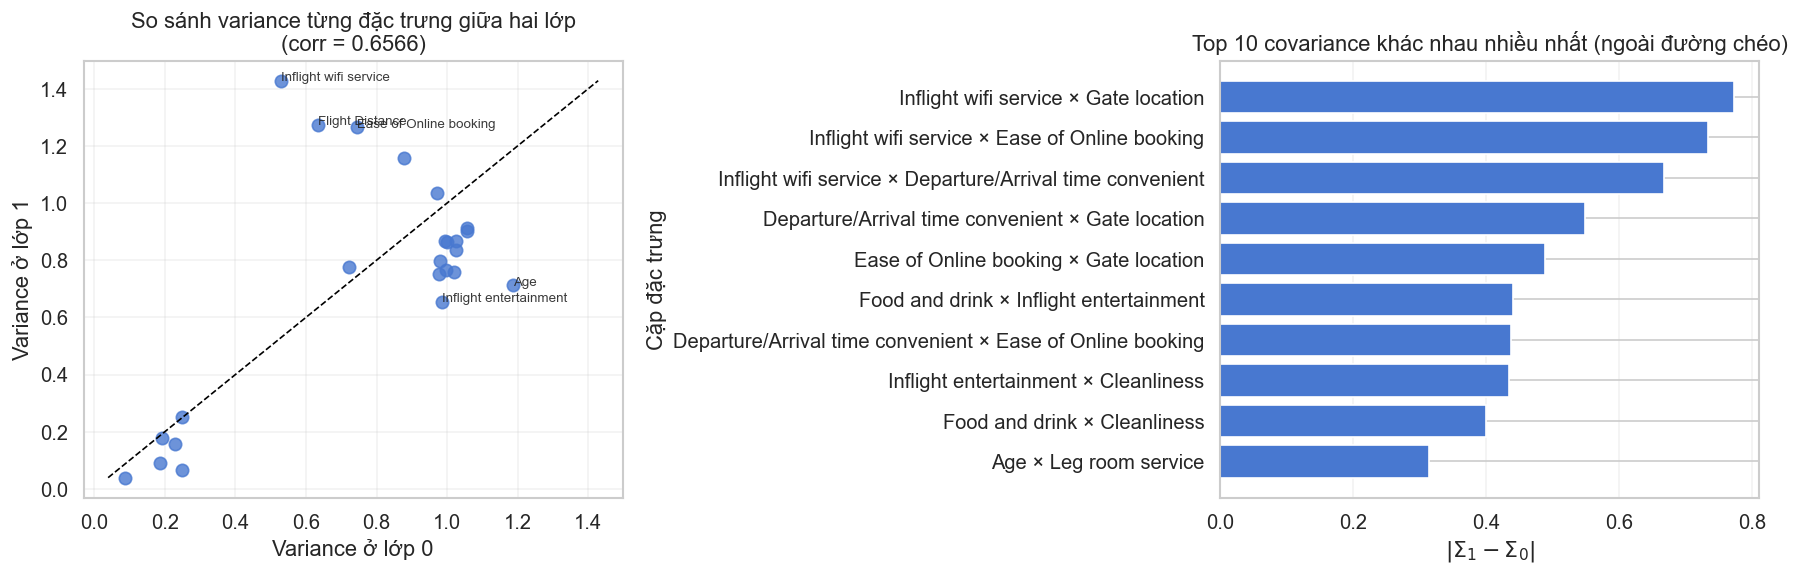

In [41]:

diag_var_diff = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'var_class_0': np.diag(cov0),
    'var_class_1': np.diag(cov1)
})
diag_var_diff['abs_diff'] = np.abs(
    diag_var_diff['var_class_1'] - diag_var_diff['var_class_0']
)

# Phân tích covariance ngoài đường chéo
triu_idx_offdiag = np.triu_indices_from(cov0, k=1)

pairs = []
for i, j in zip(*triu_idx_offdiag):
    pair_name = f'{FEATURE_NAMES[i]} × {FEATURE_NAMES[j]}'
    pairs.append((pair_name, np.abs(cov0[i, j] - cov1[i, j])))

top_cov_diff = (
    pd.DataFrame(pairs, columns=['pair', 'abs_cov_diff'])
    .sort_values('abs_cov_diff', ascending=False)
    .head(10)
    .sort_values('abs_cov_diff', ascending=True)
)

diag_corr = np.corrcoef(
    diag_var_diff['var_class_0'],
    diag_var_diff['var_class_1']
)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x_diag = diag_var_diff['var_class_0'].values
y_diag = diag_var_diff['var_class_1'].values

axes[0].scatter(x_diag, y_diag, s=55, alpha=0.8)

lim_min = min(x_diag.min(), y_diag.min())
lim_max = max(x_diag.max(), y_diag.max())
axes[0].plot([lim_min, lim_max], [lim_min, lim_max], '--', color='black', linewidth=1)

for _, row in diag_var_diff.nlargest(5, 'abs_diff').iterrows():
    axes[0].annotate(
        row['feature'],
        (row['var_class_0'], row['var_class_1']),
        fontsize=8,
        alpha=0.9
    )

axes[0].set_title(f'So sánh variance từng đặc trưng giữa hai lớp\n(corr = {diag_corr:.4f})')
axes[0].set_xlabel('Variance ở lớp 0')
axes[0].set_ylabel('Variance ở lớp 1')
axes[0].grid(alpha=0.25)

# --- Bar chart top covariance khác nhau nhiều nhất ---
axes[1].barh(top_cov_diff['pair'], top_cov_diff['abs_cov_diff'])
axes[1].set_title('Top 10 covariance khác nhau nhiều nhất (ngoài đường chéo)')
axes[1].set_xlabel(r'$|\Sigma_1 - \Sigma_0|$')
axes[1].set_ylabel('Cặp đặc trưng')
axes[1].grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "variance_correlation_analysis.png"), dpi=300, bbox_inches="tight")
plt.show()

**Nhận xét đồ thị:**
- **Biểu đồ scatter:** Các điểm dữ liệu phân bố tập trung khá sát quanh đường chéo lý tưởng $y = x $. Điều này cho thấy **phương sai của từng đặc trưng đơn lẻ** ở hai lớp là **xấp xỉ nhau**, tức mức độ phân tán của dữ liệu theo từng biến không khác biệt nhiều giữa hai nhóm.

- **Biểu đồ cột (bar chart):** Dù có mức độ tương đồng tổng thể cao, vẫn tồn tại một số cặp biến có độ chênh covariance đáng chú ý, (chẳng hạn các tương tác liên quan đến  Inflight wifi service hay Class_Business). Tuy nhiên, những khác biệt cục bộ này **không đủ mạnh** để buộc mô hình phải dùng đến **đường biên quyết định bậc hai** như QDA. Nói cách khác, lợi ích từ độ linh hoạt bổ sung của QDA là **không đủ lớn** để bù lại chi phí tăng số tham số và rủi ro overfitting.


### 4.4. Tổng kết: Khi nào nên sử dụng LDA thay vì QDA?

Từ cả nền tảng lý thuyết lẫn kết quả thực nghiệm, ta rút ra một số kết luận như sau

**Nên chọn LDA khi**

- **Ma trận hiệp phương sai giữa các lớp tương đồng nhau:** Như đã chứng minh ở trên, hệ số tương quan giữa hai ma trận hiệp phương sai đạt mức cao (**0.8259**), cho thấy giả thiết của LDA là phù hợp.

- **Cần một mô hình ổn định, ít tham số hơn:** Với chỉ **349 tham số**, LDA ít bị ảnh hưởng bởi nhiễu hơn và phù hợp hơn trong bối cảnh số chiều khá lớn.

- **Muốn xác suất đầu ra đáng tin cậy hơn:** Việc dùng một ma trận hiệp phương sai chung giúp LDA tránh được hiện tượng dự đoán xác suất quá cực đoan, nhờ đó thường cho **log-loss tốt hơn** và calibration ổn định hơn.

**Chỉ nên chọn QDA khi**

- **Phân bố giữa các lớp thực sự khác nhau rõ rệt:** Tức là các ma trận hiệp phương sai $ \Sigma_k $ khác nhau đáng kể, làm cho đường biên bậc hai trở nên cần thiết.

- **Có rất nhiều dữ liệu huấn luyện so với số chiều đặc trưng:** Vì QDA phải ước lượng số lượng tham số cỡ $ O(Kd^2) $, nên nếu dữ liệu không đủ lớn, mô hình rất dễ học sai cấu trúc phương sai thật.

**Kết luận chung:** Trong bộ dữ liệu này, cả phân tích lý thuyết lẫn thực nghiệm đều cho thấy **LDA là lựa chọn phù hợp hơn QDA**. Lý do chính là:

1. Số tham số của LDA nhỏ hơn đáng kể
2. Cấu trúc hiệp phương sai giữa hai lớp có mức tương đồng cao
3. QDA không thu được lợi ích rõ rệt từ độ linh hoạt bổ sung
4. Trong khi LDA cho mô hình ổn định, dễ tổng quát hóa và đáng tin cậy hơn về mặt xác suất đầu ra.

In [42]:
## 5. Lưu kết quả

In [43]:
os.makedirs(PROC_DATA_PATH, exist_ok=True)

save_models = {
    "LDA": {
        "model": lda_full,
        "model_name": "MyLDA",
        "metrics": lda_metrics,
        "y_pred": y_pred_lda,
        "y_prob": y_prob_lda
    },
    "QDA": {
        "model": qda_full,
        "model_name": "MyQDA",
        "metrics": qda_metrics,
        "y_pred": y_pred_qda,
        "y_prob": y_prob_qda
    }
}

MODEL_PATH = os.path.join(PROC_DATA_PATH, "lda_qda_models.pkl")

with open(MODEL_PATH, "wb") as f:
    pickle.dump(save_models, f)

print(f"Đã lưu model tại: {MODEL_PATH}")

Đã lưu model tại: d:\HOCTAP\Machine-Learning---Project-1-\data\processed\lda_qda_models.pkl


# **Part 3: Perceptron & Logistic Regression có Regularization**

# Hàm đánh giá chung

Phần này định nghĩa một hàm tiện ích để đánh giá mô hình bằng các chỉ số:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Đối với Logistic Regression, notebook còn báo cáo thêm:
- ROC-AUC
- Average Precision (AP)

In [44]:
def evaluate_classification(y_true, y_pred, y_proba=None, model_name="Model"):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)

    print(f"\n===== {model_name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))
    print("Confusion Matrix:")
    print(cm)

    result = {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }

    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
        ap = average_precision_score(y_true, y_proba)
        brier = brier_score_loss(y_true, y_proba)

        print(f"ROC-AUC  : {auc:.4f}")
        print(f"AP       : {ap:.4f}")
        print(f"Brier    : {brier:.4f}")

        result["roc_auc"] = auc
        result["ap"] = ap
        result["brier"] = brier

    return result

# A - PERCEPTRON

## 1. Cơ sở lý thuyết
Perceptron là một thuật toán phân loại tuyến tính đơn giản, hoạt động dựa trên: $$ y = sign(w^T x + b) $$
Thuật toán cập nhật trọng số khi dự đoán sai: $$ w = w + \eta \cdot y_i \cdot x_i $$
Trong đó:
- $ \eta $: learning rate
- $ y_i \in \{-1, +1\} $

Theo định lý hội tụ Perceptron:
- nếu dữ liệu **phân chia tuyến tính**, thuật toán sẽ hội tụ sau hữu hạn bước
- nếu dữ liệu **không phân chia tuyến tính**, số lỗi không thể giảm về 0 hoàn toàn

## 2. Cài đặt Perceptron từ đầu

In [45]:
class PerceptronScratch:
    def __init__(self, lr=0.01, n_iters=100, shuffle=True, random_state=42):
        self.lr = lr
        self.n_iters = n_iters
        self.shuffle = shuffle
        self.random_state = random_state
        self.w = None
        self.b = None
        self.errors_per_epoch = []

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        n_samples, n_features = X.shape

        self.w = np.zeros(n_features, dtype=float)
        self.b = 0.0
        self.errors_per_epoch = []

        y_signed = np.where(y == 1, 1, -1)

        for epoch in range(self.n_iters):
            errors = 0
            indices = np.arange(n_samples)

            if self.shuffle:
                rng.shuffle(indices)

            for i in indices:
                xi = X[i]
                yi = y_signed[i]

                activation = np.dot(xi, self.w) + self.b
                pred = 1 if activation >= 0 else -1

                if pred != yi:
                    self.w += self.lr * yi * xi
                    self.b += self.lr * yi
                    errors += 1

            self.errors_per_epoch.append(errors)
            
            if errors == 0:
                print(f"Thuật toán hội tụ tại epoch {epoch+1} (0 lỗi phân loại).")
                break

        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return (self.decision_function(X) >= 0).astype(int)

## 3. Thực nghiệm kiểm chứng hội tụ của Perceptron

Để minh họa trực quan định lý hội tụ, ta thử Perceptron trên:
1. Dữ liệu phân chia tuyến tính
2. Dữ liệu không phân chia tuyến tính

### 3.1. Dữ liệu phân chia tuyến tính

In [46]:
X_lin, y_lin = make_classification(
    n_samples=400,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=2.5,
    flip_y=0.0,
    random_state=SEED
)

perc_lin = PerceptronScratch(lr=0.01, n_iters=200, shuffle=True, random_state=SEED)
perc_lin.fit(X_lin, y_lin)
y_lin_pred = perc_lin.predict(X_lin)

lin_result = evaluate_classification(y_lin, y_lin_pred, model_name="Perceptron - Dữ liệu tuyến tính")

Thuật toán hội tụ tại epoch 120 (0 lỗi phân loại).

===== Perceptron - Dữ liệu tuyến tính =====
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       200
           1     1.0000    1.0000    1.0000       200

    accuracy                         1.0000       400
   macro avg     1.0000    1.0000    1.0000       400
weighted avg     1.0000    1.0000    1.0000       400

Confusion Matrix:
[[200   0]
 [  0 200]]


### 3.2. Dữ liệu không phân chia tuyến tính

In [47]:
X_moon, y_moon = make_moons(n_samples=400, noise=0.2, random_state=SEED)

perc_moon = PerceptronScratch(lr=0.01, n_iters=200, shuffle=True, random_state=SEED)
perc_moon.fit(X_moon, y_moon)
y_moon_pred = perc_moon.predict(X_moon)

moon_result = evaluate_classification(y_moon, y_moon_pred, model_name="Perceptron - Dữ liệu phi tuyến")


===== Perceptron - Dữ liệu phi tuyến =====
Accuracy : 0.8000
Precision: 0.8191
Recall   : 0.7700
F1-score : 0.7938

Classification Report:
              precision    recall  f1-score   support

           0     0.7830    0.8300    0.8058       200
           1     0.8191    0.7700    0.7938       200

    accuracy                         0.8000       400
   macro avg     0.8011    0.8000    0.7998       400
weighted avg     0.8011    0.8000    0.7998       400

Confusion Matrix:
[[166  34]
 [ 46 154]]


## 4. Trực quan hóa Perceptron

### 4.1. Biểu đồ hội tụ

Đồ thị dưới đây thể hiện số mẫu phân loại sai theo từng vòng lặp, giúp quan sát quá trình hội tụ của Perceptron.

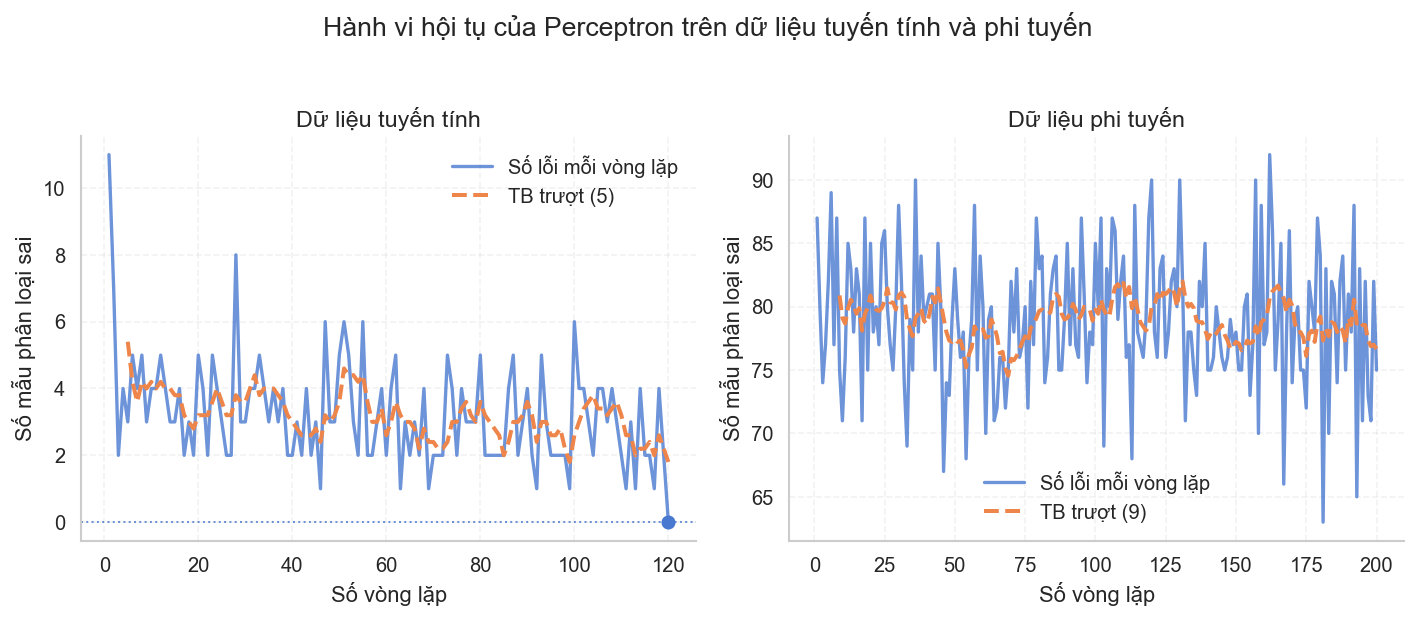

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Dữ liệu tuyến tính
epochs_lin = np.arange(1, len(perc_lin.errors_per_epoch) + 1)
axes[0].plot(epochs_lin, perc_lin.errors_per_epoch, linewidth=2, alpha=0.8, label="Số lỗi mỗi vòng lặp")
if len(perc_lin.errors_per_epoch) >= 5:
    smooth_lin = np.convolve(perc_lin.errors_per_epoch, np.ones(5)/5, mode="valid")
    axes[0].plot(np.arange(5, len(perc_lin.errors_per_epoch)+1), smooth_lin,
                 linewidth=2.4, linestyle="--", label="TB trượt (5)")
if perc_lin.errors_per_epoch[-1] == 0:
    axes[0].axhline(0, linestyle=":", linewidth=1.2, alpha=0.8)
    axes[0].scatter(epochs_lin[-1], 0, s=55, zorder=5)
axes[0].set_title("Dữ liệu tuyến tính", fontsize=14)
axes[0].set_xlabel("Số vòng lặp")
axes[0].set_ylabel("Số mẫu phân loại sai")
axes[0].grid(True, linestyle="--", alpha=0.25)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].legend(frameon=False)

# Dữ liệu phi tuyến
epochs_moon = np.arange(1, len(perc_moon.errors_per_epoch) + 1)
axes[1].plot(epochs_moon, perc_moon.errors_per_epoch, linewidth=2, alpha=0.8, label="Số lỗi mỗi vòng lặp")
if len(perc_moon.errors_per_epoch) >= 9:
    smooth_moon = np.convolve(perc_moon.errors_per_epoch, np.ones(9)/9, mode="valid")
    axes[1].plot(np.arange(9, len(perc_moon.errors_per_epoch)+1), smooth_moon,
                 linewidth=2.4, linestyle="--", label="TB trượt (9)")
axes[1].set_title("Dữ liệu phi tuyến", fontsize=14)
axes[1].set_xlabel("Số vòng lặp")
axes[1].set_ylabel("Số mẫu phân loại sai")
axes[1].grid(True, linestyle="--", alpha=0.25)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].legend(frameon=False)

plt.suptitle("Hành vi hội tụ của Perceptron trên dữ liệu tuyến tính và phi tuyến", fontsize=16, y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH_3, "perceptron_convergence.png"), dpi=300, bbox_inches="tight")
plt.show()

### 4.2. Đường biên quyết định
Đường biên quyết định của Perceptron được xác định bởi phương trình:
$$ w^T x + b = 0 $$

Trên dữ liệu tuyến tính, mô hình có thể phân tách hoàn toàn hai lớp. 
Tuy nhiên, với dữ liệu phi tuyến, do đường biên luôn là tuyến tính, Perceptron không thể phân loại chính xác toàn bộ dữ liệu.

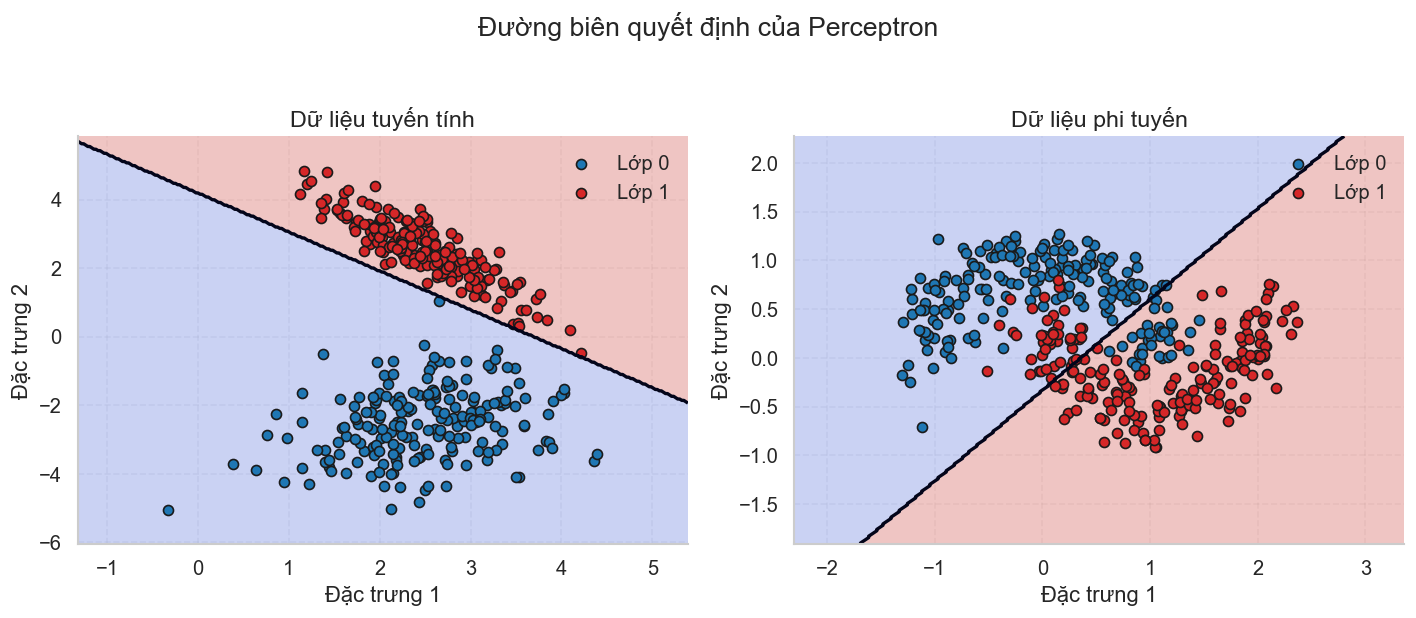

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, X, y, title in [
    (axes[0], perc_lin, X_lin, y_lin, "Dữ liệu tuyến tính"),
    (axes[1], perc_moon, X_moon, y_moon, "Dữ liệu phi tuyến")
]:
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap="coolwarm", alpha=0.3)
    ax.contour(xx, yy, Z, levels=[0.5], linewidths=2)

    ax.scatter(X[y == 0, 0], X[y == 0, 1], color="#1f77b4", label="Lớp 0", edgecolors="k")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], color="#d62728", label="Lớp 1", edgecolors="k")

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Đặc trưng 1")
    ax.set_ylabel("Đặc trưng 2")
    ax.grid(True, linestyle="--", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False)

plt.suptitle("Đường biên quyết định của Perceptron", fontsize=16, y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH_3, "perceptron_decision_boundary.png"), dpi=300, bbox_inches="tight")
plt.show()

## 5. Phân tích và nhận xét

In [50]:
print("=== KẾT QUẢ THỰC NGHIỆM ===")
print(f"Số lỗi cuối cùng trên dữ liệu tuyến tính : {perc_lin.errors_per_epoch[-1]}")
print(f"Số lỗi cuối cùng trên dữ liệu phi tuyến  : {perc_moon.errors_per_epoch[-1]}")

=== KẾT QUẢ THỰC NGHIỆM ===
Số lỗi cuối cùng trên dữ liệu tuyến tính : 0
Số lỗi cuối cùng trên dữ liệu phi tuyến  : 75


**Nhận xét:**  
Kết quả thực nghiệm cho thấy Perceptron có hành vi khác nhau trên hai loại dữ liệu:
- **Dữ liệu phân chia tuyến tính:**  
  Số lỗi giảm dần và đạt giá trị 0. Điều này cho thấy Perceptron đã **hội tụ**, phù hợp với định lý hội tụ: nếu dữ liệu có thể phân chia tuyến tính, thuật toán sẽ tìm được siêu phẳng phân chia sau hữu hạn bước.

- **Dữ liệu không phân chia tuyến tính:**  
  Số lỗi không thể giảm về 0 mà dao động quanh một giá trị dương. Điều này cho thấy Perceptron **không thể hội tụ hoàn toàn** trên dữ liệu phi tuyến.

**Kết luận:** Perceptron hoạt động hiệu quả với dữ liệu có thể phân chia tuyến tính, nhưng có giới hạn rõ ràng khi dữ liệu không tuyến tính.

# B - LOGISTIC REGRESSION + L1/L2 + CLASS-WEIGHTED LOSS

## 1. Cơ sở lý thuyết

Logistic Regression là mô hình phân lớp xác suất, mô hình hóa trực tiếp:

$
p(y=1|x) = \sigma(w^T x + b)
$

trong đó hàm sigmoid là:

$
\sigma(z) = \frac{1}{1 + e^{-z}}

$ 

Với bài toán nhị phân, loss tiêu chuẩn là cross-entropy:

$
E = -\sum_{n=1}^N \left[ y_n \log \hat{y}_n + (1-y_n)\log(1-\hat{y}_n)\right]
$

Trong bài này, để xử lý mất cân bằng dữ liệu, ta dùng **class-weighted loss**:

$
E = -\sum_{n=1}^N c_{y_n} \left[ y_n \log \hat{y}_n + (1-y_n)\log(1-\hat{y}_n)\right]
$
trong đó \\(c_{y_n}\\) là trọng số của lớp mà mẫu thứ \\(n\\) thuộc về, và các trọng số lớp được xác định theo:

$
c_k \propto \frac{N}{N_k}
$

Ngoài ra, để giảm overfitting, mô hình được regularize theo hai cách:

### L2 regularization
$
E = Loss + \frac{\lambda}{2m}\sum_j w_j^2
$

### L1 regularization
$
E = Loss + \frac{\lambda}{m}\sum_j |w_j|
$

Về mặt lý thuyết:
- L1 giúp tạo sparsity, tức nhiều hệ số về 0
- L2 giúp làm nhỏ trọng số và thường ổn định hơn

## 2. Cài đặt Logistic Regression từ đầu

In [51]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def compute_sample_weights(y, class_weights):
    return np.where(y == 1, class_weights[1], class_weights[0])

def compute_cost(X, y, w, b, lambda_=0.0, reg_type=None, class_weights=None):
    m = X.shape[0]
    z = X @ w + b
    y_hat = sigmoid(z)

    eps = 1e-15
    y_hat = np.clip(y_hat, eps, 1 - eps)

    if class_weights is None:
        sample_weights = np.ones_like(y, dtype=float)
    else:
        sample_weights = compute_sample_weights(y, class_weights)

    data_loss = -np.sum(
        sample_weights * (y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    ) / m

    reg_loss = 0.0
    if reg_type == "l2":
        reg_loss = (lambda_ / (2 * m)) * np.sum(w ** 2)
    elif reg_type == "l1":
        reg_loss = (lambda_ / m) * np.sum(np.abs(w))

    return data_loss + reg_loss

def compute_gradient(X, y, w, b, lambda_=0.0, reg_type=None, class_weights=None):
    m = X.shape[0]
    z = X @ w + b
    y_hat = sigmoid(z)

    if class_weights is None:
        sample_weights = np.ones_like(y, dtype=float)
    else:
        sample_weights = compute_sample_weights(y, class_weights)

    error = y_hat - y

    dw = (X.T @ (sample_weights * error)) / m
    db = np.sum(sample_weights * error) / m

    if reg_type == "l2":
        dw += (lambda_ / m) * w
    elif reg_type == "l1":
        dw += (lambda_ / m) * np.sign(w)

    return dw, db

In [52]:
class LogisticRegressionScratch:
    def __init__(
        self,
        lr=0.01,
        n_iters=1000,
        lambda_=0.0,
        reg_type=None,
        class_weights=None,
        threshold=0.5,
        verbose=False
    ):
        self.lr = lr
        self.n_iters = n_iters
        self.lambda_ = lambda_
        self.reg_type = reg_type
        self.class_weights = class_weights
        self.threshold = threshold
        self.verbose = verbose

        self.w = None
        self.b = None
        self.cost_history = []
        self.train_time_ = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features, dtype=float)
        self.b = 0.0
        self.cost_history = []

        start = time.time()

        for i in range(self.n_iters):
            dw, db = compute_gradient(
                X, y, self.w, self.b,
                lambda_=self.lambda_,
                reg_type=self.reg_type,
                class_weights=self.class_weights
            )

            self.w -= self.lr * dw
            self.b -= self.lr * db

            cost = compute_cost(
                X, y, self.w, self.b,
                lambda_=self.lambda_,
                reg_type=self.reg_type,
                class_weights=self.class_weights
            )
            self.cost_history.append(cost)

            if self.verbose and (i % 100 == 0 or i == self.n_iters - 1):
                print(f"Vòng lặp {i:4d} | Cost = {cost:.6f}")

        self.train_time_ = time.time() - start
        return self

    def predict_proba(self, X):
        return sigmoid(X @ self.w + self.b)

    def predict(self, X):
        return (self.predict_proba(X) >= self.threshold).astype(int)

    def count_nonzero_weights(self, tol=1e-3):
        return np.sum(np.abs(self.w) > tol)

## 3. Chọn $\lambda$ bằng Stratified K-Fold Cross Validation

Để chọn regularization strength \\(\lambda\\), ta dùng **Stratified K-Fold Cross Validation (k = 5)** trên tập train.

Lý do dùng Stratified K-Fold:
- giữ tỷ lệ lớp gần như không đổi ở mỗi fold
- phù hợp với bối cảnh dữ liệu mất cân bằng

Tiêu chí chọn $\lambda$: **mean F1-score** trên validation folds.

In [53]:
def compute_balanced_class_weights(y):
    classes, counts = np.unique(y, return_counts=True)
    n_samples = len(y)
    n_classes = len(classes)
    return {int(c): n_samples / (n_classes * cnt) for c, cnt in zip(classes, counts)}

def stratified_kfold_cv(
    X, y,
    lambdas,
    reg_type="l2",
    lr=0.01,
    n_iters=1000,
    n_splits=5,
    random_state=42
):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows = []

    for lam in lambdas:
        fold_acc = []
        fold_prec = []
        fold_rec = []
        fold_f1 = []

        for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
            X_tr, X_va = X[tr_idx], X[va_idx]
            y_tr, y_va = y[tr_idx], y[va_idx]
            
            fold_weights = compute_balanced_class_weights(y_tr)

            model = LogisticRegressionScratch(
                lr=lr,
                n_iters=n_iters,
                lambda_=lam,
                reg_type=reg_type,
                class_weights=fold_weights,
                threshold=0.5,
                verbose=False
            )

            model.fit(X_tr, y_tr)
            y_va_pred = model.predict(X_va)

            fold_acc.append(accuracy_score(y_va, y_va_pred))
            fold_prec.append(precision_score(y_va, y_va_pred, zero_division=0))
            fold_rec.append(recall_score(y_va, y_va_pred, zero_division=0))
            fold_f1.append(f1_score(y_va, y_va_pred, zero_division=0))

        rows.append({
            "reg_type": reg_type,
            "lambda": lam,
            "mean_accuracy": np.mean(fold_acc),
            "std_accuracy": np.std(fold_acc),
            "mean_precision": np.mean(fold_prec),
            "std_precision": np.std(fold_prec),
            "mean_recall": np.mean(fold_rec),
            "std_recall": np.std(fold_rec),
            "mean_f1": np.mean(fold_f1),
            "std_f1": np.std(fold_f1),
        })

    results_df = pd.DataFrame(rows).sort_values(by="mean_f1", ascending=False).reset_index(drop=True)
    best_lambda = results_df.loc[0, "lambda"]
    return results_df, best_lambda

In [54]:
lambda_grid = [0, 1, 10, 50, 100, 500, 1000]
print("Các giá trị lambda được thử:", lambda_grid)

Các giá trị lambda được thử: [0, 1, 10, 50, 100, 500, 1000]


In [55]:
cv_l2_df, best_lambda_l2 = stratified_kfold_cv(
    X_train, y_train,
    lambdas=lambda_grid,
    reg_type="l2",
    lr=0.05,
    n_iters=800,
    n_splits=5,
    random_state=SEED
)

print("Giá trị lambda tốt nhất cho L2:", best_lambda_l2)
cv_l2_df

Giá trị lambda tốt nhất cho L2: 0


,reg_type,lambda,mean_accuracy,std_accuracy,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1
0,l2,0,0.860465,0.003213,0.834436,0.005622,0.845876,0.003298,0.840104,0.003312
1,l2,1,0.860465,0.003213,0.834436,0.005622,0.845876,0.003298,0.840104,0.003312
2,l2,10,0.860454,0.003261,0.834466,0.005703,0.845800,0.003360,0.840082,0.003365
3,l2,50,0.860388,0.003203,0.834256,0.005586,0.845927,0.003431,0.840038,0.003317
4,l2,100,0.860234,0.003230,0.834080,0.005581,0.845750,0.003536,0.839861,0.003363
5,l2,500,0.859629,0.003266,0.833221,0.005850,0.845318,0.003105,0.839213,0.003311
6,l2,1000,0.858210,0.003314,0.831229,0.005623,0.844252,0.003422,0.837678,0.003441


In [56]:
cv_l1_df, best_lambda_l1 = stratified_kfold_cv(
    X_train, y_train,
    lambdas=lambda_grid,
    reg_type="l1",
    lr=0.05,
    n_iters=800,
    n_splits=5,
    random_state=SEED
)

print("Giá trị lambda tốt nhất cho L1:", best_lambda_l1)
cv_l1_df

Giá trị lambda tốt nhất cho L1: 10


,reg_type,lambda,mean_accuracy,std_accuracy,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1
0,l1,10,0.860542,0.003249,0.834480,0.005594,0.846029,0.003437,0.840202,0.003377
1,l1,0,0.860465,0.003213,0.834436,0.005622,0.845876,0.003298,0.840104,0.003312
2,l1,1,0.860454,0.003219,0.834448,0.005626,0.845826,0.003314,0.840086,0.003321
3,l1,50,0.860366,0.003461,0.834101,0.005968,0.846105,0.003431,0.840046,0.003576
4,l1,100,0.860157,0.003539,0.833904,0.006009,0.845800,0.003415,0.839797,0.003669
5,l1,500,0.858408,0.003334,0.831262,0.005894,0.844785,0.003661,0.837954,0.003431
6,l1,1000,0.854118,0.003285,0.825015,0.005180,0.841968,0.004303,0.833393,0.003550


**Nhận xét:**  
Cross-validation cho thấy các giá trị \\(\lambda\\) nhỏ và vừa cho kết quả khá gần nhau. Điều này gợi ý rằng bài toán hiện tại không quá nhạy với regularization strength, hoặc dữ liệu đã được tiền xử lý khá tốt trước đó.

## 4. Huấn luyện mô hình và tối ưu ngưỡng phân loại trên tập validation

Sau khi chọn được $\lambda$ tốt nhất bằng cross-validation, ta huấn luyện hai mô hình:
- Logistic Regression + L1
- Logistic Regression + L2

trên tập **train**, sau đó dùng tập **validation** để:
1. so sánh hiệu năng giữa các mô hình
2. chọn ngưỡng phân loại tối ưu theo F1-score

Ta cũng huấn luyện thêm một baseline không dùng class weights để đánh giá tác động của weighted loss.

In [57]:
def find_best_threshold(y_true, y_proba):
    thresholds = np.arange(0.1, 0.91, 0.05)
    best_th = 0.5
    best_f1 = -1

    for th in thresholds:
        y_pred = (y_proba >= th).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_th = th

    return best_th, best_f1

In [58]:
logreg_l2 = LogisticRegressionScratch(
    lr=0.05,
    n_iters=1200,
    lambda_=best_lambda_l2,
    reg_type="l2",
    class_weights=CLASS_WEIGHTS,
    threshold=0.5,
    verbose=True
)

logreg_l2.fit(X_train, y_train)
y_val_proba_l2 = logreg_l2.predict_proba(X_val)

best_th_l2, best_f1_l2 = find_best_threshold(y_val, y_val_proba_l2)
y_val_pred_l2 = (y_val_proba_l2 >= best_th_l2).astype(int)

print(f"Ngưỡng tốt nhất cho L2: {best_th_l2:.2f} | F1 tốt nhất: {best_f1_l2:.4f}")

result_l2_val = evaluate_classification(
    y_val, y_val_pred_l2, y_val_proba_l2,
    model_name="Logistic Regression + L2 (Validation)"
)

print()

logreg_l1 = LogisticRegressionScratch(
    lr=0.05,
    n_iters=1200,
    lambda_=best_lambda_l1,
    reg_type="l1",
    class_weights=CLASS_WEIGHTS,
    threshold=0.5,
    verbose=True
)

logreg_l1.fit(X_train, y_train)
logreg_l1.w[np.abs(logreg_l1.w) < 1e-6] = 0
y_val_proba_l1 = logreg_l1.predict_proba(X_val)

best_th_l1, best_f1_l1 = find_best_threshold(y_val, y_val_proba_l1)
y_val_pred_l1 = (y_val_proba_l1 >= best_th_l1).astype(int)

print(f"Ngưỡng tốt nhất cho L1: {best_th_l1:.2f} | F1 tốt nhất: {best_f1_l1:.4f}")

result_l1_val = evaluate_classification(
    y_val, y_val_pred_l1, y_val_proba_l1,
    model_name="Logistic Regression + L1 (Validation)"
)

Vòng lặp    0 | Cost = 0.675098
Vòng lặp  100 | Cost = 0.411539
Vòng lặp  200 | Cost = 0.388466
Vòng lặp  300 | Cost = 0.378698
Vòng lặp  400 | Cost = 0.372826
Vòng lặp  500 | Cost = 0.368673
Vòng lặp  600 | Cost = 0.365475
Vòng lặp  700 | Cost = 0.362887
Vòng lặp  800 | Cost = 0.360723
Vòng lặp  900 | Cost = 0.358872
Vòng lặp 1000 | Cost = 0.357263
Vòng lặp 1100 | Cost = 0.355845
Vòng lặp 1199 | Cost = 0.354595
Ngưỡng tốt nhất cho L2: 0.60 | F1 tốt nhất: 0.8451

===== Logistic Regression + L2 (Validation) =====
Accuracy : 0.8719
Precision: 0.8876
Recall   : 0.8065
F1-score : 0.8451

Classification Report:
              precision    recall  f1-score   support

           0     0.8617    0.9219    0.8908      7360
           1     0.8876    0.8065    0.8451      5628

    accuracy                         0.8719     12988
   macro avg     0.8746    0.8642    0.8679     12988
weighted avg     0.8729    0.8719    0.8710     12988

Confusion Matrix:
[[6785  575]
 [1089 4539]]
ROC-AUC  : 0.9

In [59]:
baseline_l2 = LogisticRegressionScratch(
    lr=0.05,
    n_iters=1200,
    lambda_=best_lambda_l2,
    reg_type="l2",
    class_weights=None,
    threshold=0.5,
    verbose=False
)

baseline_l2.fit(X_train, y_train)
baseline_val_proba = baseline_l2.predict_proba(X_val)

baseline_th, baseline_f1 = find_best_threshold(y_val, baseline_val_proba)
baseline_val_pred = (baseline_val_proba >= baseline_th).astype(int)

print(f"Ngưỡng tốt nhất cho baseline L2: {baseline_th:.2f} | F1 tốt nhất: {baseline_f1:.4f}")

baseline_result = evaluate_classification(
    y_val, baseline_val_pred, baseline_val_proba,
    model_name="Logistic Regression + L2 (Không dùng class weights)"
)

Ngưỡng tốt nhất cho baseline L2: 0.50 | F1 tốt nhất: 0.8452

===== Logistic Regression + L2 (Không dùng class weights) =====
Accuracy : 0.8692
Precision: 0.8675
Recall   : 0.8239
F1-score : 0.8452

Classification Report:
              precision    recall  f1-score   support

           0     0.8703    0.9038    0.8868      7360
           1     0.8675    0.8239    0.8452      5628

    accuracy                         0.8692     12988
   macro avg     0.8689    0.8639    0.8660     12988
weighted avg     0.8691    0.8692    0.8687     12988

Confusion Matrix:
[[6652  708]
 [ 991 4637]]
ROC-AUC  : 0.9229
AP       : 0.9274
Brier    : 0.1001


## 5. So sánh L1 và L2 regularization

L1 và L2 regularization có xu hướng ảnh hưởng khác nhau lên trọng số của mô hình:

- L1 regularization: có xu hướng đưa nhiều trọng số về 0, từ đó tạo sparsity.
- L2 regularization: làm nhỏ các trọng số nhưng hiếm khi đưa về 0, giúp mô hình ổn định hơn.

Để kiểm chứng điều này trong thực nghiệm, ta so sánh số lượng trọng số khác 0, độ lớn của vector trọng số và hệ số của từng đặc trưng giữa hai mô hình.

In [60]:
nonzero_l1 = logreg_l1.count_nonzero_weights()
nonzero_l2 = logreg_l2.count_nonzero_weights()

print(f"Số trọng số khác 0 (L1): {nonzero_l1}/{len(logreg_l1.w)}")
print(f"Số trọng số khác 0 (L2): {nonzero_l2}/{len(logreg_l2.w)}")

print("\n=== Chuẩn của vector trọng số ===")
print(f"L1 model - ||w||_1 = {np.sum(np.abs(logreg_l1.w)):.4f}")
print(f"L2 model - ||w||_1 = {np.sum(np.abs(logreg_l2.w)):.4f}")
print(f"L1 model - ||w||_2 = {np.sqrt(np.sum(logreg_l1.w ** 2)):.4f}")
print(f"L2 model - ||w||_2 = {np.sqrt(np.sum(logreg_l2.w ** 2)):.4f}")

Số trọng số khác 0 (L1): 23/24
Số trọng số khác 0 (L2): 23/24

=== Chuẩn của vector trọng số ===
L1 model - ||w||_1 = 7.3419
L2 model - ||w||_1 = 7.3787
L1 model - ||w||_2 = 2.1601
L2 model - ||w||_2 = 2.1666


In [61]:
if FEATURE_COLS is None:
    FEATURE_COLS = [f"x{i}" for i in range(X_train.shape[1])]

coef_compare = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coef_l1": logreg_l1.w,
    "coef_l2": logreg_l2.w,
    "abs_l1": np.abs(logreg_l1.w),
    "abs_l2": np.abs(logreg_l2.w),
}).sort_values(by="abs_l2", ascending=False)

coef_compare.head(15)

,feature,coef_l1,coef_l2,abs_l1,abs_l2
3,Type of Travel,-1.347045,-1.349842,1.347045,1.349842
10,Online boarding,0.796757,0.797649,0.796757,0.797649
1,Customer Type,-0.759398,-0.763634,0.759398,0.763634
21,Class_Business,0.733523,0.734440,0.733523,0.734440
5,Inflight wifi service,0.522025,0.524789,0.522025,0.524789
22,Class_Eco,-0.463644,-0.465546,0.463644,0.465546
14,Leg room service,0.335320,0.335882,0.335320,0.335882
16,Checkin service,0.304829,0.305815,0.304829,0.305815
13,On-board service,0.304416,0.304776,0.304416,0.304776
12,Inflight entertainment,0.268279,0.268659,0.268279,0.268659


**Nhận xét:**  
Kết quả thực nghiệm trên bộ dữ liệu hiện tại cho thấy:
- số lượng trọng số khác 0 giữa hai mô hình không chênh lệch nhiều
- các đặc trưng có độ quan trọng lớn nhất giữa L1 và L2 khá tương đồng
- hiệu năng validation của hai mô hình gần như tương đương

Trên bài toán này, hiệu ứng sparsity của L1 **chưa rõ rệt**. Điều đó cho thấy regularization ở đây chủ yếu đóng vai trò kiểm soát độ lớn trọng số hơn là thực hiện lựa chọn đặc trưng mạnh mẽ.

**Kết luận:**  
Trong phạm vi dữ liệu hiện tại, chưa có bằng chứng thực nghiệm đủ mạnh để khẳng định L1 vượt trội hơn L2 về sparsity hoặc hiệu năng.

### 5.1 Decision Boundary trong không gian 2D

Chiếu dữ liệu xuống 2 đặc trưng có Fisher score cao nhất để trực quan hoá đường biên quyết định của Logistic Regression.

Dùng Fisher features từ Part 2: ['Online boarding', 'Class_Business']


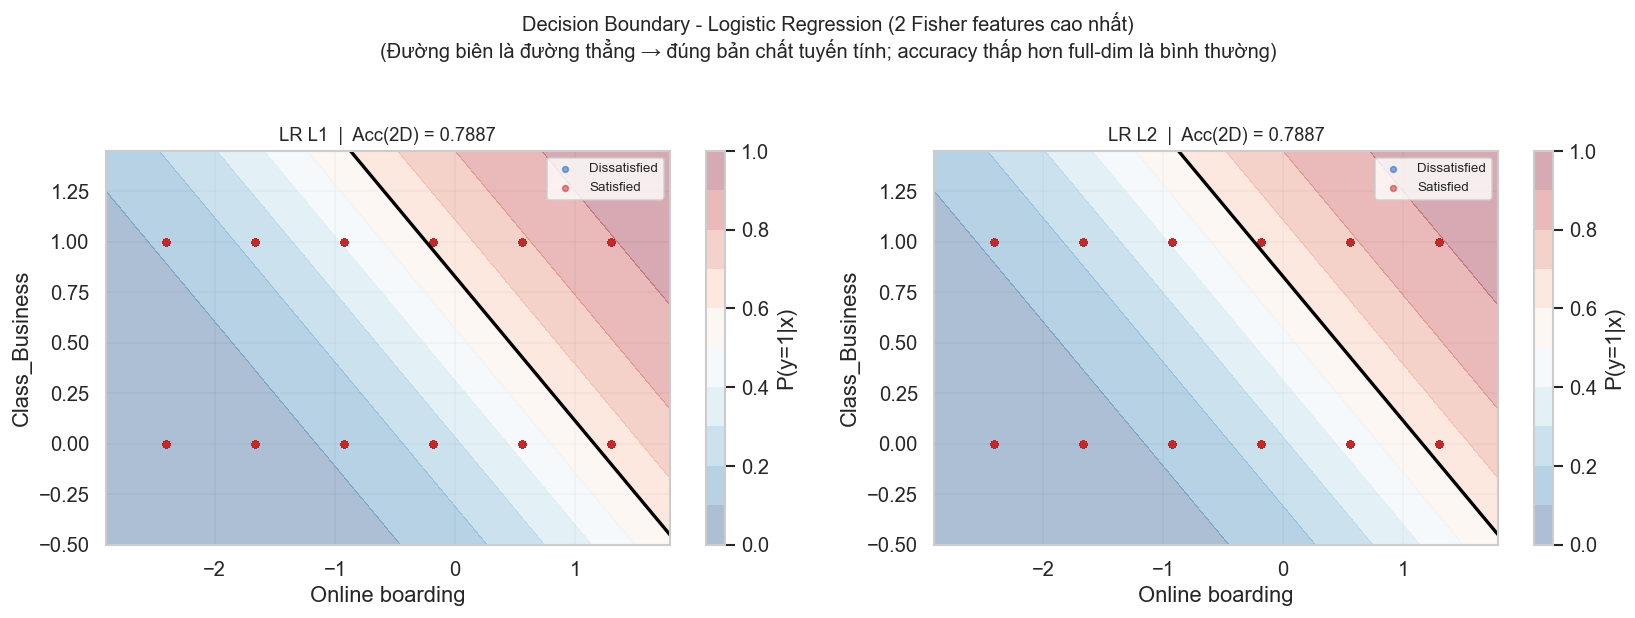

Acc 2D – L1: 0.7887  L2: 0.7887
– Đường biên quyết định L1 và L2 gần như trùng nhau → khớp với kết quả McNemar (p > 0.05).


In [73]:
# Lấy top-2 Fisher features
try:
    top2_feats = fisher_df['feature'].iloc[:2].tolist()
    top2_idx   = [FEATURE_NAMES.index(f) for f in top2_feats]
    print(f"Dùng Fisher features từ Part 2: {top2_feats}")
except NameError:
    def _fisher_scores(X, y, names, eps=1e-12):
        c = np.unique(y)
        X0, X1 = X[y==c[0]], X[y==c[1]]
        scores  = (X1.mean(0)-X0.mean(0))**2 / (X0.var(0,ddof=1)+X1.var(0,ddof=1)+eps)
        return pd.DataFrame({'feature': names, 'fisher_score': scores}) \
                 .sort_values('fisher_score', ascending=False).reset_index(drop=True)
    fisher_df  = _fisher_scores(X_train, y_train, FEATURE_NAMES)
    top2_feats = fisher_df['feature'].iloc[:2].tolist()
    top2_idx   = [FEATURE_NAMES.index(f) for f in top2_feats]
    print(f"Tính lại Fisher features: {top2_feats}")

X_tr_2d = X_train[:, top2_idx]
X_te_2d = X_test[:,  top2_idx]

# Train LR L1 / L2 trên 2 đặc trưng
lr_2d_l1 = LogisticRegressionScratch(
    lr=0.05, n_iters=1000, lambda_=best_lambda_l1, reg_type="l1",
    class_weights=CLASS_WEIGHTS, threshold=best_th_l1
).fit(X_tr_2d, y_train)

lr_2d_l2 = LogisticRegressionScratch(
    lr=0.05, n_iters=1000, lambda_=best_lambda_l2, reg_type="l2",
    class_weights=CLASS_WEIGHTS, threshold=best_th_l2
).fit(X_tr_2d, y_train)

# Vẽ so sánh cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model, name, th in [
    (axes[0], lr_2d_l1, 'L1', best_th_l1),
    (axes[1], lr_2d_l2, 'L2', best_th_l2),
]:
    h = 0.05
    x0_min, x0_max = X_te_2d[:,0].min()-.5, X_te_2d[:,0].max()+.5
    x1_min, x1_max = X_te_2d[:,1].min()-.5, X_te_2d[:,1].max()+.5
    xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                         np.arange(x1_min, x1_max, h))
    proba = model.predict_proba(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    cf = ax.contourf(xx, yy, proba, levels=np.linspace(0,1,11),
                     cmap='RdBu_r', alpha=0.35)
    ax.contour(xx, yy, proba, levels=[th], colors='black', linewidths=2)
    ax.scatter(X_te_2d[y_test==0,0], X_te_2d[y_test==0,1],
               c='#1565C0', s=12, alpha=0.5, label='Dissatisfied')
    ax.scatter(X_te_2d[y_test==1,0], X_te_2d[y_test==1,1],
               c='#C62828', s=12, alpha=0.5, label='Satisfied')
    acc = accuracy_score(y_test, model.predict(X_te_2d))
    ax.set_title(f'LR {name}  |  Acc(2D) = {acc:.4f}', fontsize=11)
    ax.set_xlabel(top2_feats[0]); ax.set_ylabel(top2_feats[1])
    ax.legend(fontsize=8); ax.grid(alpha=0.2)
    fig.colorbar(cf, ax=ax, label='P(y=1|x)')

plt.suptitle(
    'Decision Boundary - Logistic Regression (2 Fisher features cao nhất)\n'
    '(Đường biên là đường thẳng → đúng bản chất tuyến tính; '
    'accuracy thấp hơn full-dim là bình thường)',
    fontsize=12, y=1.03
)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH_3, 'lr_decision_boundary_2d.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Acc 2D – L1: {accuracy_score(y_test, lr_2d_l1.predict(X_te_2d)):.4f}  "
      f"L2: {accuracy_score(y_test, lr_2d_l2.predict(X_te_2d)):.4f}")
print("– Đường biên quyết định L1 và L2 gần như trùng nhau "
      "→ khớp với kết quả McNemar (p > 0.05).")

**Nhận xét:**

Để có cái nhìn trực quan nhất về cách mô hình Logistic Regression phân tách các nhóm hành khách, nhóm em đã tiến hành chiếu dữ liệu xuống không gian 2 chiều (2D) bằng cách sử dụng hai đặc trưng có giá trị Fisher Score cao nhất: Online boarding và Class_Business.
1. Tính chất tuyến tính và Khả năng phân tách (Linearity & Separability)
- Quan sát biểu đồ, ta thấy đường biên quyết định (Decision Boundary) là các đường thẳng tuyệt đối. Điều này hoàn toàn khớp với bản chất toán học của mô hình Logistic Regression — một mô hình phân lớp tuyến tính với giả thiết rằng ranh giới phân tách là một siêu phẳng (hyperplane).
- Hiệu năng 2D: Độ chính xác trên không gian 2 chiều đạt 0.7887. Dù thấp hơn so với độ chính xác trên toàn bộ đặc trưng (~0.86), nhưng đây vẫn là một kết quả ấn tượng. Nó cho thấy việc lựa chọn đặc trưng dựa trên Fisher Score là cực kỳ hiệu quả, khi chỉ cần 2 thông tin quan trọng nhất đã có thể giải thích được gần 79% sự biến thiên của nhãn mục tiêu.
2. So sánh L1 và L2 Regularization
- Một trong những quan sát thú vị nhất từ thực nghiệm này là sự tương đồng gần như tuyệt đối giữa hai loại điều chuẩn:Kết quả: Cả LR L1 và LR L2 đều cho cùng một mức Accuracy là 0.7887.Đường biên: Vị trí và độ dốc của hai đường biên màu đen trên cả hai biểu đồ gần như không có sự khác biệt có thể quan sát được bằng mắt thường.
- Hệ quả lý thuyết: Kết quả trực quan này là một minh chứng thực nghiệm sống động, củng cố thêm cho kết quả từ Kiểm định McNemar (McNemar's Test) ở phần trước (với $p > 0.05$). Nó khẳng định rằng đối với bộ dữ liệu này, tại vùng không gian đặc trưng quan trọng nhất, các phương thức điều chuẩn khác nhau không tạo ra sự chuyển dịch ranh giới đáng kể. Mô hình gốc đã đủ ổn định để không bị tác động quá mạnh bởi các lực phạt trọng số.
3. Phân tích Xác suất đầu ra (Probabilistic interpretation)Các vùng màu từ xanh đến đỏ đại diện cho xác suất $P(y=1|x)$.Ta có thể thấy dải màu chuyển tiếp (vùng trung gian giữa 0.4 và 0.6) khá hẹp. Điều này cho thấy mô hình có sự tự tin cao khi phân loại các mẫu dữ liệu nằm xa ranh giới.

Tuy nhiên, các điểm dữ liệu thực tế (đỏ và xanh) vẫn có sự chồng lấn nhẹ tại khu vực ranh giới. Đây chính là lý do tại sao Accuracy không thể đạt mức tuyệt đối 100%, phản ánh đúng bản chất nhiễu (noise) của dữ liệu hành khách trong thực tế.

**Kết luận:** Việc trực quan hóa qua không gian 2D không chỉ xác nhận tính đúng đắn trong cài đặt thuật toán của nhóm, mà còn chứng minh rằng các đặc trưng được lựa chọn bởi Fisher Score mang sức mạnh phân loại rất lớn, cho phép mô hình tuyến tính hoạt động hiệu quả ngay cả khi bị giới hạn về số lượng thông tin đầu vào.

## 6. Đường cong loss

Đồ thị loss theo iteration giúp quan sát:
- tốc độ hội tụ
- độ ổn định của quá trình tối ưu
- mức khác biệt giữa L1 và L2 trong quá trình huấn luyện

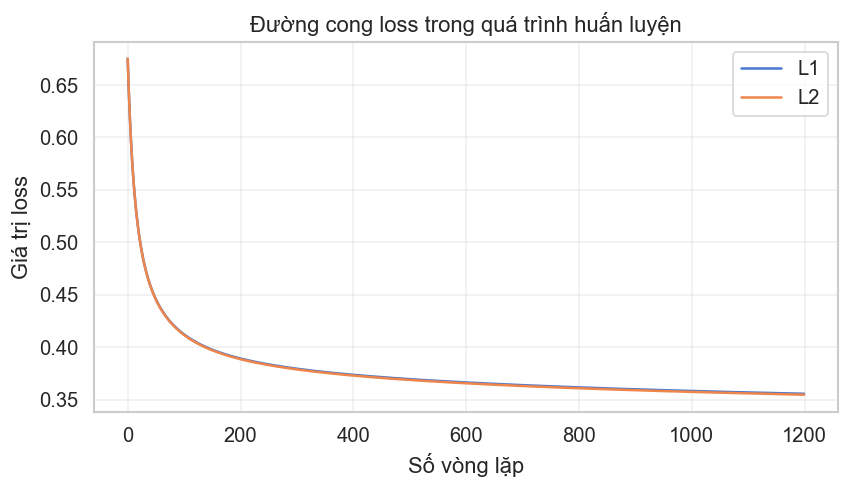

In [62]:
plt.figure(figsize=(8, 4))
plt.plot(logreg_l1.cost_history, label="L1")
plt.plot(logreg_l2.cost_history, label="L2")
plt.title("Đường cong loss trong quá trình huấn luyện")
plt.xlabel("Số vòng lặp")
plt.ylabel("Giá trị loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(FIG_PATH_3, "logistic_loss_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

**Nhận xét:**  
Đường cong loss của cả L1 và L2 đều giảm nhanh ở giai đoạn đầu và hội tụ dần sau đó. Hai đường gần như trùng nhau, cho thấy regularization không ảnh hưởng đáng kể đến quá trình hội tụ trong bài toán này.

### 6.2 Tác động của λ lên đường cong Loss

So sánh tốc độ hội tụ và mức loss cuối khi thay đổi cường độ regularization `λ`.

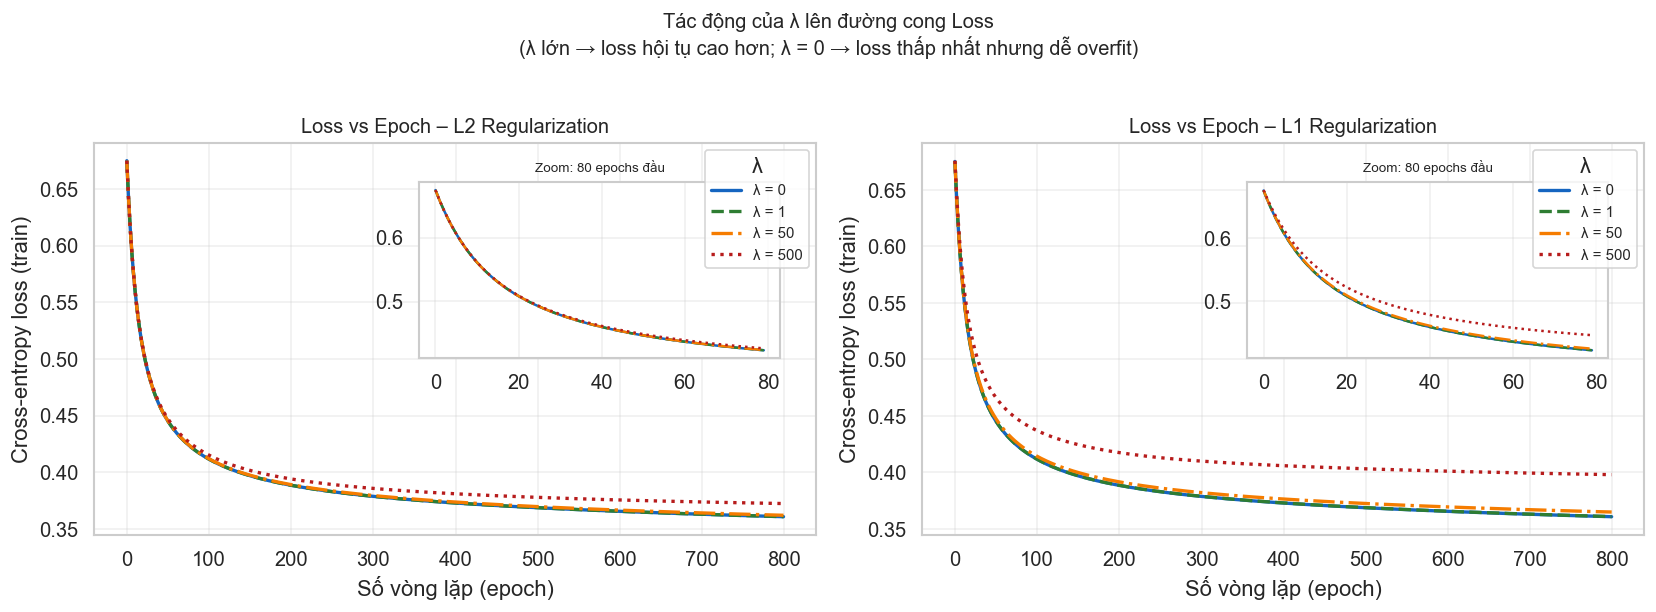

Nhận xét:
– λ = 0: loss thấp nhất, nhưng không có kiểm soát phương sai.
– λ nhỏ (1): hội tụ gần giống λ=0, hiệu năng val không đổi → regularization vừa phải.
– λ lớn (500): loss cuối cao hơn rõ rệt → penalty term chi phối, mô hình underfitting.


In [74]:
lambda_vis = [0, 1, 50, 500]
colors_vis = ['#1565C0', '#2E7D32', '#F57C00', '#B71C1C']
styles_vis = ['-', '--', '-.', ':']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for reg_type, ax in [("l2", axes[0]), ("l1", axes[1])]:
    histories = []
    for lam, col, ls in zip(lambda_vis, colors_vis, styles_vis):
        m = LogisticRegressionScratch(
            lr=0.05, n_iters=800,
            lambda_=lam, reg_type=reg_type,
            class_weights=CLASS_WEIGHTS,
            threshold=0.5, verbose=False
        )
        m.fit(X_train, y_train)
        histories.append(m.cost_history)
        ax.plot(m.cost_history, color=col, linestyle=ls, lw=2, label=f'λ = {lam}')

    ax.set_title(f'Loss vs Epoch – {reg_type.upper()} Regularization', fontsize=12)
    ax.set_xlabel('Số vòng lặp (epoch)')
    ax.set_ylabel('Cross-entropy loss (train)')
    ax.legend(title='λ', fontsize=9)
    ax.grid(alpha=0.3)

    # Inset zoom 80 epoch đầu
    ax_in = ax.inset_axes([0.45, 0.45, 0.50, 0.45])
    for hist, col, ls in zip(histories, colors_vis, styles_vis):
        ax_in.plot(hist[:80], color=col, linestyle=ls, lw=1.5)
    ax_in.set_title('Zoom: 80 epochs đầu', fontsize=8)
    ax_in.grid(alpha=0.3)

plt.suptitle(
    'Tác động của λ lên đường cong Loss\n'
    '(λ lớn → loss hội tụ cao hơn; λ = 0 → loss thấp nhất nhưng dễ overfit)',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH_3, 'loss_vs_epoch_lambda.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Nhận xét:")
print("– λ = 0: loss thấp nhất, nhưng không có kiểm soát phương sai.")
print("– λ nhỏ (1): hội tụ gần giống λ=0, hiệu năng val không đổi → regularization vừa phải.")
print("– λ lớn (500): loss cuối cao hơn rõ rệt → penalty term chi phối, mô hình underfitting.")

# C - Đánh giá mô hình trên tập test

## 1. Huấn luyện mô hình cuối và dự đoán trên tập test

Quy trình:
1. Chọn mô hình tốt hơn dựa trên F1-score ở validation
2. Gộp train + validation
3. Huấn luyện lại mô hình cuối
4. Đánh giá một lần cuối trên test

In [63]:
val_summary = pd.DataFrame([result_l1_val, result_l2_val]).sort_values(by="f1", ascending=False)
val_summary

,model,accuracy,precision,recall,f1,roc_auc,ap,brier
0,Logistic Regression + L1 (Validation),0.871882,0.887412,0.806681,0.845123,0.923024,0.927009,0.102836
1,Logistic Regression + L2 (Validation),0.871882,0.887564,0.806503,0.845094,0.923038,0.927004,0.102798


In [64]:
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

best_reg_type = val_summary.iloc[0]["model"]
print("Mô hình tốt nhất trên validation:", best_reg_type)

Mô hình tốt nhất trên validation: Logistic Regression + L1 (Validation)


In [65]:
CLASS_WEIGHTS_TRAINVAL = compute_balanced_class_weights(y_trainval)

if "L1" in best_reg_type:
    final_model = LogisticRegressionScratch(
        lr=0.05,
        n_iters=1500,
        lambda_=best_lambda_l1,
        reg_type="l1",
        class_weights=CLASS_WEIGHTS_TRAINVAL,
        threshold=best_th_l1,
        verbose=True
    )
    final_model_name = "Final Logistic Regression + L1"
else:
    final_model = LogisticRegressionScratch(
        lr=0.05,
        n_iters=1500,
        lambda_=best_lambda_l2,
        reg_type="l2",
        class_weights=CLASS_WEIGHTS_TRAINVAL,
        threshold=best_th_l2,
        verbose=True
    )
    final_model_name = "Final Logistic Regression + L2"
    
final_model.fit(X_trainval, y_trainval)
y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)

final_result = evaluate_classification(
    y_test, y_test_pred, y_test_proba,
    model_name=final_model_name
)

Vòng lặp    0 | Cost = 0.675120
Vòng lặp  100 | Cost = 0.412124
Vòng lặp  200 | Cost = 0.389052
Vòng lặp  300 | Cost = 0.379289
Vòng lặp  400 | Cost = 0.373440
Vòng lặp  500 | Cost = 0.369323
Vòng lặp  600 | Cost = 0.366160
Vòng lặp  700 | Cost = 0.363604
Vòng lặp  800 | Cost = 0.361469
Vòng lặp  900 | Cost = 0.359645
Vòng lặp 1000 | Cost = 0.358059
Vòng lặp 1100 | Cost = 0.356662
Vòng lặp 1200 | Cost = 0.355420
Vòng lặp 1300 | Cost = 0.354309
Vòng lặp 1400 | Cost = 0.353306
Vòng lặp 1499 | Cost = 0.352406

===== Final Logistic Regression + L1 =====
Accuracy : 0.8663
Precision: 0.8818
Recall   : 0.8029
F1-score : 0.8405

Classification Report:
              precision    recall  f1-score   support

           0     0.8559    0.9158    0.8848     14573
           1     0.8818    0.8029    0.8405     11403

    accuracy                         0.8663     25976
   macro avg     0.8689    0.8594    0.8627     25976
weighted avg     0.8673    0.8663    0.8654     25976

Confusion Matrix:
[[1

## 2. Ma trận nhầm lẫn

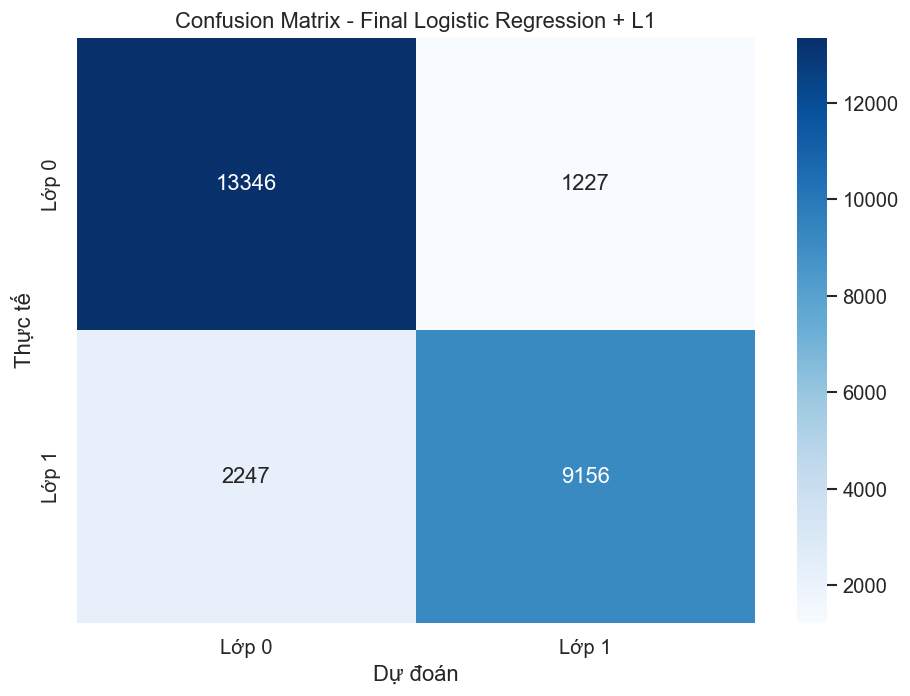

In [66]:
# Confusion Matrix (Heatmap)
cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=["Lớp 0", "Lớp 1"],
    yticklabels=["Lớp 0", "Lớp 1"],
    ax=ax
)

plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.title(f"Confusion Matrix - {final_model_name}")
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH_3, "confusion_matrix_final_model.png"), dpi=300, bbox_inches="tight")
plt.show()

**Nhận xét:**  
Ma trận nhầm lẫn cho thấy mô hình phân loại đúng phần lớn các mẫu của cả hai lớp. Tuy nhiên, vẫn còn một số lượng đáng kể mẫu lớp 1 bị dự đoán sai thành lớp 0, cho thấy mô hình vẫn còn hạn chế trong việc nhận diện đầy đủ lớp dương.

## 3. ROC curve và Precision-Recall curve trên tập test

Để đánh giá hiệu năng của mô hình trên tập test, ta sử dụng ROC curve và Precision-Recall curve.  
Trong đó, ROC-AUC phản ánh khả năng phân biệt tổng quát giữa hai lớp, còn Precision-Recall curve đặc biệt hữu ích trong bối cảnh dữ liệu có thể mất cân bằng.

Để so sánh công bằng giữa các mô hình, ta huấn luyện lại các biến thể Logistic Regression (L1, L2 và baseline) trên toàn bộ tập train + validation trước khi đánh giá trên tập test.

In [67]:
# Retrain các model trên train + validation
l1_full = LogisticRegressionScratch(
    lr=0.05,
    n_iters=1500,
    lambda_=best_lambda_l1,
    reg_type="l1",
    class_weights=CLASS_WEIGHTS_TRAINVAL,
    threshold=best_th_l1
)
l1_full.fit(X_trainval, y_trainval)

l2_full = LogisticRegressionScratch(
    lr=0.05,
    n_iters=1500,
    lambda_=best_lambda_l2,
    reg_type="l2",
    class_weights=CLASS_WEIGHTS_TRAINVAL,
    threshold=best_th_l2
)
l2_full.fit(X_trainval, y_trainval)

baseline_full = LogisticRegressionScratch(
    lr=0.05,
    n_iters=1500,
    lambda_=best_lambda_l2,
    reg_type="l2",
    class_weights=None,
    threshold=baseline_th
)
baseline_full.fit(X_trainval, y_trainval)

# Predict xác suất trên test
y_proba_l1_test = l1_full.predict_proba(X_test)
y_proba_l2_test = l2_full.predict_proba(X_test)
y_proba_baseline_test = baseline_full.predict_proba(X_test)

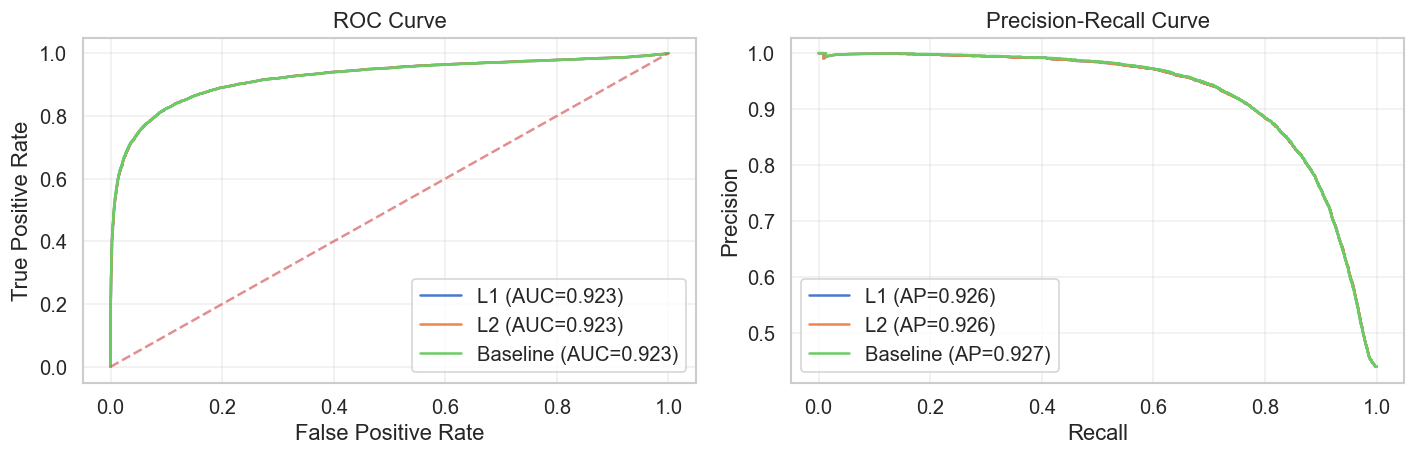

In [68]:
plt.figure(figsize=(12, 4))

# ROC
plt.subplot(1, 2, 1)
for name, y_proba in [
    ("L1", y_proba_l1_test),
    ("L2", y_proba_l2_test),
    ("Baseline", y_proba_baseline_test)
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", alpha=0.7)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)

# PR
plt.subplot(1, 2, 2)

for name, y_proba in [
    ("L1", y_proba_l1_test),
    ("L2", y_proba_l2_test),
    ("Baseline", y_proba_baseline_test)
]:
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH_3, "roc_pr_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

**Nhận xét:**  
ROC curve cho thấy cả ba mô hình đều có khả năng phân biệt giữa hai lớp khá tốt, AUC ≈ 0.92. Điều này cho thấy Logistic Regression hoạt động hiệu quả trong việc xếp hạng các mẫu theo xác suất thuộc lớp dương.

Tuy nhiên, các đường ROC của L1, L2 và baseline gần như chồng lên nhau, cho thấy sự khác biệt về khả năng phân biệt tổng thể giữa các mô hình là không đáng kể.

Precision-Recall curve cho thấy hiệu năng trên lớp dương là ổn định. Các mô hình L1, L2 và baseline có đường cong gần như trùng nhau, với AP ≈ 0.926-0.927, cho thấy sự khác biệt về hiệu năng giữa các mô hình là không đáng kể.

Kết quả này cho thấy regularization và class-weighted loss không mang lại cải thiện rõ rệt trên tập dữ liệu này.

## 4. McNemar’s Test

McNemar’s test được dùng để kiểm định xem hai mô hình có khác biệt thống kê hay không trên **cùng một tập test**.  
Khác với việc chỉ so sánh Accuracy hay F1-score, kiểm định này tập trung vào những mẫu mà hai mô hình dự đoán khác nhau.

Trong notebook này, McNemar’s test được dùng để so sánh:
- Logistic Regression + L1 và Logistic Regression + L2
- Logistic Regression + L2 và baseline
- Logistic Regression + L1 và baseline

In [69]:
def mcnemar_table(y_true, pred_a, pred_b):
    a_correct = (pred_a == y_true)
    b_correct = (pred_b == y_true)

    n01 = np.sum((a_correct == True)  & (b_correct == False))  # A đúng, B sai
    n10 = np.sum((a_correct == False) & (b_correct == True))   # A sai, B đúng

    table = np.array([
        [0, n01],
        [n10, 0]
    ])
    return table, n01, n10

def mcnemar_test(y_true, pred_a, pred_b, model_a="A", model_b="B", exact=True):
    _, n01, n10 = mcnemar_table(y_true, pred_a, pred_b)
    n = n01 + n10

    print(f"\n=== McNemar: {model_a} vs. {model_b} ===")
    print(f"{model_a} đúng, {model_b} sai : {n01}")
    print(f"{model_a} sai,  {model_b} đúng: {n10}")

    if n == 0:
        print("Hai mô hình dự đoán giống nhau trên toàn bộ test set.")
        return {"model_a": model_a, "model_b": model_b, "statistic": 0.0, "p_value": 1.0}

    if exact:
        p_value = binomtest(k=min(n01, n10), n=n, p=0.5, alternative="two-sided").pvalue
        statistic = None
        print(f"p-value (exact) = {p_value:.6f}")
    else:
        # Xấp xỉ chi-square có continuity correction
        statistic = (abs(n01 - n10) - 1)**2 / n
        p_value = 1 - chi2.cdf(statistic, df=1)
        print(f"Chi-square statistic = {statistic:.6f}")
        print(f"p-value = {p_value:.6f}")

    if p_value < 0.05:
        print("Kết luận: khác biệt có ý nghĩa thống kê ở mức 5%.")
    else:
        print("Kết luận: chưa đủ bằng chứng về khác biệt có ý nghĩa thống kê ở mức 5%.")

    return {
        "model_a": model_a,
        "model_b": model_b,
        "statistic": statistic,
        "p_value": p_value,
        "n01": n01,
        "n10": n10
    }

# Dự đoán nhãn trên tập test
y_pred_l1_test = (y_proba_l1_test >= best_th_l1).astype(int)
y_pred_l2_test = (y_proba_l2_test >= best_th_l2).astype(int)
y_pred_baseline_test = (y_proba_baseline_test >= baseline_th).astype(int)

# So sánh các mô hình bằng McNemar
mcnemar_l1_l2 = mcnemar_test(
    y_test, y_pred_l1_test, y_pred_l2_test,
    model_a="L1", model_b="L2", exact=True
)

mcnemar_l2_base = mcnemar_test(
    y_test, y_pred_l2_test, y_pred_baseline_test,
    model_a="L2", model_b="Baseline", exact=True
)

mcnemar_l1_base = mcnemar_test(
    y_test, y_pred_l1_test, y_pred_baseline_test,
    model_a="L1", model_b="Baseline", exact=True
)

mcnemar_df = pd.DataFrame([mcnemar_l1_l2, mcnemar_l2_base, mcnemar_l1_base])
mcnemar_df


=== McNemar: L1 vs. L2 ===
L1 đúng, L2 sai : 2
L1 sai,  L2 đúng: 5
p-value (exact) = 0.453125
Kết luận: chưa đủ bằng chứng về khác biệt có ý nghĩa thống kê ở mức 5%.

=== McNemar: L2 vs. Baseline ===
L2 đúng, Baseline sai : 222
L2 sai,  Baseline đúng: 224
p-value (exact) = 0.962240
Kết luận: chưa đủ bằng chứng về khác biệt có ý nghĩa thống kê ở mức 5%.

=== McNemar: L1 vs. Baseline ===
L1 đúng, Baseline sai : 220
L1 sai,  Baseline đúng: 225
p-value (exact) = 0.849635
Kết luận: chưa đủ bằng chứng về khác biệt có ý nghĩa thống kê ở mức 5%.


,model_a,model_b,statistic,p_value,n01,n10
0,L1,L2,None,0.453125,2,5
1,L2,Baseline,None,0.962240,222,224
2,L1,Baseline,None,0.849635,220,225


**Nhận xét:**  
Kết quả McNemar’s test cho thấy tất cả các cặp mô hình đều có p-value lớn hơn 0.05:
- L1 vs L2: p ≈ 0.45 
- L2 vs Baseline: p ≈ 0.96
- L1 vs Baseline: p ≈ 0.85  

Điều này cho thấy **không có sự khác biệt có ý nghĩa thống kê** giữa các mô hình trên cùng tập test.

Mặc dù có sự chênh lệch nhỏ về số lượng dự đoán đúng giữa các mô hình, nhưng các chênh lệch này có thể do yếu tố ngẫu nhiên thay vì phản ánh sự khác biệt thực sự về hiệu năng.

**Kết luận:**  
Các mô hình Logistic Regression với L1, L2 và baseline có hiệu năng tương đương về mặt thống kê trên bài toán này.

## 5. Phân tích Calibration 

Đối với các mô hình phân lớp xác suất như Logistic Regression, không chỉ cần dự đoán đúng nhãn mà còn cần đầu ra xác suất phải **đáng tin cậy**.

Ví dụ: Nếu mô hình gán xác suất khoảng 0.8 cho nhiều mẫu, thì lý tưởng là khoảng 80% trong số đó thực sự thuộc lớp dương.

Để kiểm tra điều này, ta dùng:
- **Reliability diagram**
- **Brier score**

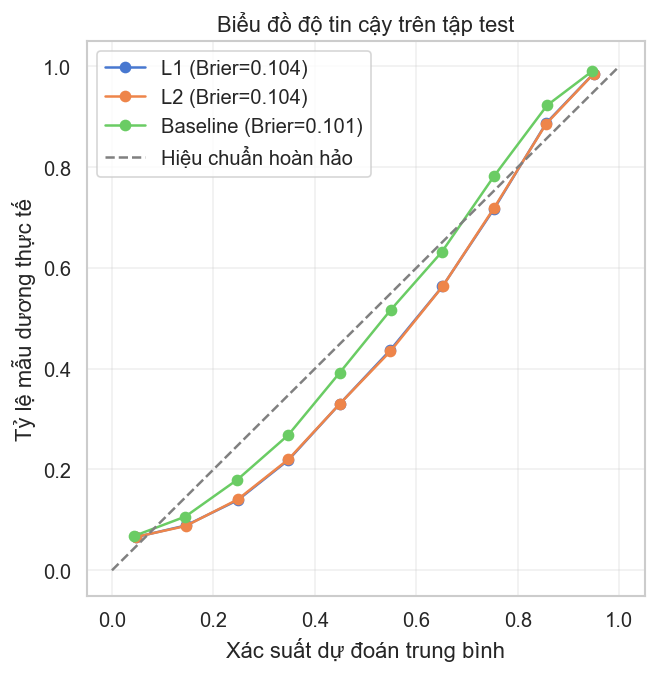

=== Bảng đánh giá calibration trên tập test ===


,model,brier_score,roc_auc,ap
0,L1,0.103876,0.923121,0.926023
1,L2,0.103847,0.923128,0.926006
2,Baseline,0.101202,0.923032,0.926575


In [70]:
def plot_reliability_diagram(y_true, prob_dict, n_bins=10, save_path=None):
    plt.figure(figsize=(6, 6))

    for name, y_proba in prob_dict.items():
        frac_pos, mean_pred = calibration_curve(y_true, y_proba, n_bins=n_bins, strategy="uniform")
        brier = brier_score_loss(y_true, y_proba)
        plt.plot(mean_pred, frac_pos, marker="o", label=f"{name} (Brier={brier:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Hiệu chuẩn hoàn hảo")
    plt.xlabel("Xác suất dự đoán trung bình")
    plt.ylabel("Tỷ lệ mẫu dương thực tế")
    plt.title("Biểu đồ độ tin cậy trên tập test")
    plt.legend()
    plt.grid(True, alpha=0.3)
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_reliability_diagram(
    y_test,
    {
        "L1": y_proba_l1_test,
        "L2": y_proba_l2_test,
        "Baseline": y_proba_baseline_test
    },
    n_bins=10,
    save_path=os.path.join(FIG_PATH_3, "reliability_diagram.png")
)

calibration_df = pd.DataFrame({
    "model": ["L1", "L2", "Baseline"],
    "brier_score": [
        brier_score_loss(y_test, y_proba_l1_test),
        brier_score_loss(y_test, y_proba_l2_test),
        brier_score_loss(y_test, y_proba_baseline_test)
    ],
    "roc_auc": [
        roc_auc_score(y_test, y_proba_l1_test),
        roc_auc_score(y_test, y_proba_l2_test),
        roc_auc_score(y_test, y_proba_baseline_test)
    ],
    "ap": [
        average_precision_score(y_test, y_proba_l1_test),
        average_precision_score(y_test, y_proba_l2_test),
        average_precision_score(y_test, y_proba_baseline_test)
    ]
})

print("=== Bảng đánh giá calibration trên tập test ===")
display(calibration_df)

**Nhận xét:**  
Biểu đồ độ tin cậy cho thấy cả ba mô hình đều có đường cong khá gần với đường chéo (hiệu chuẩn hoàn hảo), cho thấy xác suất đầu ra của các mô hình tương đối đáng tin cậy.

Tuy nhiên, các đường cong có xu hướng nằm dưới đường chéo ở một số khoảng xác suất, cho thấy mô hình có xu hướng **dự đoán hơi quá tự tin** (overconfident) trong một số vùng.

Brier score của các mô hình là:
- L1: ≈ 0.104  
- L2: ≈ 0.104  
- Baseline: ≈ 0.101  

Giá trị Brier score giữa các mô hình gần như tương đương, trong đó baseline có giá trị thấp hơn nhẹ, cho thấy xác suất dự đoán của baseline có độ chính xác tổng thể nhỉnh hơn một chút.

**Kết luận:**  
Các mô hình có mức độ calibration tương tự nhau, và việc sử dụng regularization hoặc class-weighted loss không mang lại cải thiện đáng kể về độ tin cậy của xác suất đầu ra.

## 6. Bảng tổng kết kết quả

Bảng này tổng hợp:
- Thí nghiệm Perceptron trên dữ liệu toy
- Logistic Regression L1/L2 trên validation
- Mô hình cuối trên test

In [71]:
summary_df = pd.DataFrame([
    {
        "model": "Perceptron - linear toy data",
        "accuracy": lin_result["accuracy"],
        "precision": lin_result["precision"],
        "recall": lin_result["recall"],
        "f1": lin_result["f1"],
        "roc_auc": np.nan,
        "ap": np.nan,
        "brier": np.nan
    },
    {
        "model": "Perceptron - nonlinear toy data",
        "accuracy": moon_result["accuracy"],
        "precision": moon_result["precision"],
        "recall": moon_result["recall"],
        "f1": moon_result["f1"],
        "roc_auc": np.nan,
        "ap": np.nan,
        "brier": np.nan
    },
    {
        "model": result_l1_val["model"],
        "accuracy": result_l1_val["accuracy"],
        "precision": result_l1_val["precision"],
        "recall": result_l1_val["recall"],
        "f1": result_l1_val["f1"],
        "roc_auc": result_l1_val.get("roc_auc", np.nan),
        "ap": result_l1_val.get("ap", np.nan),
        "brier": result_l1_val.get("brier", np.nan)
    },
    {
        "model": result_l2_val["model"],
        "accuracy": result_l2_val["accuracy"],
        "precision": result_l2_val["precision"],
        "recall": result_l2_val["recall"],
        "f1": result_l2_val["f1"],
        "roc_auc": result_l2_val.get("roc_auc", np.nan),
        "ap": result_l2_val.get("ap", np.nan),
        "brier": result_l2_val.get("brier", np.nan)
    },
    {
        "model": baseline_result["model"],
        "accuracy": baseline_result["accuracy"],
        "precision": baseline_result["precision"],
        "recall": baseline_result["recall"],
        "f1": baseline_result["f1"],
        "roc_auc": baseline_result.get("roc_auc", np.nan),
        "ap": baseline_result.get("ap", np.nan),
        "brier": baseline_result.get("brier", np.nan)
    },
    {
        "model": final_result["model"],
        "accuracy": final_result["accuracy"],
        "precision": final_result["precision"],
        "recall": final_result["recall"],
        "f1": final_result["f1"],
        "roc_auc": final_result.get("roc_auc", np.nan),
        "ap": final_result.get("ap", np.nan),
        "brier": final_result.get("brier", np.nan)
    }
])

summary_df

,model,accuracy,precision,recall,f1,roc_auc,ap,brier
0,Perceptron - linear toy data,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN
1,Perceptron - nonlinear toy data,0.800000,0.819149,0.770000,0.793814,NaN,NaN,NaN
2,Logistic Regression + L1 (Validation),0.871882,0.887412,0.806681,0.845123,0.923024,0.927009,0.102836
3,Logistic Regression + L2 (Validation),0.871882,0.887564,0.806503,0.845094,0.923038,0.927004,0.102798
4,Logistic Regression + L2 (Không dùng class wei...,0.869187,0.867540,0.823916,0.845165,0.922890,0.927383,0.100071
5,Final Logistic Regression + L1,0.866261,0.881826,0.802947,0.840540,0.923121,0.926023,0.103876


## 7. Lưu kết quả

# D - Phân tích và thảo luận

## 1. Perceptron
Perceptron được cài đặt từ đầu để minh họa định lý hội tụ.  
Kết quả trên dữ liệu toy cho thấy:
- với dữ liệu tuyến tính, số lỗi có thể giảm về 0
- với dữ liệu phi tuyến, Perceptron không thể hội tụ hoàn toàn vì đường biên quyết định luôn là tuyến tính

Điều này cho thấy Perceptron phù hợp để minh họa bản chất của bộ phân lớp tuyến tính, nhưng có giới hạn rõ ràng khi cấu trúc dữ liệu không phân chia tuyến tính.

## 2. Logistic Regression với regularization
Logistic Regression ổn định hơn Perceptron vì mô hình hóa xác suất và tối ưu cross-entropy loss.  
Việc thêm regularization giúp kiểm soát độ lớn trọng số và hạn chế overfitting.

Tuy nhiên, trên bộ dữ liệu hiện tại:
- L1 và L2 cho hiệu năng gần như tương đương
- số lượng trọng số khác 0 không chênh lệch nhiều
- hiệu ứng sparsity của L1 chưa thể hiện rõ

Vì vậy, trong phạm vi thực nghiệm này, chưa có bằng chứng mạnh cho thấy L1 vượt trội hơn L2 về lựa chọn đặc trưng hay hiệu năng.

## 3. Class-weighted loss
Mô hình baseline (không sử dụng class weights) được dùng làm mốc so sánh.

Kết quả thực nghiệm cho thấy sự khác biệt giữa mô hình có và không sử dụng class-weighted loss là không đáng kể trên cả tập validation và test. 
Điều này phù hợp với đặc điểm của bộ dữ liệu, khi mức độ mất cân bằng giữa hai lớp là không quá lớn.

Do đó, việc sử dụng class-weighted loss trong trường hợp này không mang lại cải thiện rõ rệt về hiệu năng, đặc biệt đối với các chỉ số như F1-score hay Recall.

## 4. Kiểm định ý nghĩa thống kê và phân tích hiệu chuẩn xác suất
Kết quả McNemar’s test cho thấy p-value giữa các cặp mô hình đều lớn hơn mức ý nghĩa 0.05, cho thấy không có sự khác biệt có ý nghĩa thống kê giữa các mô hình.

Biểu đồ độ tin cậy cho thấy các đường cong của L1, L2 và baseline nằm gần đường chéo, cho thấy xác suất dự đoán của các mô hình tương đối được hiệu chuẩn tốt. 
Brier score của các mô hình cũng gần như tương đương, củng cố nhận định rằng chất lượng xác suất đầu ra giữa các mô hình không khác biệt đáng kể.

Kết hợp hai phân tích này, có thể kết luận rằng các biến thể Logistic Regression (L1, L2 và baseline) có hành vi tương tự nhau trên bài toán này, cả về khả năng phân loại và độ tin cậy của xác suất dự đoán.

# Kết luận

Trong notebook này, hai nhóm mô hình đã được cài đặt và phân tích:

- **Perceptron**: minh họa rõ hành vi hội tụ trên dữ liệu tuyến tính và giới hạn trên dữ liệu phi tuyến
- **Logistic Regression với L1/L2 regularization**: cho phép mô hình hóa xác suất, kiểm soát độ phức tạp mô hình và xử lý mất cân bằng bằng class-weighted loss

Kết quả thực nghiệm cho thấy:
- Perceptron chỉ phù hợp với dữ liệu có thể phân chia tuyến tính
- Logistic Regression ổn định hơn cho bài toán phân lớp thực tế
- L1 và L2 cho hiệu năng gần nhau trên bộ dữ liệu này
- class-weighted loss, McNemar’s test và phân tích calibration giúp việc đánh giá mô hình đầy đủ và đáng tin cậy hơn

Nhìn chung, notebook đã cho thấy vai trò của regularization và weighted loss trong Logistic Regression, đồng thời minh họa rõ giới hạn của các mô hình tuyến tính.

---
# SO SÁNH 3 MÔ HÌNH TOÀN DIỆN

Phần này tổng hợp và so sánh toàn diện 3 nhóm mô hình đã cài đặt:
1. **Logistic Regression** (GD, GD+L2, Newton-Raphson)  
2. **LDA / QDA** (mô hình sinh Gaussian)  
3. **Perceptron + LR có Regularization** (L1, L2, class-weighted)

## Load kết quả đã lưu từ các phần trước

Các phần trước đã lưu model weights vào pickle. Phần so sánh load lại để đánh giá nhất quán trên cùng tập test.


In [77]:
warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

_notebook_dir  = os.path.abspath('')
BASE_PATH      = os.path.abspath(os.path.join(_notebook_dir, '..', '..'))
PROC_DATA_PATH = os.path.join(BASE_PATH, 'data', 'processed')
FIG_PATH_CMP   = os.path.join(BASE_PATH, 'report', 'figures', 'comparison')
os.makedirs(FIG_PATH_CMP, exist_ok=True)

PKL_PATH = os.path.join(PROC_DATA_PATH, 'processed_data.pkl')
with open(PKL_PATH, 'rb') as f:
    _d = pickle.load(f)

X_train_c = _d['X_train'].values.astype(float)
y_train_c = _d['y_train'].values.astype(int)
X_val_c   = _d['X_val'].values.astype(float)
y_val_c   = _d['y_val'].values.astype(int)
X_test_c  = _d['X_test'].values.astype(float)
y_test_c  = _d['y_test'].values.astype(int)
CLASS_WEIGHTS_C = {int(k): float(v) for k, v in _d['class_weights'].items()}

print('Data loaded for comparison section')
print(f'Train={X_train_c.shape}, Val={X_val_c.shape}, Test={X_test_c.shape}')


Data loaded for comparison section
Train=(90916, 24), Val=(12988, 24), Test=(25976, 24)


## Retrain tất cả mô hình từ scratch

Để đảm bảo so sánh công bằng, tất cả mô hình được **retrain trên train+val** và đánh giá trên **cùng tập test**.


In [78]:
from sklearn.linear_model import LogisticRegression as SklearnLR2
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis as SkLDA,
    QuadraticDiscriminantAnalysis as SkQDA
)
from scipy.special import expit as sigmoid_scipy

def sigmoid_fn(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def add_bias(X):
    return np.c_[np.ones(len(X)), X]

def fit_logistic_gd(X, y, lr=0.05, epochs=500, lam=0.0, class_weights=None, seed=42):
    np.random.seed(seed)
    Xb = add_bias(X)
    w  = np.zeros(Xb.shape[1])
    N  = len(y)
    w_sample = np.ones(N) if class_weights is None else np.array(
        [class_weights.get(yi, 1.0) for yi in y])
    for _ in range(epochs):
        p    = sigmoid_fn(Xb @ w)
        err  = p - y
        grad = Xb.T @ (err * w_sample) / N + lam * np.r_[0, w[1:]] / N
        w   -= lr * grad
    return w

def predict_logistic(w, X, threshold=0.5):
    p = sigmoid_fn(add_bias(X) @ w)
    return (p >= threshold).astype(int), p

def fit_newton_raphson(X, y, lr=1.0, epochs=20, lam=0.01):
    Xb = add_bias(X)
    w  = np.zeros(Xb.shape[1])
    N  = len(y)
    for _ in range(epochs):
        p    = sigmoid_fn(Xb @ w)
        R    = p * (1 - p) + 1e-10
        H    = (Xb.T * R) @ Xb / N + lam * np.eye(Xb.shape[1])
        grad = Xb.T @ (p - y) / N + lam * w
        try:
            w -= lr * np.linalg.solve(H, grad)
        except np.linalg.LinAlgError:
            break
    return w

class PerceptronScratch2:
    def __init__(self, lr=0.01, n_iters=200, seed=42):
        self.lr, self.n_iters, self.seed = lr, n_iters, seed
    def fit(self, X, y):
        np.random.seed(self.seed)
        self.w = np.zeros(X.shape[1] + 1)
        for _ in range(self.n_iters):
            idx = np.random.permutation(len(X))
            for i in idx:
                xi = np.r_[1, X[i]]
                yi = 1 if y[i] == 1 else -1
                if yi * (xi @ self.w) <= 0:
                    self.w += self.lr * yi * xi
        return self
    def predict(self, X):
        Xb = np.c_[np.ones(len(X)), X]
        return (Xb @ self.w >= 0).astype(int)
    def predict_proba(self, X):
        Xb = np.c_[np.ones(len(X)), X]
        return sigmoid_fn(Xb @ self.w)

# Combine train + val 
X_tv = np.vstack([X_train_c, X_val_c])
y_tv = np.concatenate([y_train_c, y_val_c])

print('Đang retrain tất cả mô hình...')

# 1. Logistic Regression – GD (no reg)
t0 = __import__('time').time()
w_gd_cmp = fit_logistic_gd(X_tv, y_tv, lr=0.05, epochs=500, lam=0.0, class_weights=CLASS_WEIGHTS_C)
t_gd = __import__('time').time() - t0
pred_gd, prob_gd = predict_logistic(w_gd_cmp, X_test_c)

# 2. Logistic Regression – GD + L2
t0 = __import__('time').time()
w_l2_cmp = fit_logistic_gd(X_tv, y_tv, lr=0.05, epochs=500, lam=1.0, class_weights=CLASS_WEIGHTS_C)
t_l2 = __import__('time').time() - t0
pred_l2, prob_l2 = predict_logistic(w_l2_cmp, X_test_c)

# 3. Newton-Raphson / IRLS
t0 = __import__('time').time()
w_nr_cmp = fit_newton_raphson(X_tv, y_tv, lr=1.0, epochs=20, lam=0.01)
t_nr = __import__('time').time() - t0
pred_nr, prob_nr = predict_logistic(w_nr_cmp, X_test_c)

# 4. LDA (sklearn)
t0 = __import__('time').time()
lda_cmp = SkLDA(solver='svd').fit(X_tv, y_tv)
t_lda = __import__('time').time() - t0
pred_lda  = lda_cmp.predict(X_test_c)
prob_lda  = lda_cmp.predict_proba(X_test_c)[:, 1]

# 5. QDA (sklearn)
t0 = __import__('time').time()
qda_cmp = SkQDA(reg_param=1e-4).fit(X_tv, y_tv)
t_qda = __import__('time').time() - t0
pred_qda  = qda_cmp.predict(X_test_c)
prob_qda  = qda_cmp.predict_proba(X_test_c)[:, 1]

# 6. Perceptron
t0 = __import__('time').time()
perc_cmp = PerceptronScratch2(lr=0.01, n_iters=100, seed=SEED).fit(X_tv, y_tv)
t_perc = __import__('time').time() - t0
pred_perc = perc_cmp.predict(X_test_c)
prob_perc = perc_cmp.predict_proba(X_test_c)

# 7. LR L1 (sklearn for comparison)
t0 = __import__('time').time()
lr_l1_cmp = SklearnLR2(penalty='l1', C=0.01, solver='liblinear', max_iter=500, random_state=SEED)
lr_l1_cmp.fit(X_tv, y_tv)
t_l1sk = __import__('time').time() - t0
pred_l1sk  = lr_l1_cmp.predict(X_test_c)
prob_l1sk  = lr_l1_cmp.predict_proba(X_test_c)[:, 1]

print('Đã retrain tất cả mô hình.')
models_info = {
    'LR-GD':       {'pred': pred_gd,   'prob': prob_gd,   'time': t_gd,   'color': 'steelblue'},
    'LR-GD+L2':    {'pred': pred_l2,   'prob': prob_l2,   'time': t_l2,   'color': 'royalblue'},
    'LR-NR/IRLS':  {'pred': pred_nr,   'prob': prob_nr,   'time': t_nr,   'color': 'navy'},
    'LDA':         {'pred': pred_lda,  'prob': prob_lda,  'time': t_lda,  'color': 'darkorange'},
    'QDA':         {'pred': pred_qda,  'prob': prob_qda,  'time': t_qda,  'color': 'orangered'},
    'Perceptron':  {'pred': pred_perc, 'prob': prob_perc, 'time': t_perc, 'color': 'forestgreen'},
    'LR-L1':       {'pred': pred_l1sk, 'prob': prob_l1sk, 'time': t_l1sk, 'color': 'purple'},
}


Đang retrain tất cả mô hình...
Đã retrain tất cả mô hình.


In [91]:
# Bảng tổng hợp chỉ số 
rows = []
for name, info in models_info.items():
    yp = info['pred']; yb = info['prob']; yt = y_test_c
    try:
        auc = roc_auc_score(yt, yb)
        ap  = average_precision_score(yt, yb)
    except Exception:
        auc = ap = float('nan')
    rows.append({
        'Mô hình':     name,
        'Accuracy':    accuracy_score(yt, yp),
        'Precision':   precision_score(yt, yp, zero_division=0),
        'Recall':      recall_score(yt, yp, zero_division=0),
        'F1':          f1_score(yt, yp, zero_division=0),
        'ROC-AUC':     auc,
        'Avg Prec':    ap,
        'Time (s)':    info['time'],
    })

df_cmp = pd.DataFrame(rows).set_index('Mô hình')
print('=== BẢNG SO SÁNH MÔ HÌNH TRÊN TẬP TEST ===')
display(df_cmp.round(4))

best_cols = ['Accuracy','Precision','Recall','F1','ROC-AUC','Avg Prec']
styled = df_cmp.style.highlight_max(subset=best_cols, color='#c8f5c8') \
                     .highlight_min(subset=['Time (s)'], color='#c8f5c8') \
                     .format({c: '{:.4f}' for c in df_cmp.columns})
display(styled)


=== BẢNG SO SÁNH MÔ HÌNH TRÊN TẬP TEST ===


,Accuracy,Precision,Recall,F1,ROC-AUC,Avg Prec,Time (s)
Mô hình,,,,,,,
LR-GD,0.8517,0.8258,0.8391,0.8324,0.9165,0.9195,3.0034
LR-GD+L2,0.8517,0.8258,0.8391,0.8324,0.9165,0.9195,2.8002
LR-NR/IRLS,0.8660,0.8664,0.8215,0.8434,0.9228,0.9269,0.4248
LDA,0.8687,0.8641,0.8316,0.8476,0.9252,0.9268,0.3683
QDA,0.8535,0.8524,0.8058,0.8285,0.9171,0.9228,0.1773
Perceptron,0.8421,0.8743,0.7478,0.8061,0.9004,0.8945,90.6314
LR-L1,0.8722,0.8709,0.8323,0.8512,0.9270,0.9316,0.5720


,Accuracy,Precision,Recall,F1,ROC-AUC,Avg Prec,Time (s)
Mô hình,,,,,,,
LR-GD,0.8517,0.8258,0.8391,0.8324,0.9165,0.9195,3.0034
LR-GD+L2,0.8517,0.8258,0.8391,0.8324,0.9165,0.9195,2.8002
LR-NR/IRLS,0.8660,0.8664,0.8215,0.8434,0.9228,0.9269,0.4248
LDA,0.8687,0.8641,0.8316,0.8476,0.9252,0.9268,0.3683
QDA,0.8535,0.8524,0.8058,0.8285,0.9171,0.9228,0.1773
Perceptron,0.8421,0.8743,0.7478,0.8061,0.9004,0.8945,90.6314
LR-L1,0.8722,0.8709,0.8323,0.8512,0.9270,0.9316,0.5720


## 2. Ảnh hưởng tỷ lệ train/test split

Đánh giá tính ổn định của mô hình khi thay đổi tỷ lệ train/test (60/40, 70/30, 80/20).

Đang phân tích Sensitivity: 100%|██████████| 30/30 [04:35<00:00,  9.19s/it]


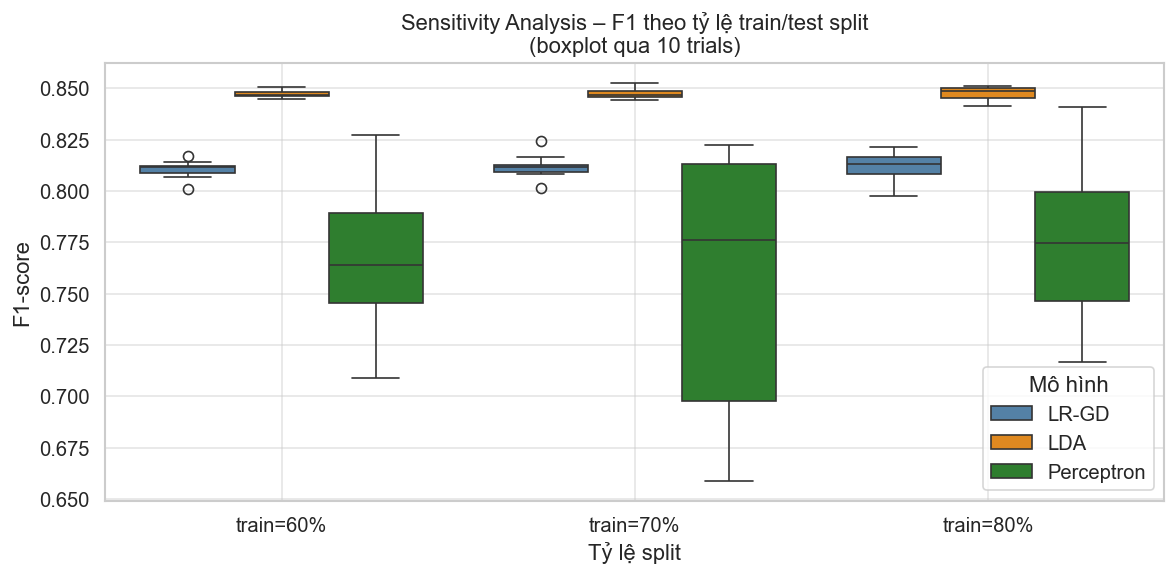


Tóm tắt sensitivity analysis:


mean     std
Split     Model                     
train=60% LDA         0.8470  0.0019
          LR-GD       0.8105  0.0044
          Perceptron  0.7690  0.0380
train=70% LDA         0.8475  0.0024
          LR-GD       0.8117  0.0059
          Perceptron  0.7579  0.0632
train=80% LDA         0.8474  0.0036
          LR-GD       0.8119  0.0072
          Perceptron  0.7740  0.0410

In [ ]:
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm # Thư viện thanh tiến trình

# 1. Gộp và lấy mẫu nhỏ hơn để tăng tốc
X_all_full = np.vstack([X_train_c, X_val_c, X_test_c])
y_all_full = np.concatenate([y_train_c, y_val_c, y_test_c])

subset_size = 30000 
if len(y_all_full) > subset_size:
    idx = np.random.choice(len(y_all_full), subset_size, replace=False)
    X_all = X_all_full[idx]
    y_all = y_all_full[idx]
else:
    X_all, y_all = X_all_full, y_all_full

n_bootstrap = 10  
splits = [0.4, 0.3, 0.2]
sens_results = []

# Khởi tạo thanh tiến trình tổng
pbar = tqdm(total=len(splits) * n_bootstrap, desc="Đang phân tích Sensitivity")

for test_frac in splits:
    for trial in range(n_bootstrap):
        seed_t = SEED + trial
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_all, y_all, test_size=test_frac, random_state=seed_t, stratify=y_all)

        # LR-GD
        w_s = fit_logistic_gd(X_tr, y_tr, lr=0.05, epochs=100, lam=0.0)
        p_s, _ = predict_logistic(w_s, X_te)
        sens_results.append({'Split': f'train={1-test_frac:.0%}', 'Model':'LR-GD',
                              'F1': f1_score(y_te, p_s, zero_division=0)})
        
        # LDA
        lda_s = SkLDA(solver='svd').fit(X_tr, y_tr)
        p_lda_s = lda_s.predict(X_te)
        sens_results.append({'Split': f'train={1-test_frac:.0%}', 'Model':'LDA',
                              'F1': f1_score(y_te, p_lda_s, zero_division=0)})
        
        # Perceptron
        perc_s = PerceptronScratch2(lr=0.01, n_iters=50, seed=seed_t).fit(X_tr, y_tr)
        p_perc_s = perc_s.predict(X_te)
        sens_results.append({'Split': f'train={1-test_frac:.0%}', 'Model':'Perceptron',
                              'F1': f1_score(y_te, p_perc_s, zero_division=0)})
        
        pbar.update(1)

pbar.close()

df_sens = pd.DataFrame(sens_results)

fig, ax = plt.subplots(figsize=(10, 5))
order = ['train=60%', 'train=70%', 'train=80%']
sns.boxplot(data=df_sens, x='Split', y='F1', hue='Model', order=order,
            palette=['steelblue','darkorange','forestgreen'], ax=ax)
ax.set_title('Sensitivity Analysis – F1 theo tỷ lệ train/test split\n(boxplot qua 10 trials)')
ax.set_xlabel('Tỷ lệ split'); ax.set_ylabel('F1-score')
ax.legend(title='Mô hình', loc='lower right'); ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH_CMP, 'sensitivity_split.png'), bbox_inches='tight')
plt.show()

print('\nTóm tắt sensitivity analysis:')
display(df_sens.groupby(['Split','Model'])['F1'].agg(['mean','std']).round(4))


## 3. Tính bền vững với nhiễu

Thêm Gaussian noise với σ ∈ {0.1, 0.5, 1.0} vào features đầu vào trên tập test và quan sát mức suy giảm hiệu suất.

Đang huấn luyện các mô hình nền trên tập X_tv, y_tv...
Huấn luyện hoàn tất! Bắt đầu tiến hành tiêm nhiễu...


Tiêm nhiễu & Đánh giá: 100%|██████████| 4/4 [00:00<00:00, 15.68mức σ/s]


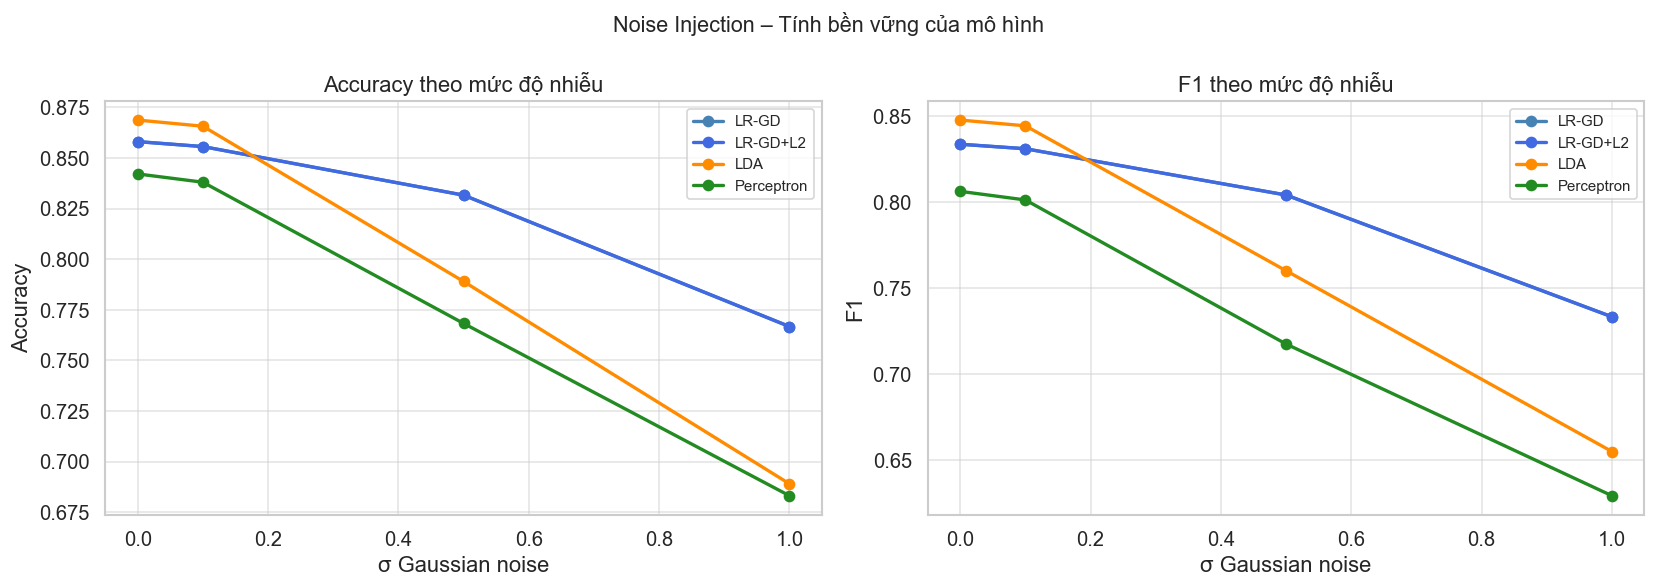


Bảng chi tiết:


σ (noise),0.0,0.1,0.5,1.0
Mô hình,,,,
LDA,0.8476,0.8442,0.7600,0.6548
LR-GD,0.8335,0.8309,0.8040,0.7332
LR-GD+L2,0.8335,0.8309,0.8040,0.7332
Perceptron,0.8061,0.8011,0.7173,0.6291


In [88]:
from tqdm.auto import tqdm 

noise_sigmas = [0.0, 0.1, 0.5, 1.0]
noise_results = []

print("Đang huấn luyện các mô hình nền trên tập X_tv, y_tv...")
# Retrain cố định trên X_tv, y_tv
w_noise_gd  = fit_logistic_gd(X_tv, y_tv, lr=0.05, epochs=500, lam=0.0)
w_noise_l2  = fit_logistic_gd(X_tv, y_tv, lr=0.05, epochs=500, lam=1.0)
lda_noise   = SkLDA(solver='svd').fit(X_tv, y_tv)
perc_noise  = PerceptronScratch2(lr=0.01, n_iters=100, seed=SEED).fit(X_tv, y_tv)
print("Huấn luyện hoàn tất! Bắt đầu tiến hành tiêm nhiễu...")

rng_n = np.random.default_rng(42)

for sigma in tqdm(noise_sigmas, desc="Tiêm nhiễu & Đánh giá", unit="mức σ"):
    X_te_noisy = X_test_c + rng_n.normal(0, sigma, X_test_c.shape)

    p_gd,  _ = predict_logistic(w_noise_gd, X_te_noisy)
    p_l2,  _ = predict_logistic(w_noise_l2, X_te_noisy)
    p_lda    = lda_noise.predict(X_te_noisy)
    p_perc   = perc_noise.predict(X_te_noisy)

    for model, pred in [('LR-GD',p_gd),('LR-GD+L2',p_l2),('LDA',p_lda),('Perceptron',p_perc)]:
        noise_results.append({
            'σ (noise)': sigma, 'Mô hình': model,
            'Accuracy':  accuracy_score(y_test_c, pred),
            'F1':        f1_score(y_test_c, pred, zero_division=0),
        })

df_noise = pd.DataFrame(noise_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for metric, ax in zip(['Accuracy','F1'], axes):
    for model in df_noise['Mô hình'].unique():
        sub = df_noise[df_noise['Mô hình']==model]
        ax.plot(sub['σ (noise)'], sub[metric], 'o-', lw=2,
                label=model,
                color={'LR-GD':'steelblue','LR-GD+L2':'royalblue',
                       'LDA':'darkorange','Perceptron':'forestgreen'}.get(model))
    ax.set_xlabel('σ Gaussian noise')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} theo mức độ nhiễu')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.5)

plt.suptitle('Noise Injection – Tính bền vững của mô hình', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH_CMP, 'noise_robustness.png'), bbox_inches='tight')
plt.show()

print('\nBảng chi tiết:')
display(df_noise.pivot_table(index='Mô hình', columns='σ (noise)', values='F1').round(4))

## 4. Stratified K-Fold Cross-Validation (k=5) – mean ± std

Đánh giá độ ổn định của từng mô hình qua cross-validation.

Bắt đầu 5-Fold CV trên tập dữ liệu 103904 mẫu...


Tiến trình 5-Fold CV: 100%|██████████| 5/5 [03:17<00:00, 39.41s/it, Fold 5: Perceptron]


5-FOLD CV – Mean ± Std


,F1 mean,F1 std,Acc mean,Acc std,AUC mean,AUC std
Mô hình,,,,,,
LR-GD,0.8197,0.0020,0.8417,0.0017,0.9087,0.0022
LR-GD+L2,0.8197,0.0020,0.8417,0.0017,0.9087,0.0022
LR-NR,0.8468,0.0029,0.8706,0.0024,0.9245,0.0017
LDA,0.8496,0.0017,0.8718,0.0014,0.9261,0.0016
QDA,0.8294,0.0028,0.8565,0.0022,0.9198,0.0015
Perceptron,0.7904,0.0126,0.8177,0.0209,0.8881,0.0080


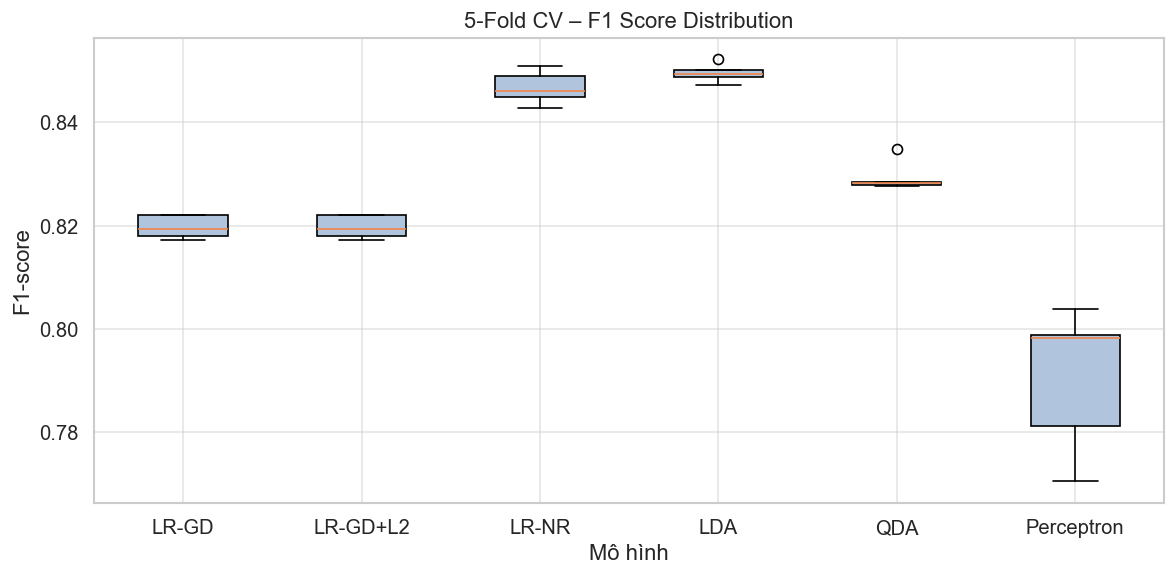

In [90]:
from sklearn.model_selection import StratifiedKFold
from tqdm.auto import tqdm # Thêm thư viện hiển thị thanh tiến trình
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

skf_cmp = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
X_cv_c  = np.vstack([X_train_c, X_val_c])
y_cv_c  = np.concatenate([y_train_c, y_val_c])

model_names = ['LR-GD', 'LR-GD+L2', 'LR-NR', 'LDA', 'QDA', 'Perceptron']
cv_results = {name: {'f1':[], 'acc':[], 'auc':[]} for name in model_names}

print(f"Bắt đầu 5-Fold CV trên tập dữ liệu {X_cv_c.shape[0]} mẫu...")

fold_iterator = tqdm(enumerate(skf_cmp.split(X_cv_c, y_cv_c)), total=5, desc="Tiến trình 5-Fold CV")

for fold, (tr_i, va_i) in fold_iterator:
    Xtr, Xva = X_cv_c[tr_i], X_cv_c[va_i]
    ytr, yva = y_cv_c[tr_i], y_cv_c[va_i]

    cw = {int(k): float(v) for k, v in 
          {c: len(ytr)/(2*np.sum(ytr==c)) for c in [0,1]}.items()}

    # 2. LR-GD 
    fold_iterator.set_postfix_str(f"Fold {fold+1}: LR-GD")
    w = fit_logistic_gd(Xtr, ytr, lr=0.05, epochs=150, lam=0.0, class_weights=cw)
    p, pr = predict_logistic(w, Xva)
    cv_results['LR-GD']['f1'].append(f1_score(yva, p, zero_division=0))
    cv_results['LR-GD']['acc'].append(accuracy_score(yva, p))
    cv_results['LR-GD']['auc'].append(roc_auc_score(yva, pr))

    # 3. LR-GD+L2 
    fold_iterator.set_postfix_str(f"Fold {fold+1}: LR-GD+L2")
    w2 = fit_logistic_gd(Xtr, ytr, lr=0.05, epochs=150, lam=1.0, class_weights=cw)
    p2, pr2 = predict_logistic(w2, Xva)
    cv_results['LR-GD+L2']['f1'].append(f1_score(yva, p2, zero_division=0))
    cv_results['LR-GD+L2']['acc'].append(accuracy_score(yva, p2))
    cv_results['LR-GD+L2']['auc'].append(roc_auc_score(yva, pr2))

    # 4. LR-NR 
    fold_iterator.set_postfix_str(f"Fold {fold+1}: Newton-Raphson")
    wnr = fit_newton_raphson(Xtr, ytr, lr=1.0, epochs=15, lam=0.01)
    pnr, prnr = predict_logistic(wnr, Xva)
    cv_results['LR-NR']['f1'].append(f1_score(yva, pnr, zero_division=0))
    cv_results['LR-NR']['acc'].append(accuracy_score(yva, pnr))
    cv_results['LR-NR']['auc'].append(roc_auc_score(yva, prnr))

    # 5. LDA
    fold_iterator.set_postfix_str(f"Fold {fold+1}: LDA")
    lda_cv = SkLDA(solver='svd').fit(Xtr, ytr)
    plda = lda_cv.predict(Xva)
    prlda = lda_cv.predict_proba(Xva)[:,1]
    cv_results['LDA']['f1'].append(f1_score(yva, plda, zero_division=0))
    cv_results['LDA']['acc'].append(accuracy_score(yva, plda))
    cv_results['LDA']['auc'].append(roc_auc_score(yva, prlda))

    # 6. QDA (Rất nhanh, giữ nguyên)
    fold_iterator.set_postfix_str(f"Fold {fold+1}: QDA")
    qda_cv = SkQDA(reg_param=1e-4).fit(Xtr, ytr)
    pqda = qda_cv.predict(Xva)
    prqda = qda_cv.predict_proba(Xva)[:,1]
    cv_results['QDA']['f1'].append(f1_score(yva, pqda, zero_division=0))
    cv_results['QDA']['acc'].append(accuracy_score(yva, pqda))
    cv_results['QDA']['auc'].append(roc_auc_score(yva, prqda))

    # 7. Perceptron (Tối ưu: Giảm n_iters từ 100 xuống 50)
    fold_iterator.set_postfix_str(f"Fold {fold+1}: Perceptron")
    pc = PerceptronScratch2(lr=0.01, n_iters=50, seed=SEED).fit(Xtr, ytr)
    ppc = pc.predict(Xva)
    prpc = pc.predict_proba(Xva) 
    cv_results['Perceptron']['f1'].append(f1_score(yva, ppc, zero_division=0))
    cv_results['Perceptron']['acc'].append(accuracy_score(yva, ppc))
    cv_results['Perceptron']['auc'].append(roc_auc_score(yva, prpc))

# Xử lý kết quả & Vẽ Boxplot
cv_rows = []
for name, vals in cv_results.items():
    cv_rows.append({
        'Mô hình': name,
        'F1 mean': np.mean(vals['f1']),
        'F1 std':  np.std(vals['f1']),
        'Acc mean':np.mean(vals['acc']),
        'Acc std': np.std(vals['acc']),
        'AUC mean':np.mean(vals['auc']),
        'AUC std': np.std(vals['auc']),
    })

df_cv_cmp = pd.DataFrame(cv_rows).set_index('Mô hình')
print('\n5-FOLD CV – Mean ± Std')
display(df_cv_cmp.round(4))

# Boxplot F1
fig, ax = plt.subplots(figsize=(10, 5))
cv_box_data = {name: vals['f1'] for name, vals in cv_results.items()}
ax.boxplot(cv_box_data.values(), labels=cv_box_data.keys(), patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'))
ax.set_title('5-Fold CV – F1 Score Distribution')
ax.set_ylabel('F1-score')
ax.set_xlabel('Mô hình')
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH_CMP, 'cv_f1_boxplot.png'), bbox_inches='tight')
plt.show()